# Regression Dynamic Causal Modeling Effective Connectivity

This notebook shows, using <img src="https://julialang.org/assets/infra/logo.svg" alt="Julia" style="height:2em; max-height:2em; width:auto; vertical-align:text-bottom; margin:0 2px; display:inline;">, how to invert an underlying effective connectivity model using a regression approach instead of a generative model based on inputs. This enables its application to continuous time series in the absence of a stimulus description.  


Frässle, S., Harrison, S. J., Heinzle, J., Clementz, B. A., Tamminga, C. A., Sweeney, J. A., Gershon, E. S., Keshavan, M. S., Pearlson, G. D., Powers, A., & Stephan, K. E. (2021). **Regression dynamic causal modeling for resting-state fMRI**. Human Brain Mapping, 42(7), 2159-2180. https://doi.org/10.1002/hbm. 25357

## Environment setup & rDCM configuration

Variables in the file: ["data"]
Shape of tSeries: (24, 300)
Data: [-0.3419405519962311 -0.6376693248748779 -0.1692049354314804 0.1389259248971939 0.8674545884132385 -0.09990956634283066 -0.5284860730171204 -0.12365233898162842 0.5369775891304016 -0.259472131729126 0.3257284462451935 -0.13043439388275146 0.43843117356300354 -0.38640937209129333 0.18545056879520416 0.1385907232761383 -0.25737160444259644 -0.09387610852718353 -0.3342646658420563 -0.5674242377281189 0.22212058305740356 0.020703693851828575 -0.28873440623283386 0.427995502948761 0.393347829580307 0.38385072350502014 -0.06374234706163406 -0.531212329864502 0.7018138766288757 -0.6404625773429871 -1.1027146577835083 0.38964954018592834 -0.3076280653476715 0.5359720587730408 2.135206699371338 1.4753365516662598 2.107173442840576 2.5340070724487305 1.299606442451477 2.182915687561035 0.2177519053220749 -0.567535936832428 0.25871238112449646 0.14194265007972717 0.6270995736122131 0.26544973254203796 -0.07988743484020233 -0.703668

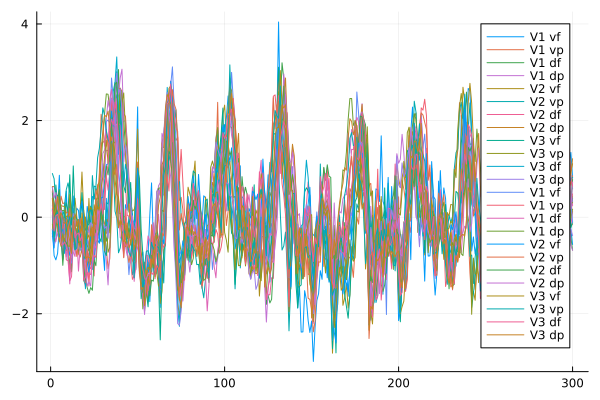

In [1]:
using MAT
using Plots
using RegressionDynamicCausalModeling 
using IJulia
using Colors
using Gadfly, Compose 
using Random
using Statistics
using NPZ
using Printf

i_sub = 0 
i_sess = 0 

prep_pth = "/home/nicolas/Documents/RetNet/ret-EC/"

fname = string(prep_pth, "retdata/sorted/tSeries_subj-", i_sub + 1, "_scan-", i_sess + 1, "_24rois_allsubjects.mat")

matfile = matopen(fname)


# List all variable names in the MATLAB file
varnames = names(matfile)
println("Variables in the file: ", varnames)


# Optionally, read a specific variable (e.g., "data")
if "data" in varnames
    tSeries = read(matfile, "data")
    println("Shape of tSeries: ", size(tSeries))
    println("Data: ", tSeries)
end



# Define the labels
labels = [
    "V1 vf",
    "V1 vp",
    "V1 df", 
    "V1 dp",
    "V2 vf",
    "V2 vp",
    "V2 df", 
    "V2 dp",
    "V3 vf",
    "V3 vp",
    "V3 df", 
    "V3 dp",
    "V1 vf",
    "V1 vp",
    "V1 df", 
    "V1 dp",
    "V2 vf",
    "V2 vp",
    "V2 df", 
    "V2 dp",
    "V3 vf",
    "V3 vp",
    "V3 df", 
    "V3 dp"]


#labels = ["V1 vf", "V1 vp", "V1 df", "V1 dp"]

# Define the x-axis data
x = 1:size(tSeries, 2)  # Assuming tSeries has time points along the second dimension

# Extract the relevant y-axis data
y_data = tSeries[1:length(labels), :]
println(size(y_data))

# Initialize the plot
p = Plots.plot()

# Add each series to the plot with the corresponding label
for i in 1:size(y_data, 1)
    Plots.plot!(p, x, y_data[i, :], label=labels[i])
end

# Display the plot
display(p)

println(size(y_data))


In [2]:
typeof(y_data)

Matrix{Float64} (alias for Array{Float64, 2})

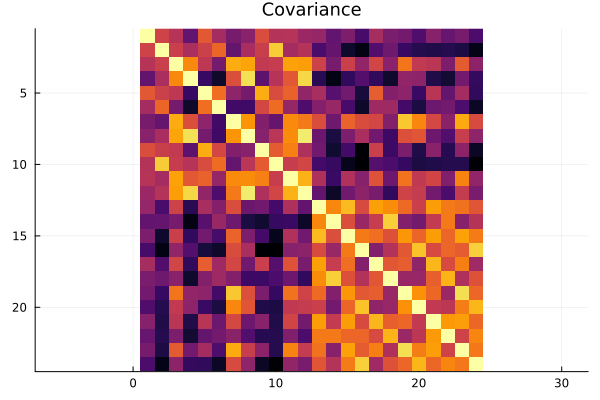

In [3]:
cov_matrix = cov(transpose(y_data))

# visualize network covariance
heatmap(
    cov_matrix;
    yflip=true,
    title="Covariance",
    titlefontsize=12,
    legend=:none,
    #xlabel=labels,
    #ylabel=labels,
    aspect_ratio=1,
    #size=(350, 350),
)


## Regression dynamic causal modeling (DCM) framework 

In [4]:
nr = size(y_data,1)
N = size(y_data,2)
a = BitMatrix(ones(24, 24))
c = BitMatrix(zeros(length(labels),0));
U = nothing
Y = BoldY(transpose(y_data),2.0,labels)
size(y_data)
y = y_data
Ep = rDCM.TrueParamLinear(a,c;sample=false);
dcm = LinearDCM(a,c,N,nr,U,Y,Ep,nothing)


Linear DCM
a:     24x24 matrix
c:     24x0 matrix
scans: 300
nr:    24
---------------------------------------------
U (Input)
   empty
---------------------------------------------
Y (BOLD signal)
   y:  300x24 matrix
   dt: 2.0s
   names: V1 vf,...,V3 dp
---------------------------------------------
Ep (True parameters)
    A: 24 x 24 matrix
    C: 24 x 0 matrix
    transit: 0.00 ... 0.00
    decay:   0.00 ... 0.00
    epsilon: 0.00


In [5]:
opt = Options(RigidInversionParams();synthetic=false,rng=MersenneTwister(42));

In [6]:
rdcm = RigidRdcm(dcm)

rigid rDCM
a:     24x24 matrix
c:     24x0 matrix
scans: 300
nr:    24
HRF:   4800 element vector
---------------------------------------------
U (Input)
   u:  4800x0 matrix
   dt: 0.125s
---------------------------------------------
Y (BOLD signal)
   y:  300x24 matrix
   dt: 2.0s
   names: V1 vf,...,V3 dp
---------------------------------------------
Ep (True parameters)
    A: 24 x 24 matrix
    C: 24 x 0 matrix
    transit: 0.00 ... 0.00
    decay:   0.00 ... 0.00
    epsilon: 0.00
---------------------------------------------
Confounds
   X0:    4800x0 matrix


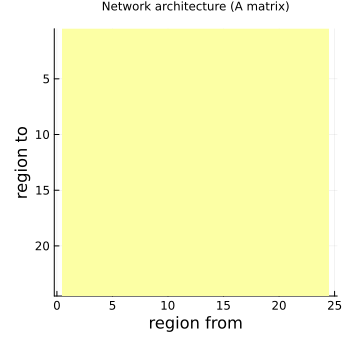

In [7]:
heatmap(
    dcm.a;
    yflip=true,
    title="Network architecture (A matrix)",
    titlefontsize=8,
    legend=:none,
    xlabel="region from",
    ylabel="region to",
    aspect_ratio=1,
    size=(350, 350),
)

In [8]:
# Invert the model (estimate posterior of parameters)
output = invert(rdcm, opt)
F_model = output.F

Running model inversion (rigid rDCM)


-19489.325119884128

In [9]:
dcm_null = copy(dcm)
dcm_null.a .= 0  # zero the connectivity matrix
rdcm_null = RigidRdcm(dcm_null)
out_null = invert(rdcm_null, opt)
F_null = out_null.F

Running model inversion (rigid rDCM)


-19143.30724335979

In [10]:
# Compute pseudo R²
pseudo_R2 = 1 - (F_model / F_null)
println("pseudo_R2 = $pseudo_R2")

pseudo_R2 = -0.018075135718482516


In [11]:
using Statistics

model_conn = output.m_all

# Flatten (vectorize) both matrices:
v_emp = vec(cov_matrix)
v_model = vec(model_conn)

corr = cor(v_emp, v_model)
println("Correlation between model connectivity and empirical covariance: ", corr)

Correlation between model connectivity and empirical covariance: -0.08703297297810234


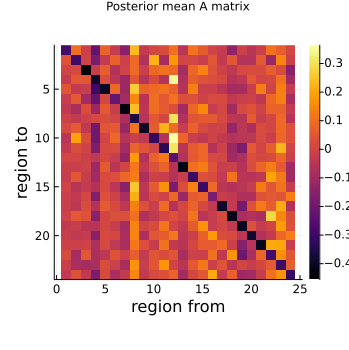

In [12]:
heatmap(
    output.m_all;
    yflip=true,
    title="Posterior mean A matrix",
    titlefontsize=8,
    xlabel="region from",
    ylabel="region to",
    aspect_ratio=1,
    size=(350, 350),
)

In [15]:
output

rigid rDCM output
    F:   -19489.33
    F_r: -910.60 ... -753.92
    iterations until convergence per region: 5 ... 5
    Posteriors:
        α: 152.50,...,152.50
        β: 2524.43,...,835.73
        μ: 24 x 24 matrix
        Σ: 24 element vector of matrices

In [16]:
propertynames(output)

(:F, :F_r, :iter_all, :a_all, :b_all, :m_all, :Σ_all, :inversion)

## Applying regression DCM  

In [19]:
# Initialize an array to store the output.m_all matrices
output_m_all = Array{Any, 2}(undef, 157, 10)
output_b_all = Array{Any, 2}(undef, 157, 10)
output_F = Array{Any, 2}(undef, 157, 10)
output_F_r = Array{Any, 2}(undef, 157, 10)

# Loop over subjects and sessions
for i_sub in 1:157
    for i_sess in 1:10

        # Construct the filename
        fname = string(prep_pth, "retdata/sorted/tSeries_subj-", i_sub, "_scan-", i_sess, "_24rois_allsubjects.mat")
        
        # Open the .mat file
        matfile = matopen(fname)
        
        # List all variable names in the MATLAB file
        varnames = names(matfile)
        println("Variables in the file for subject $(i_sub), session $(i_sess): ", varnames)
        
        if "data" in varnames
            tSeries = read(matfile, "data")
            println("Shape of tSeries: ", size(tSeries))
            println("Data: ", tSeries)
        end
                
        # Close the .mat file
        close(matfile)

        y_data = tSeries[1:length(labels), :]

        # Compute regression DCM within this loop
        nr = size(y_data,1)
        N = size(y_data,2)
        a = BitMatrix(ones(24, 24))
        c = BitMatrix(zeros(length(labels),0));
        U = nothing        
        Y = BoldY(transpose(y_data),2.0,labels)
        Ep = rDCM.TrueParamLinear(a,c;sample=false);
        dcm = LinearDCM(a,c,N,nr,U,Y,Ep,nothing)
        # Define options for DCM
        opt = Options(RigidInversionParams(); synthetic=false, rng=MersenneTwister(42))
        # Transform linear DCM model to regression DCM model
        rdcm = RigidRdcm(dcm)
        # Invert the model (estimate posterior of parameters)
        output = invert(rdcm, opt)
        # Store the output.m_all matrix
        output_m_all[i_sub, i_sess] = output.m_all
        output_b_all[i_sub, i_sess] = output.b_all
        output_F[i_sub, i_sess] = output.F
        output_F_r[i_sub, i_sess] = output.F_r
         
    end
end



Variables in the file for subject 1, session 1: ["data"]
Shape of tSeries: (24, 300)
Data: [-0.3419405519962311 -0.6376693248748779 -0.1692049354314804 0.1389259248971939 0.8674545884132385 -0.09990956634283066 -0.5284860730171204 -0.12365233898162842 0.5369775891304016 -0.259472131729126 0.3257284462451935 -0.13043439388275146 0.43843117356300354 -0.38640937209129333 0.18545056879520416 0.1385907232761383 -0.25737160444259644 -0.09387610852718353 -0.3342646658420563 -0.5674242377281189 0.22212058305740356 0.020703693851828575 -0.28873440623283386 0.427995502948761 0.393347829580307 0.38385072350502014 -0.06374234706163406 -0.531212329864502 0.7018138766288757 -0.6404625773429871 -1.1027146577835083 0.38964954018592834 -0.3076280653476715 0.5359720587730408 2.135206699371338 1.4753365516662598 2.107173442840576 2.5340070724487305 1.299606442451477 2.182915687561035 0.2177519053220749 -0.567535936832428 0.25871238112449646 0.14194265007972717 0.6270995736122131 0.26544973254203796 -0.07

Excessive output truncated after 524294 bytes.

 -0.3397553265094757 0.11924394220113754 -0.3130750358104706 -0.057499971240758896 -0.4570440351963043 -0.026745693758130074 0.4387994110584259 0.019454386085271835 0.4032845199108124 0.4398391544818878 0.2670057415962219 0.288284569978714 0.5377780795097351 1.0620524883270264 0.6547333002090454 0.22503656148910522 -0.042583853006362915 -0.8089559078216553 -0.5312715172767639 -0.6204085350036621 -1.2173084020614624 -0.11178261786699295 0.6781635284423828 1.4722687005996704 0.892730712890625 1.324304223060608 0.8292800188064575 1.0549050569534302 0.6127379536628723 0.5337172150611877 0.0016413616249337792 0.9083596467971802 1.039138913154602 0.3059079647064209 0.08108065277338028 0.12208853662014008 0.9029581546783447 0.15447764098644257 0.3826923072338104 0.7668166756629944 0.6560934782028198 1.740163803100586 1.6044342517852783 1.5509428977966309 0.7651426196098328 0.1821126788854599 0.2555096447467804 0.02567978948354721 -0.2309023141860962 -0.5022501349449158 -0.4617457687854767 0.0

In [20]:
output_b_all

157×10 Matrix{Any}:
 [2524.43, 1343.3, 1240.94, 1229.74, 1676.45, 1686.71, 890.191, 950.776, 1936.84, 1536.42  …  1178.46, 880.308, 1459.65, 1475.22, 863.985, 883.315, 1204.26, 1390.36, 1116.08, 835.725]   …  [28625.0, 18686.9, 18561.7, 19968.7, 24163.8, 24301.1, 19592.4, 20528.8, 24350.4, 23030.4  …  25790.4, 25172.5, 28445.6, 23159.1, 22009.4, 24756.9, 29861.6, 31433.7, 26585.9, 28955.1]
 [1111.19, 762.617, 851.749, 824.1, 874.869, 782.295, 942.9, 688.325, 721.973, 1135.14  …  726.03, 802.975, 795.273, 808.98, 654.198, 671.996, 833.015, 1059.88, 673.865, 517.128]           [15898.7, 15177.9, 13503.6, 13064.1, 13328.3, 13696.5, 12619.1, 10416.6, 14002.9, 16003.0  …  10472.6, 10568.2, 14693.1, 13656.7, 11281.3, 11628.8, 15731.8, 14267.3, 10573.1, 8740.54]
 [1574.55, 1686.55, 1655.27, 1531.71, 1613.36, 1543.72, 1639.63, 1529.1, 1537.29, 1794.37  …  1689.82, 1451.98, 1594.96, 1217.5, 1527.73, 1649.75, 1303.07, 1358.12, 1731.25, 1601.86]       [10292.8, 12067.2, 10046.1, 13257.6, 9743.95,

### Save rDCM results


In [21]:
#pth = prep_pth * "retdata/sorted/"
save_path = "/home/nicolas/Documents/GitHubProjects/retNet/docs_local/source/notebooks/results_rDCM/"

# Define the dimensions based on the data structure
num_rois = 24  # Number of ROIs
num_sessions = 10  # Number of sessions

# Initialize arrays with appropriate dimensions
output_m_all_array = Array{Float64, 3}(undef, num_rois, num_rois, num_sessions)
output_b_all_array = Array{Float64, 2}(undef, num_sessions, num_rois)  # Adjusted dimensions
output_F_array = Array{Float64, 1}(undef, num_sessions)  # Adjusted dimensions
output_F_r_array = Array{Float64, 2}(undef, num_rois, num_sessions)  # Adjusted dimensions

# Loop over subjects and sessions
for i_sub in 1:157
    for i_sess in 1:num_sessions
        if output_m_all[i_sub, i_sess] !== nothing
            output_m_all_array[:, :, i_sess] = output_m_all[i_sub, i_sess]
            output_b_all_array[i_sess, :] = output_b_all[i_sub, i_sess]
            output_F_array[i_sess] = output_F[i_sub, i_sess]
            output_F_r_array[:, i_sess] = output_F_r[i_sub, i_sess]
        end
    end

    # Save the arrays as .npy files
    npzwrite(save_path  * "rDCM_EC_(Julia)_subj_" * string(i_sub) * ".npy", output_m_all_array)
    npzwrite(save_path  * "rDCM_beta_(Julia)_subj_" * string(i_sub) * ".npy", output_b_all_array)
    npzwrite(save_path  * "rDCM_F_(Julia)_subj_" * string(i_sub) * ".npy", output_F_array)
    npzwrite(save_path  * "rDCM_F_r_(Julia)_subj_" * string(i_sub) * ".npy", output_F_r_array)
end

## Load and plot the rDCM EC 

In [22]:
n_sub = 157


# Initialize arrays
EC_dcm = Array{Float64, 4}(undef, 10, n_sub, 24, 24)
F_dcm = Array{Float64, 2}(undef, 10, n_sub)

for i_sub in 1:n_sub
    # Load EC data
    fname = save_path * "rDCM_EC_(Julia)_subj_" * string(i_sub) * ".npy"
    ec_data = npzread(fname)
    
    # Load F data
    fname_f = save_path * "rDCM_F_(Julia)_subj_" * string(i_sub) * ".npy"
    f_data = npzread(fname_f)
    
    for i_cond in 1:10
        EC_dcm[i_cond, i_sub, :, :] = transpose(ec_data[:, :, i_cond])
        F_dcm[i_cond, i_sub] = f_data[i_cond]
    end
end

In [23]:
# Index dictionary
conf = Dict(
    "tasks" => ["vfm", "movie", "rest"],
    "eccen" => ["fovea", "para-fovea"],
    "fovea" => [
        [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22],  # < fovea
        [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23],   # > fovea
    ],
    "roiname" => ["V1", "V2", "V3"],
    "rois" => [
        [0, 1, 2, 3, 12, 13, 14, 15],   # V1
        [4, 5, 6, 7, 16, 17, 18, 19],   # V2
        [8, 9, 10, 11, 20, 21, 22, 23],  # V3
    ],
    "task" => [
        [0, 1],     # retinotopy
        [2, 3, 4, 5], # movie watching
        [6, 7, 8, 9],  # resting state
    ],
    "hemis" => ["left", "right"],
)

Dict{String, Vector} with 7 entries:
  "rois"    => [[0, 1, 2, 3, 12, 13, 14, 15], [4, 5, 6, 7, 16, 17, 18, 19], [8,…
  "task"    => [[0, 1], [2, 3, 4, 5], [6, 7, 8, 9]]
  "tasks"   => ["vfm", "movie", "rest"]
  "fovea"   => [[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22], [1, 3, 5, 7, 9, 11…
  "roiname" => ["V1", "V2", "V3"]
  "hemis"   => ["left", "right"]
  "eccen"   => ["fovea", "para-fovea"]

In [24]:
using LinearAlgebra

# Average EC_dcm over task conditions, excluding diagonals
EC_avg = Array{Float64, 4}(undef, 3, n_sub, 24, 24)
diagonals = Array{Float64, 3}(undef, 3, n_sub, 24)

for i_cond in 1:3
    sessions = conf["task"][i_cond] .+ 1  # Convert 0-based to 1-based indices
    for i_sub in 1:n_sub
        avg_matrix = dropdims(mean(EC_dcm[sessions, i_sub, :, :], dims=1), dims=1)
        diagonals[i_cond, i_sub, :] = diag(avg_matrix)
        avg_matrix .-= Diagonal(diagonals[i_cond, i_sub, :])
        EC_avg[i_cond, i_sub, :, :] = avg_matrix
    end
end

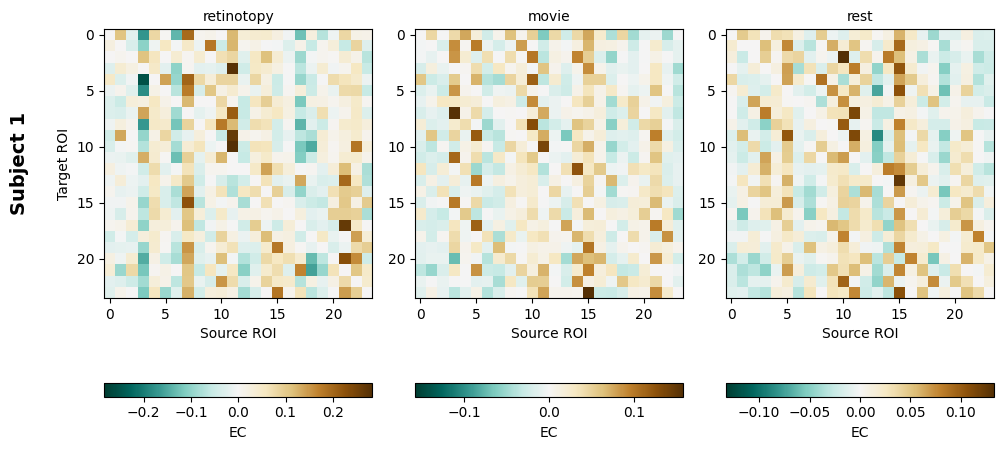

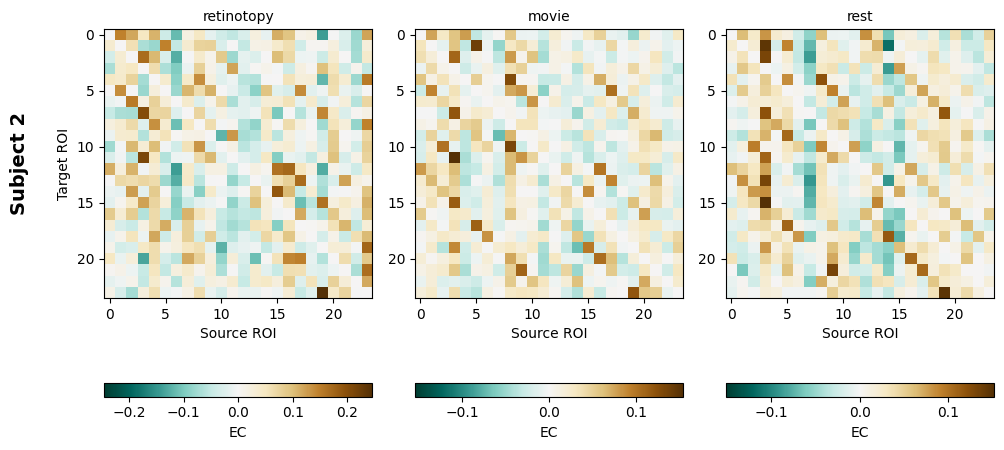

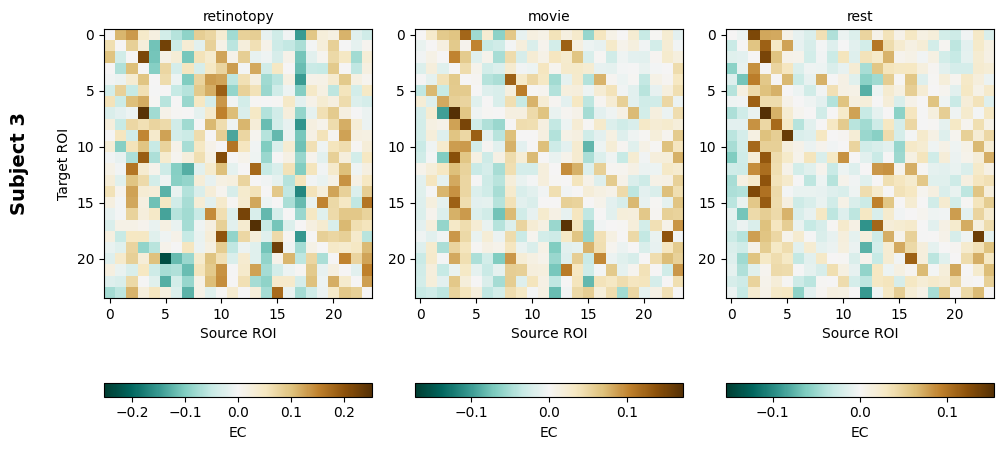

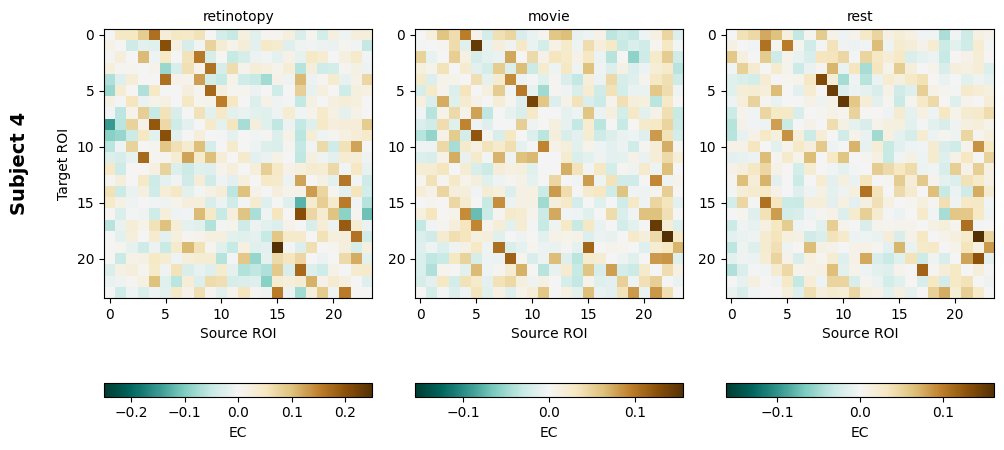

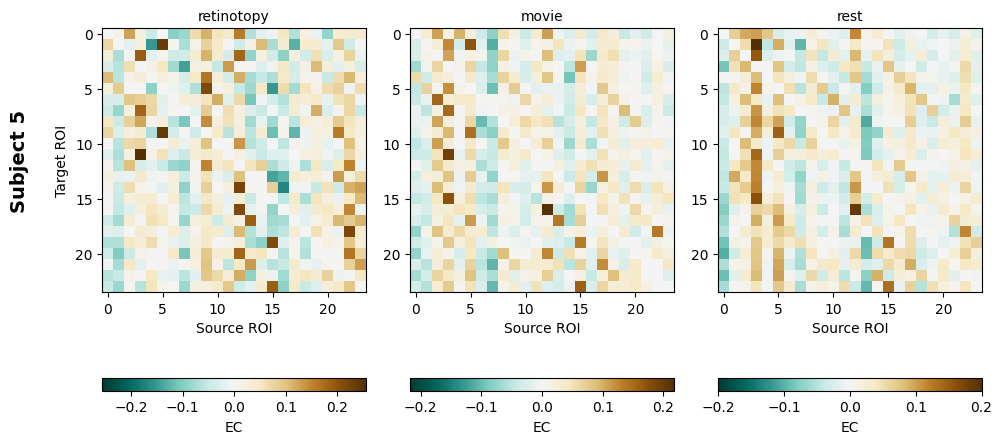

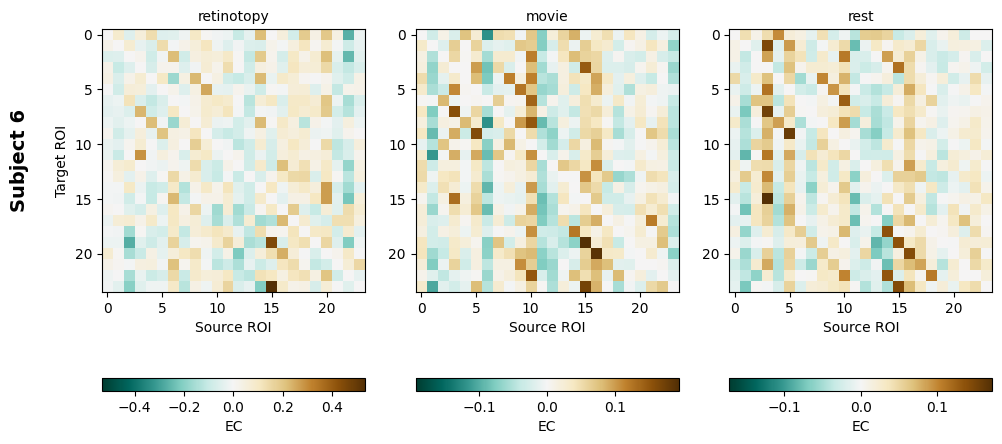

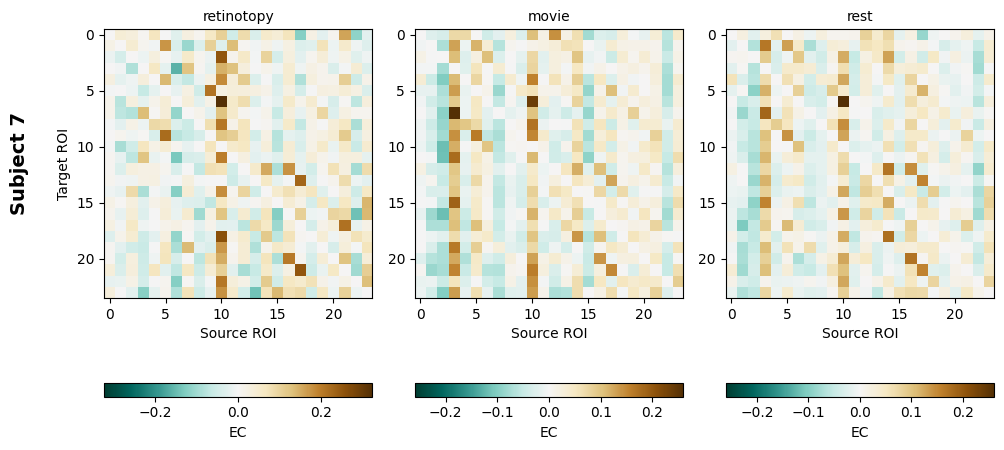

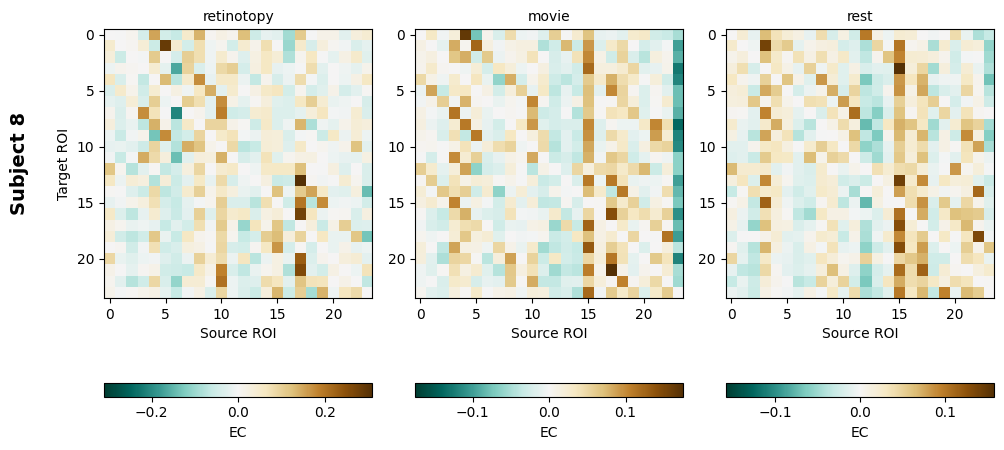

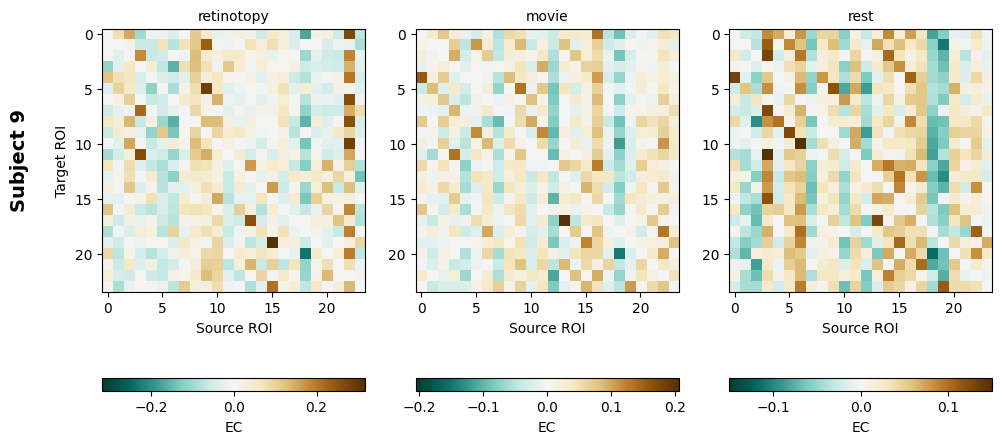

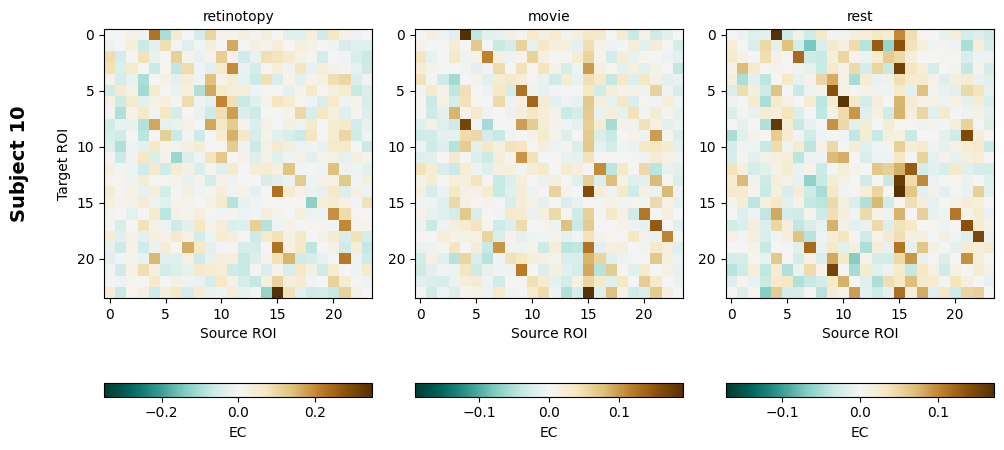

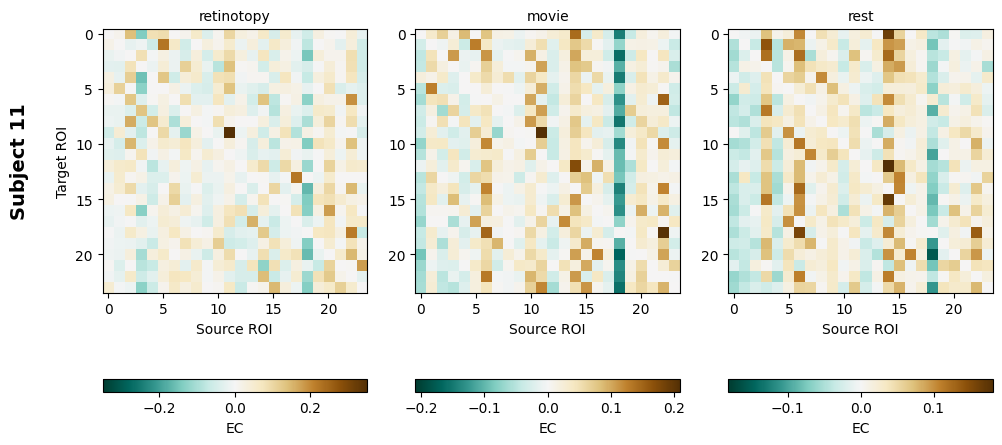

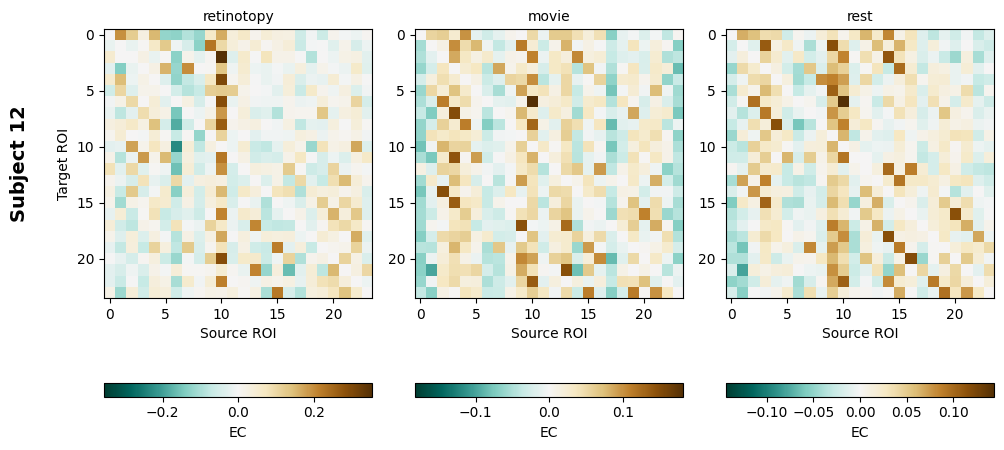

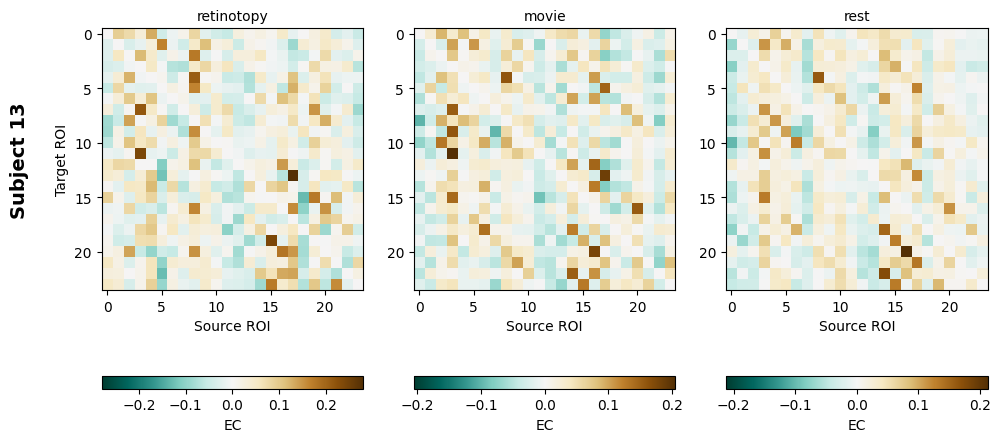

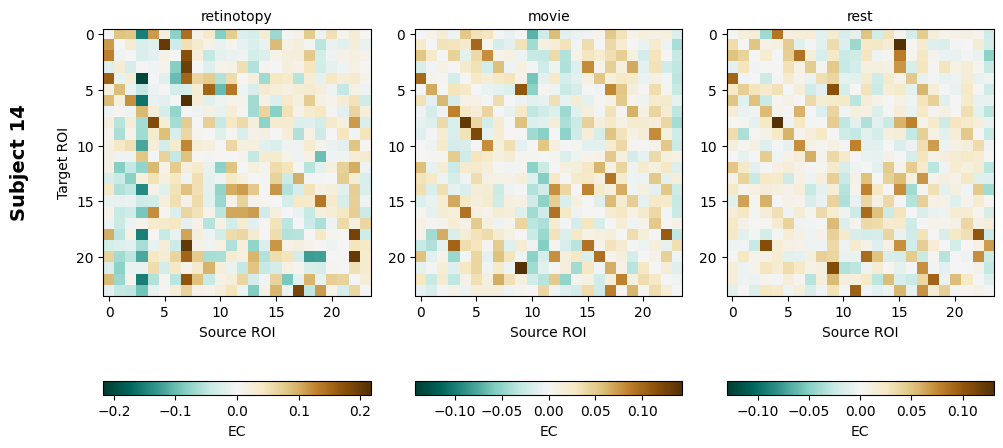

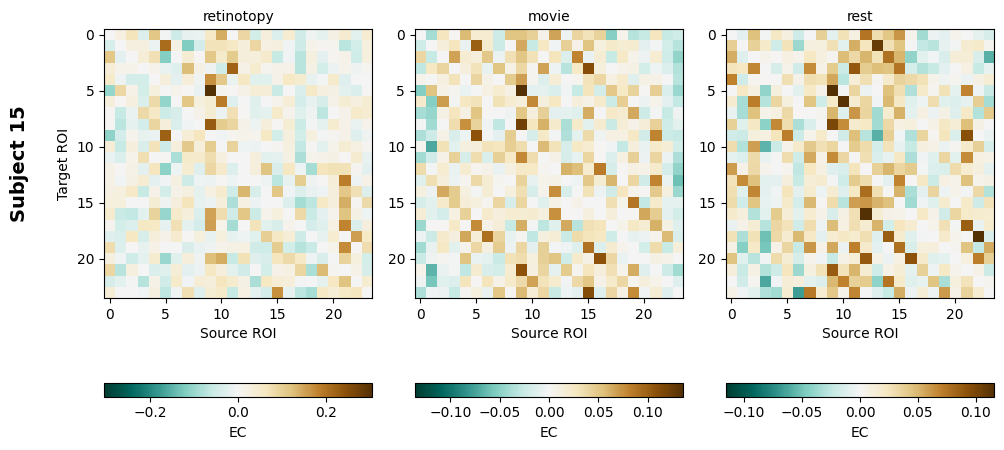

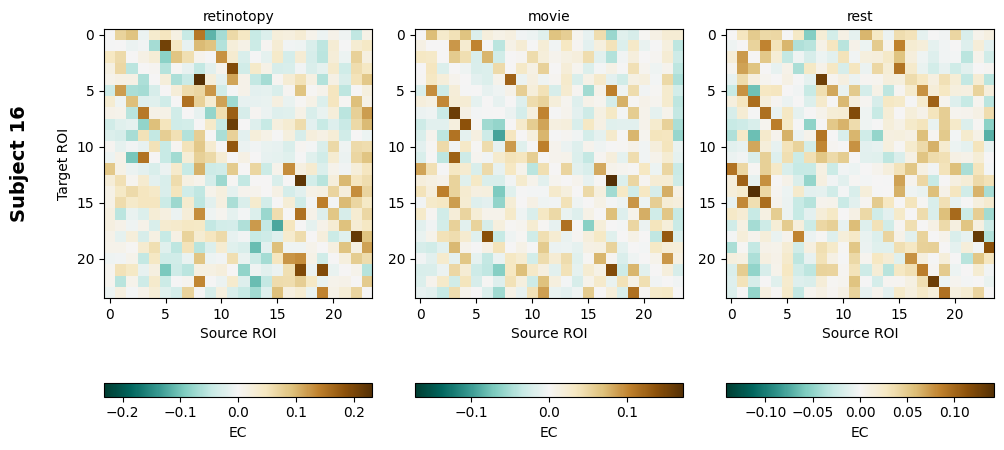

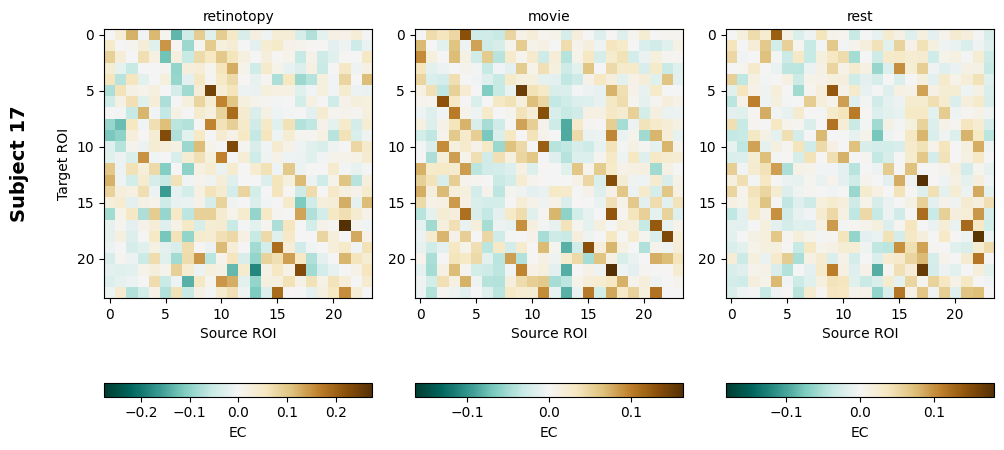

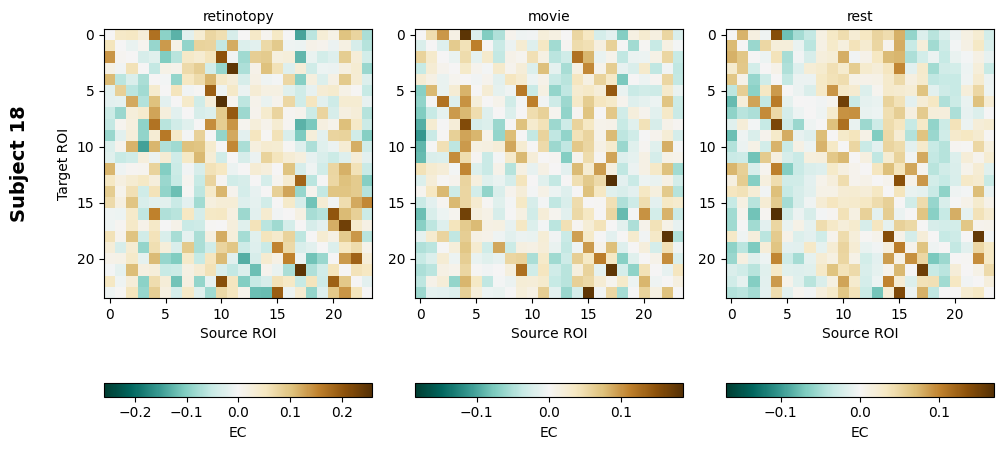

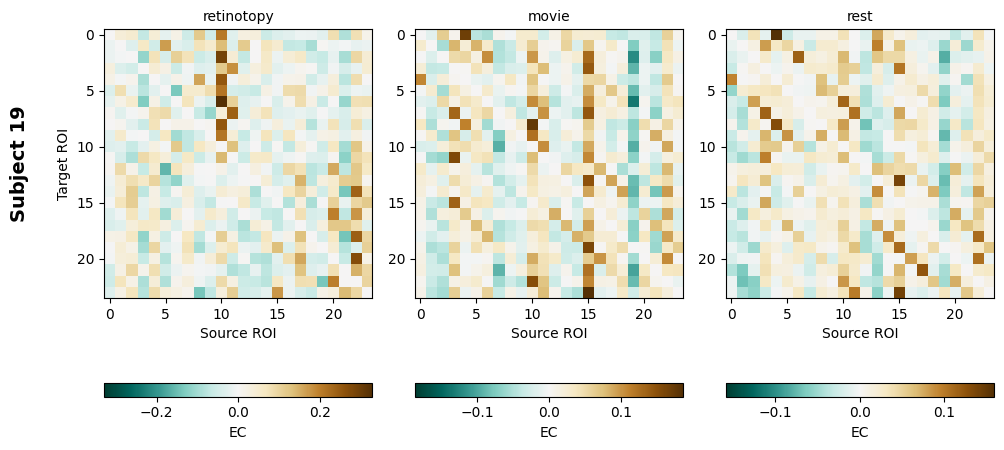

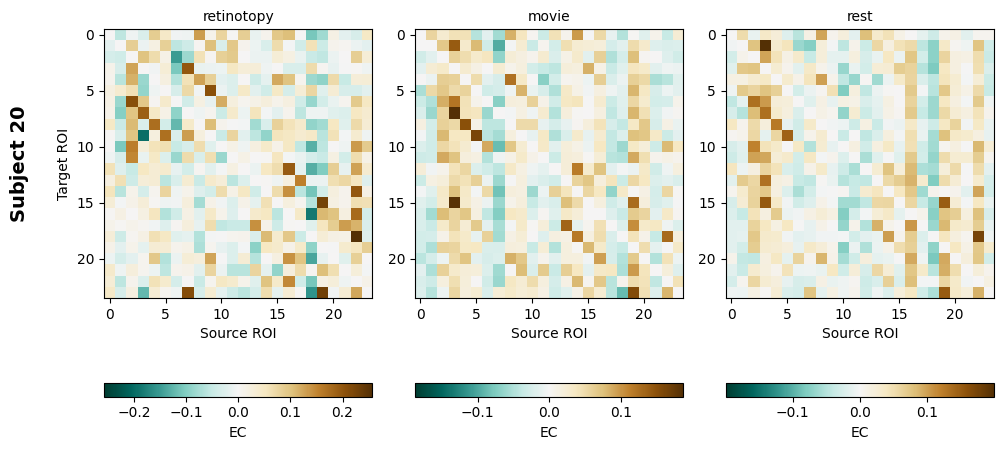

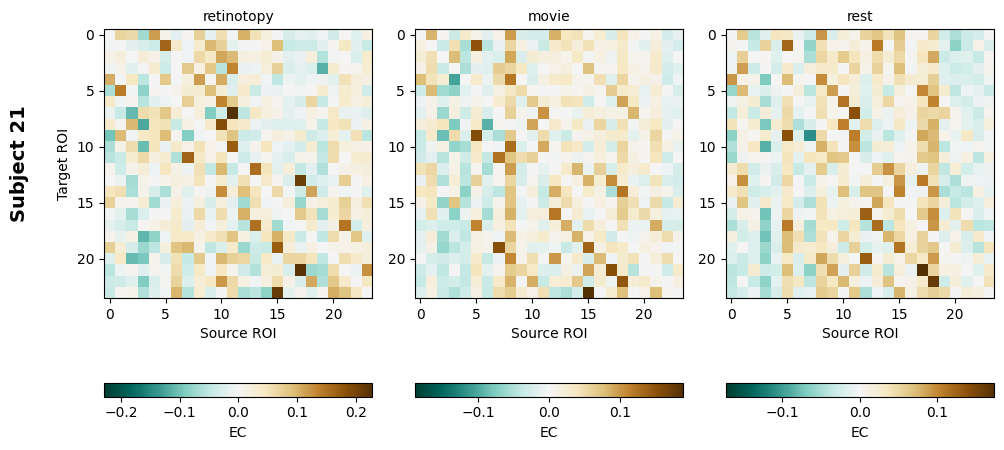

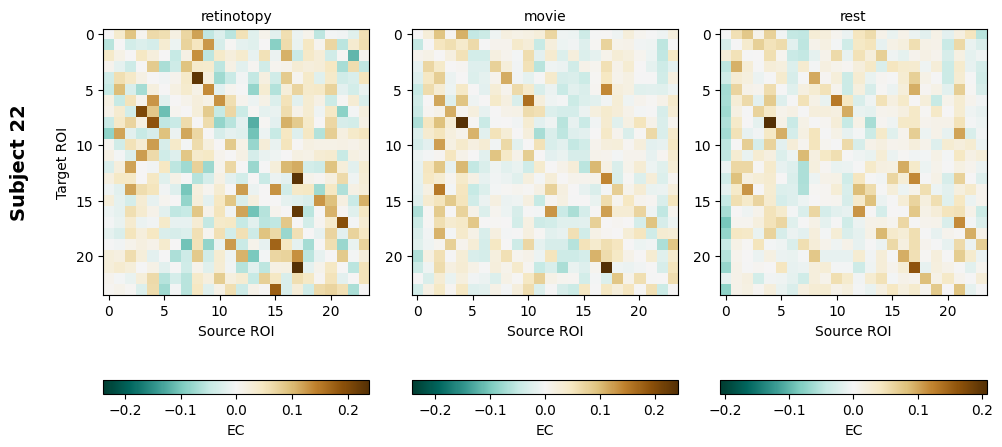

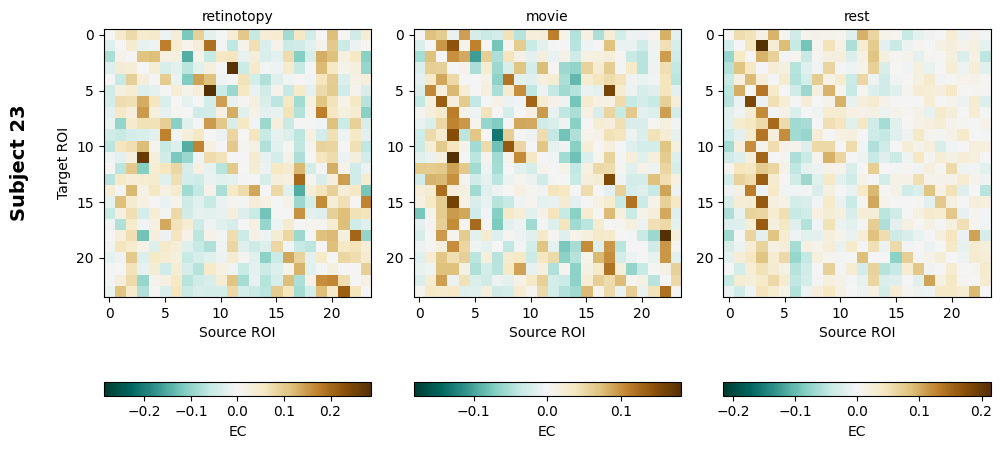

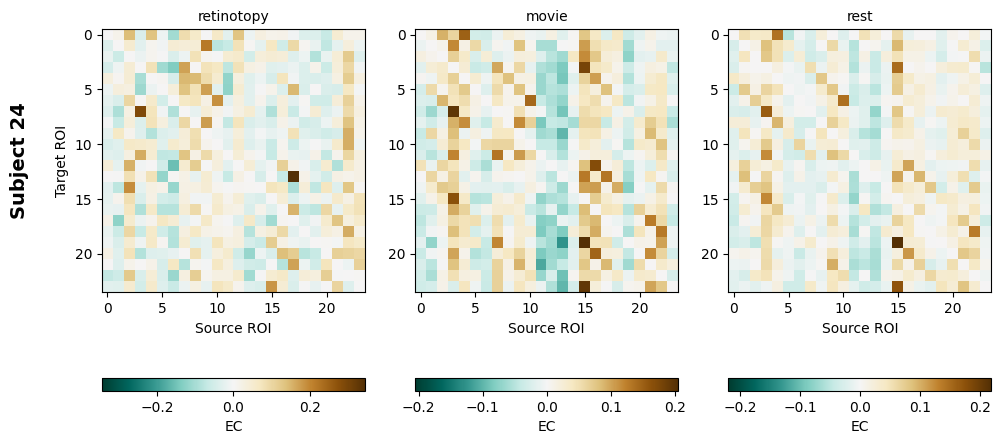

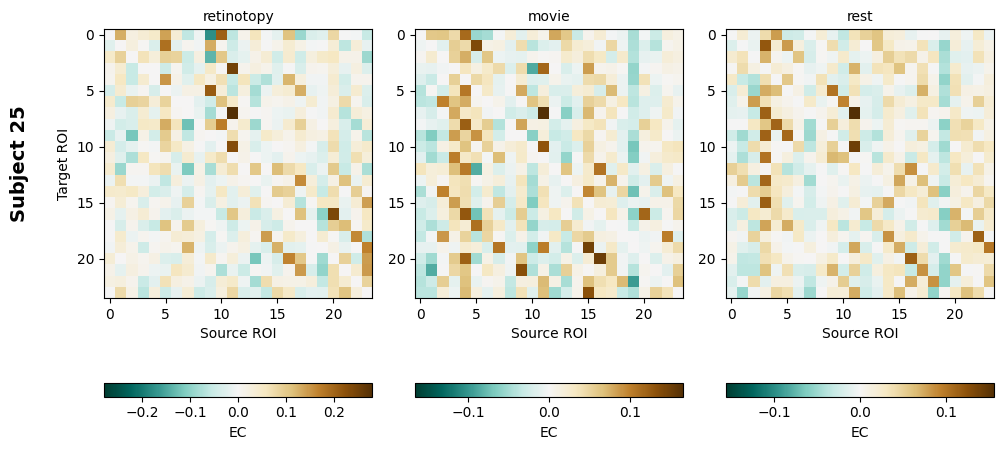

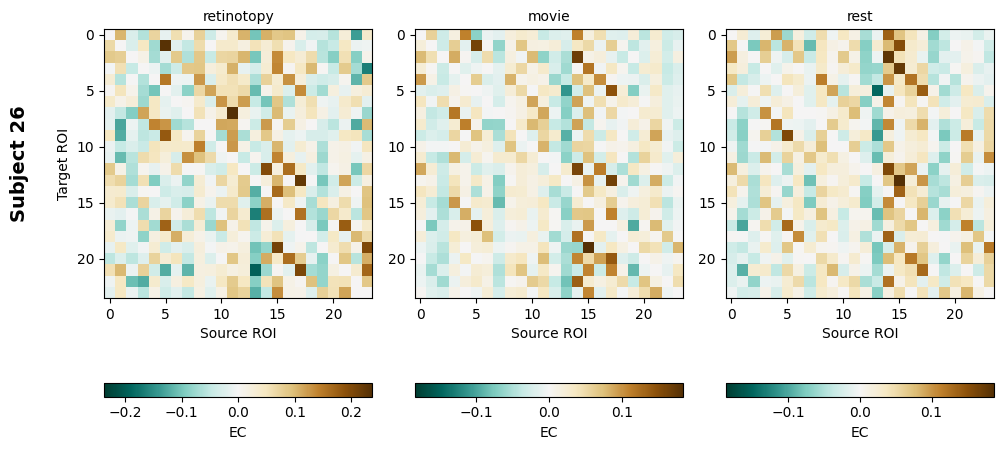

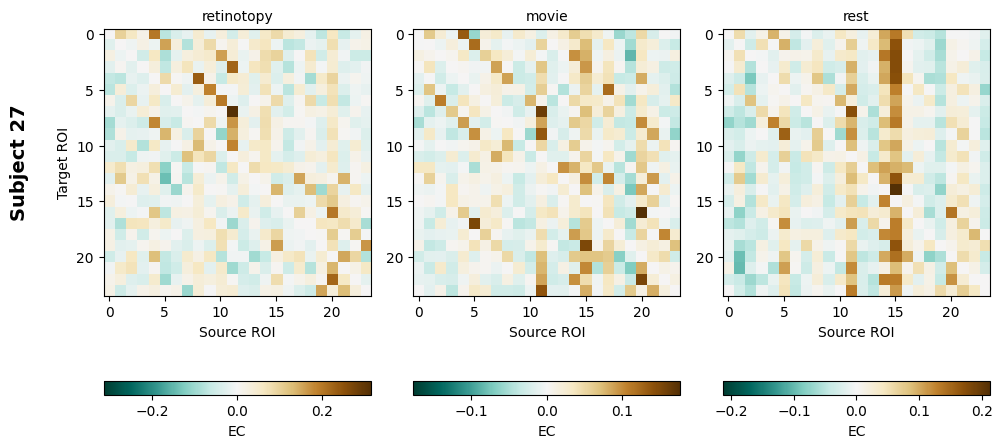

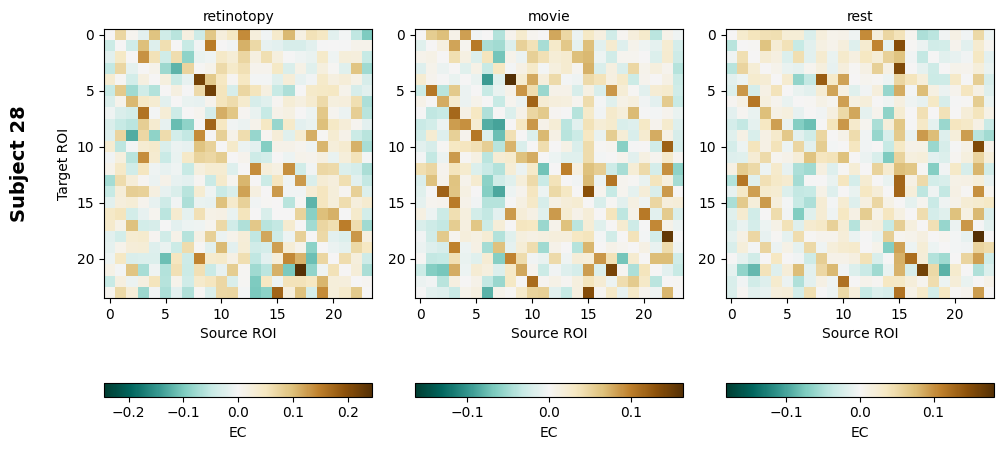

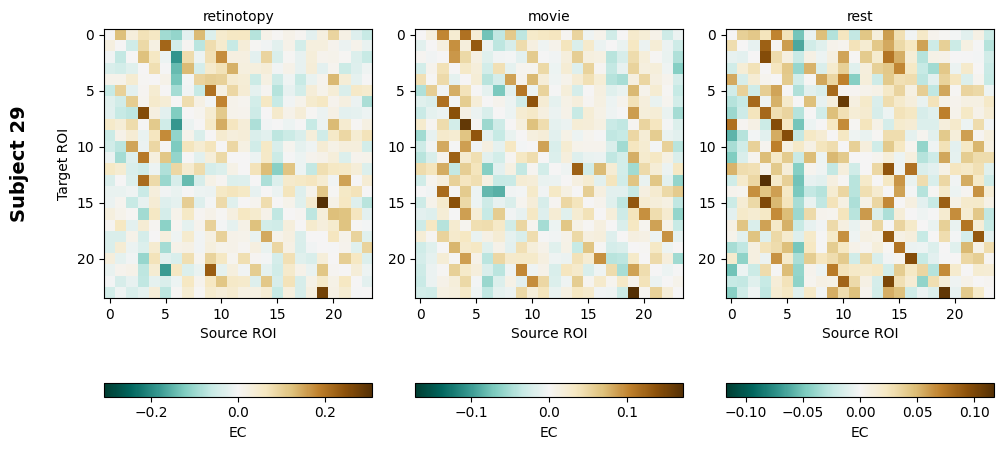

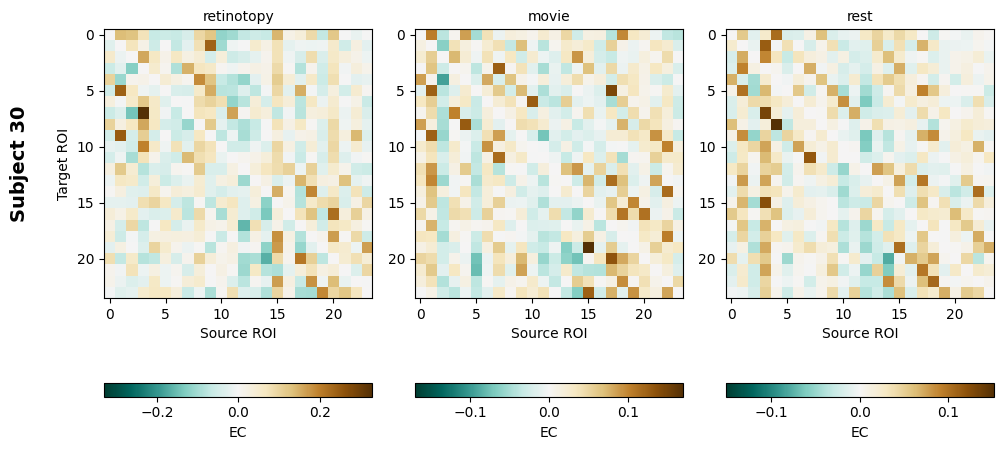

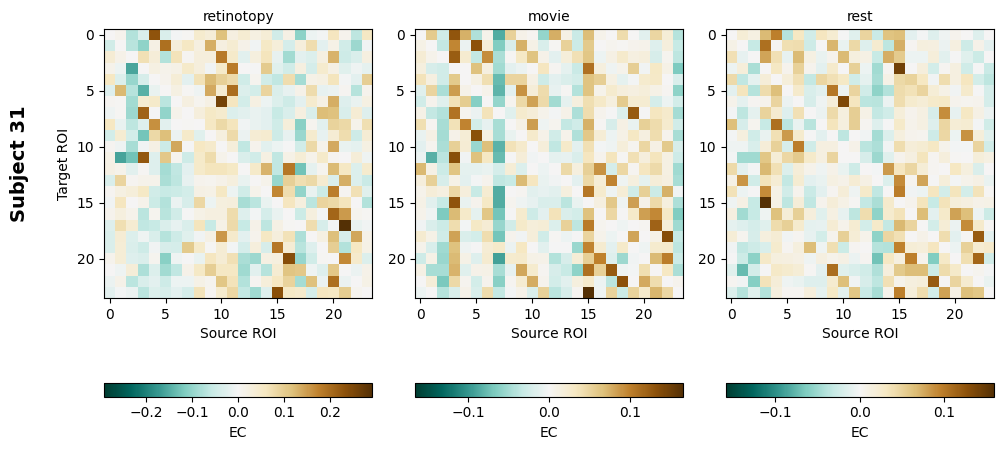

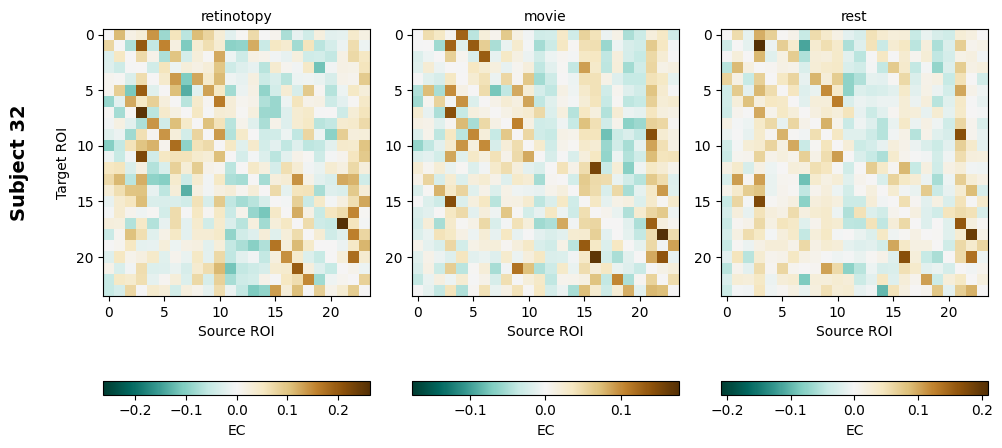

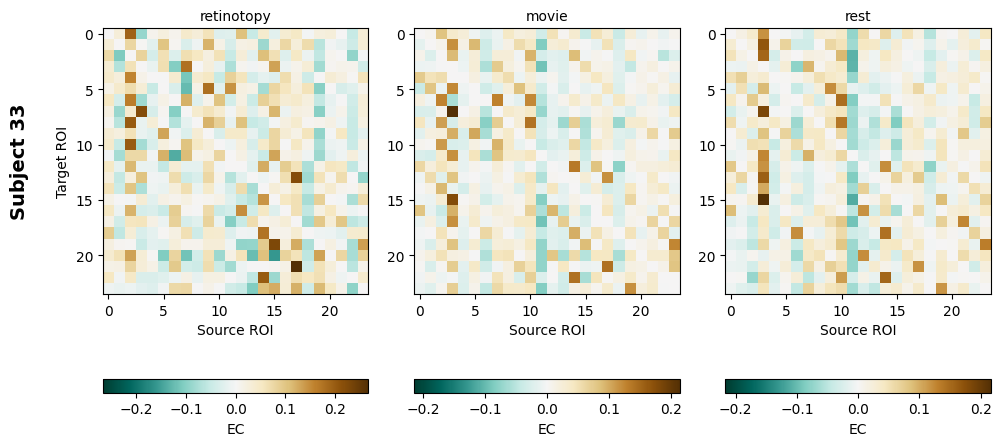

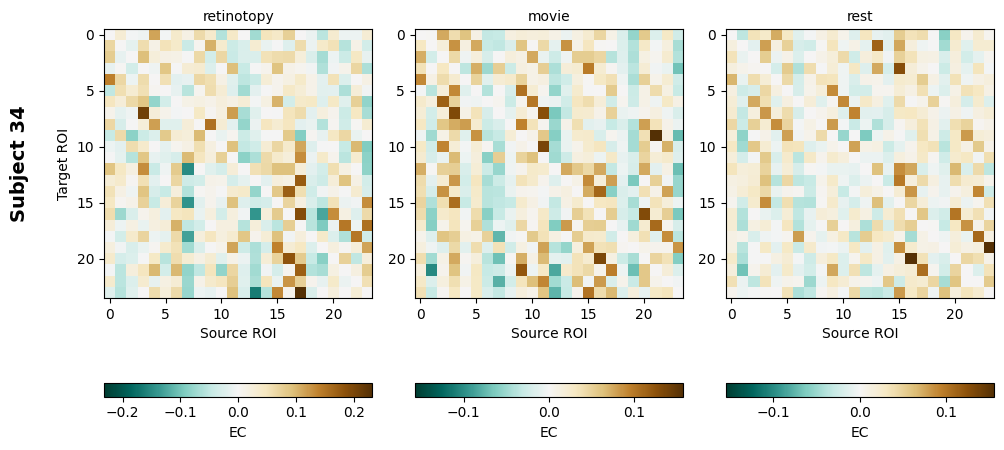

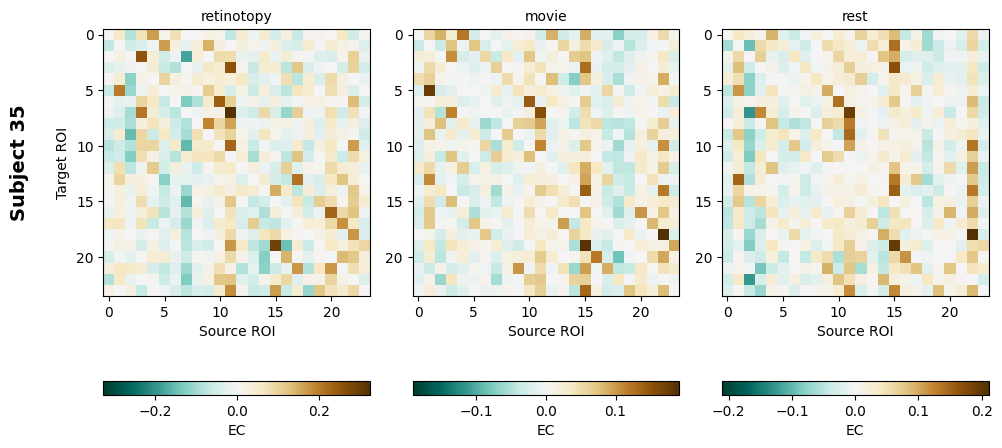

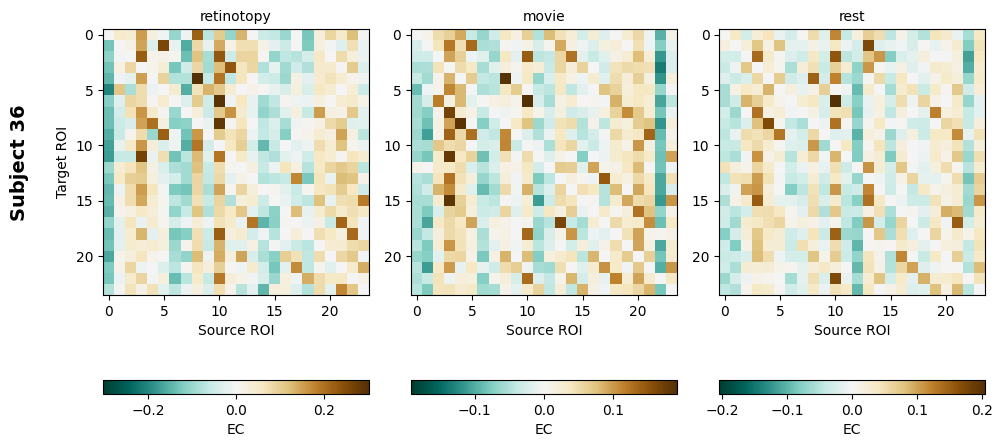

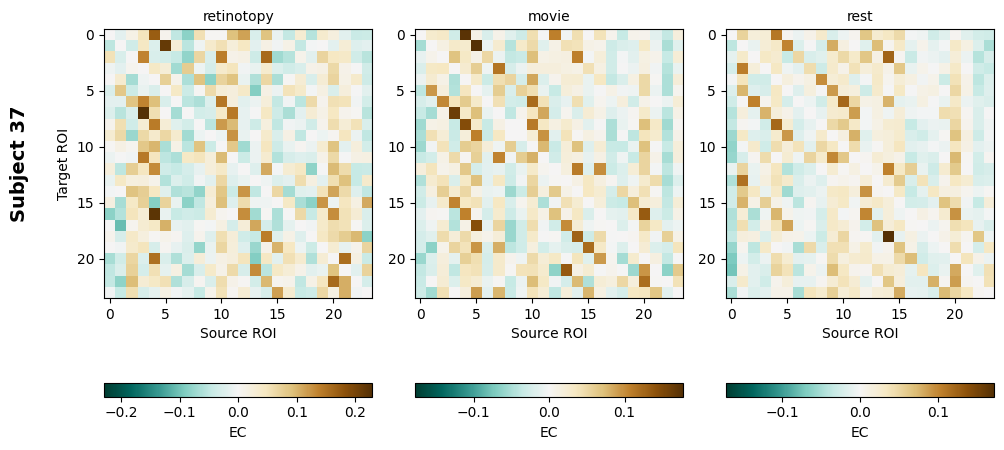

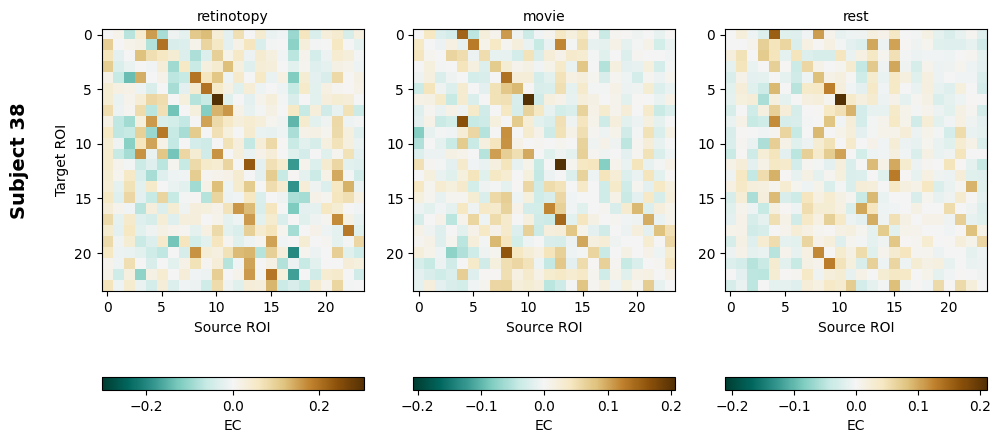

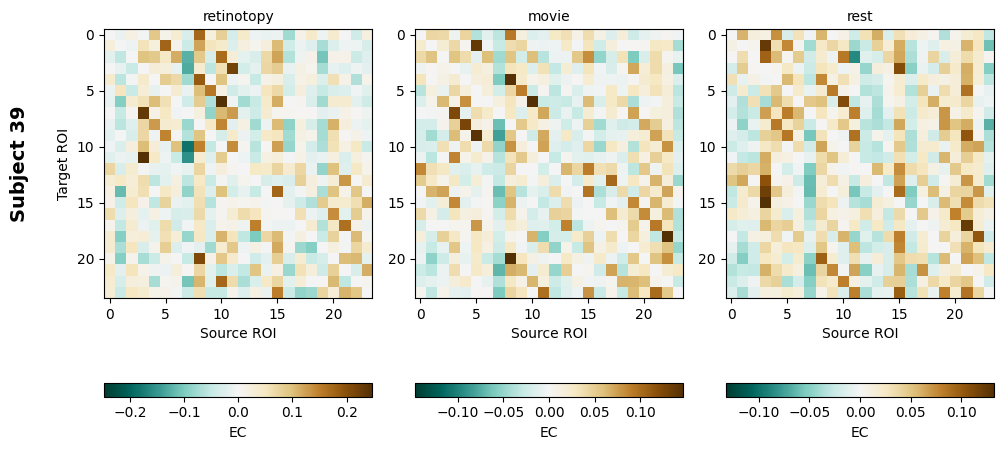

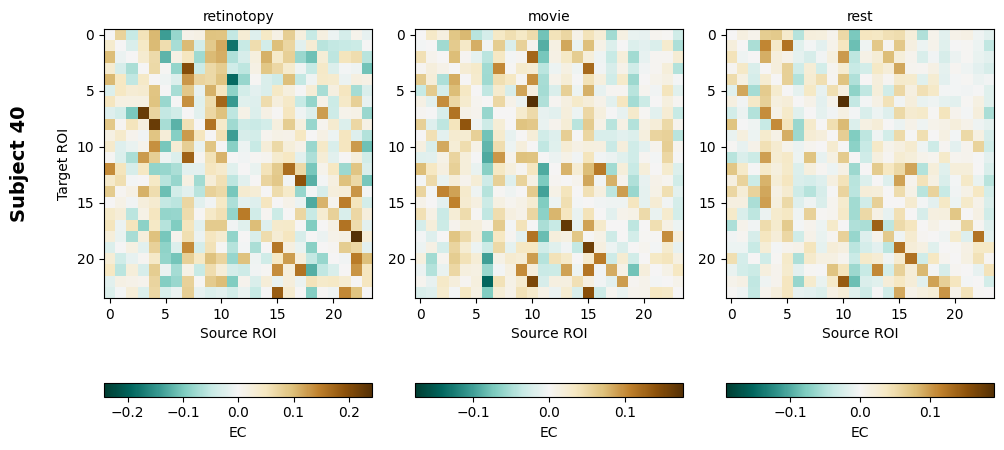

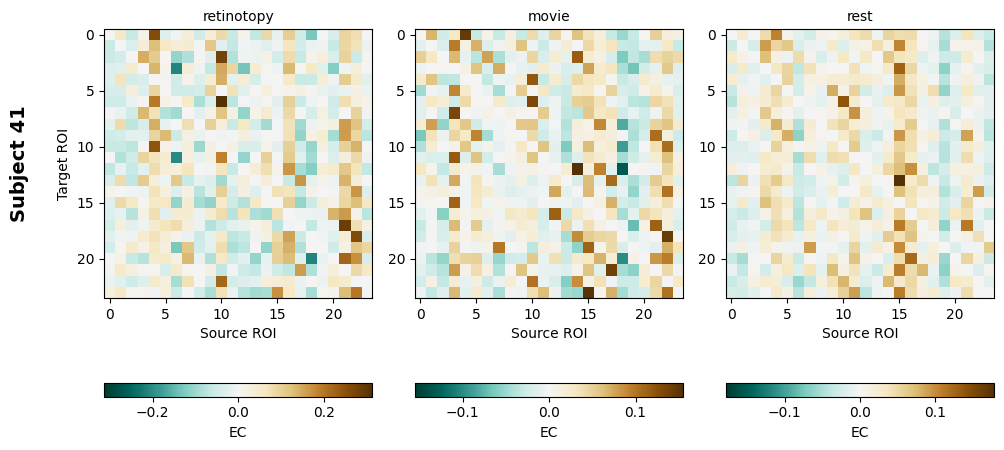

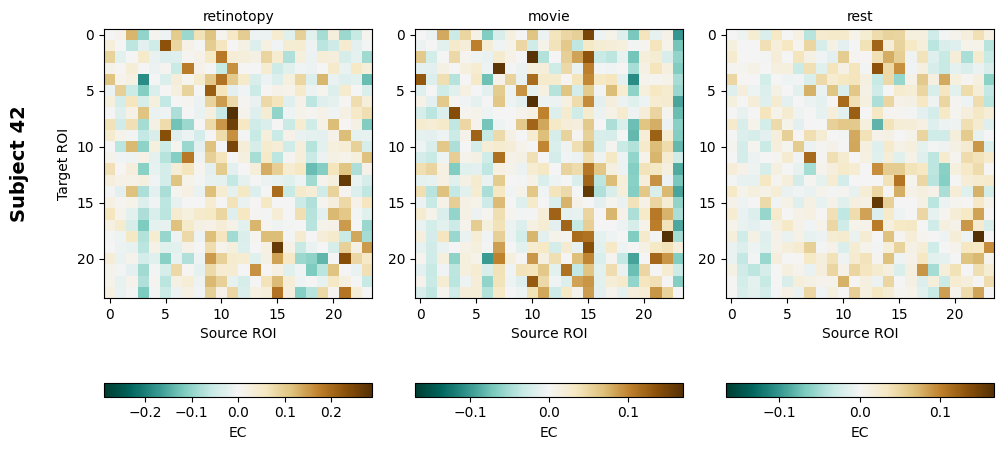

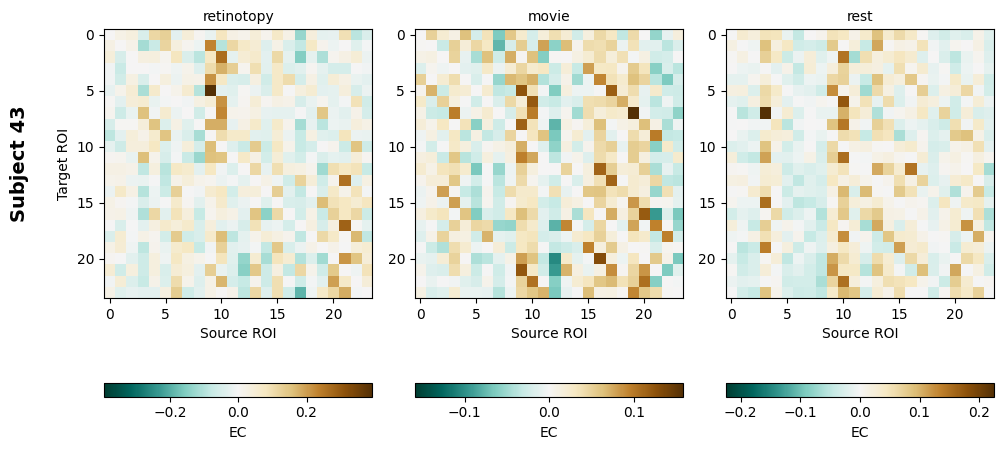

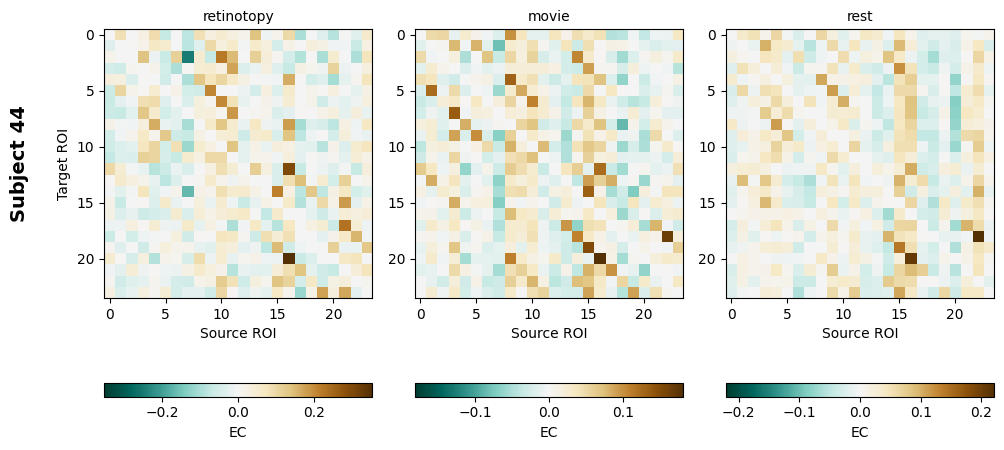

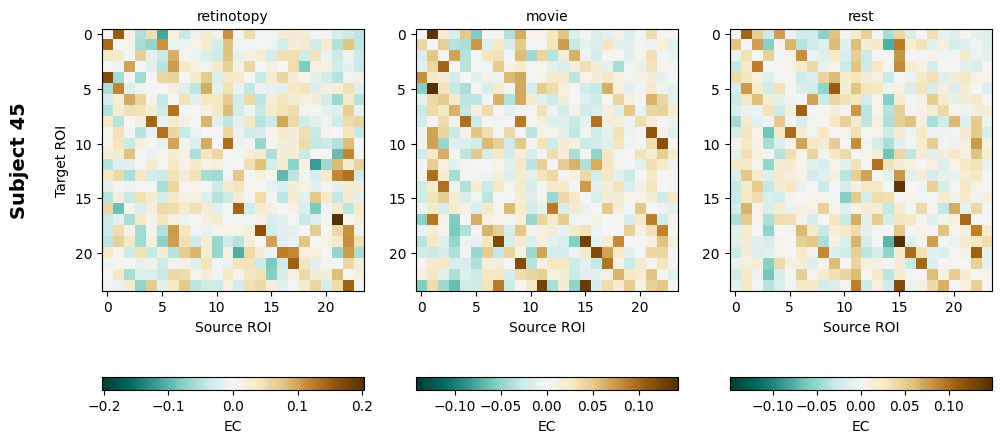

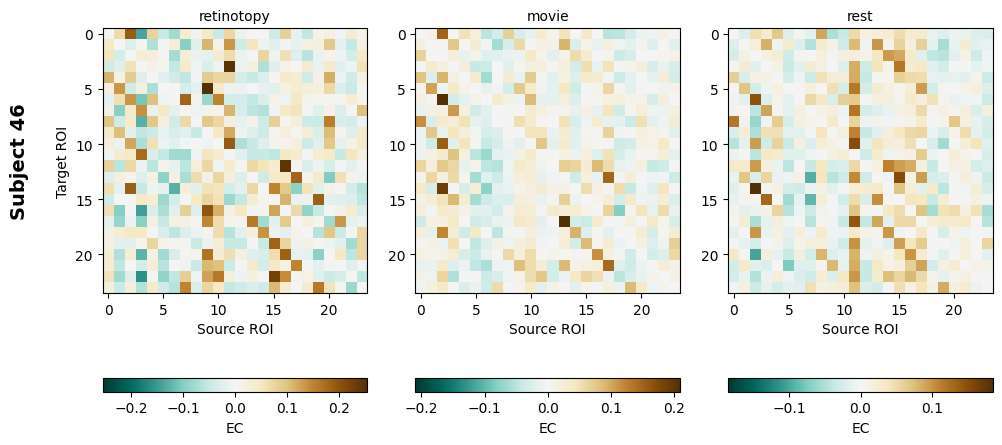

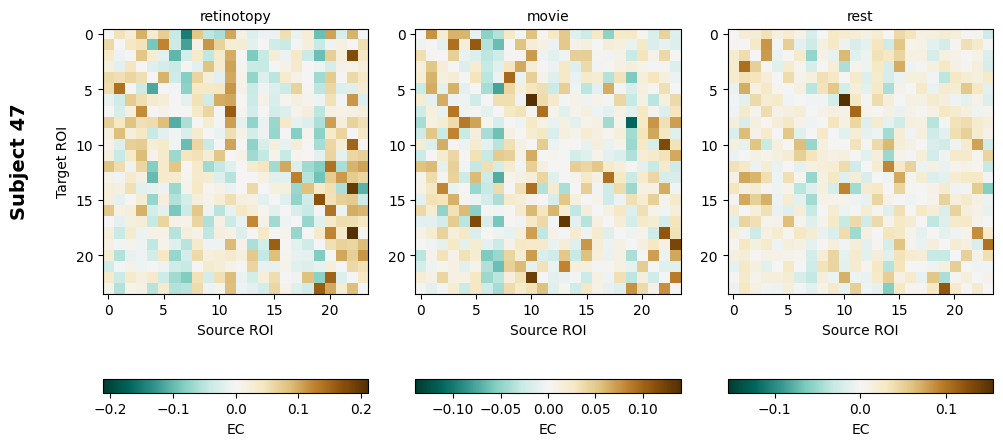

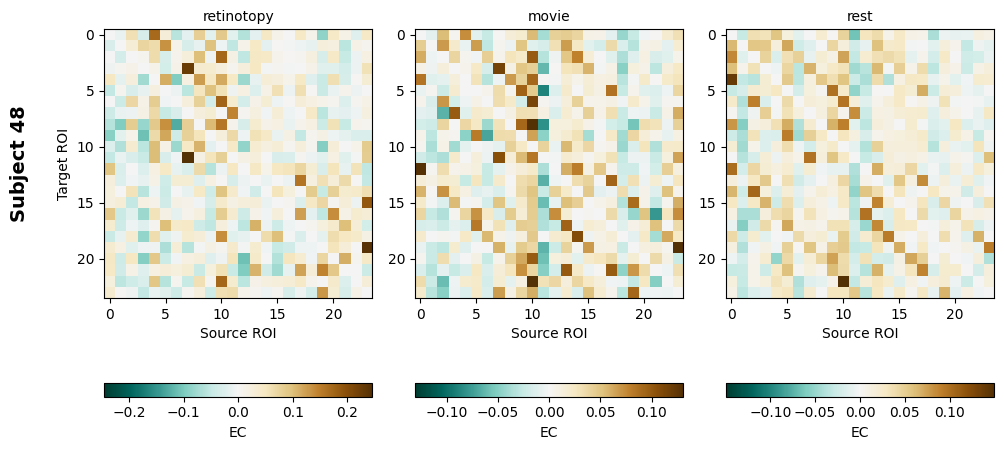

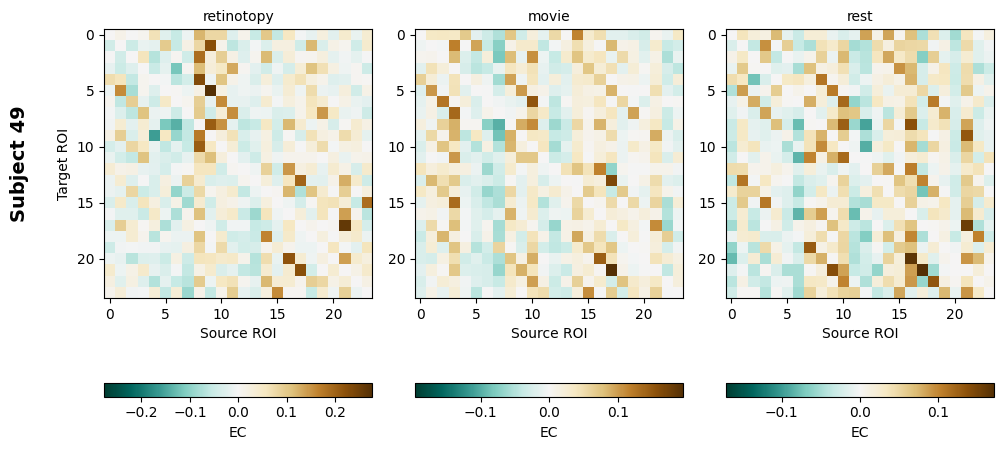

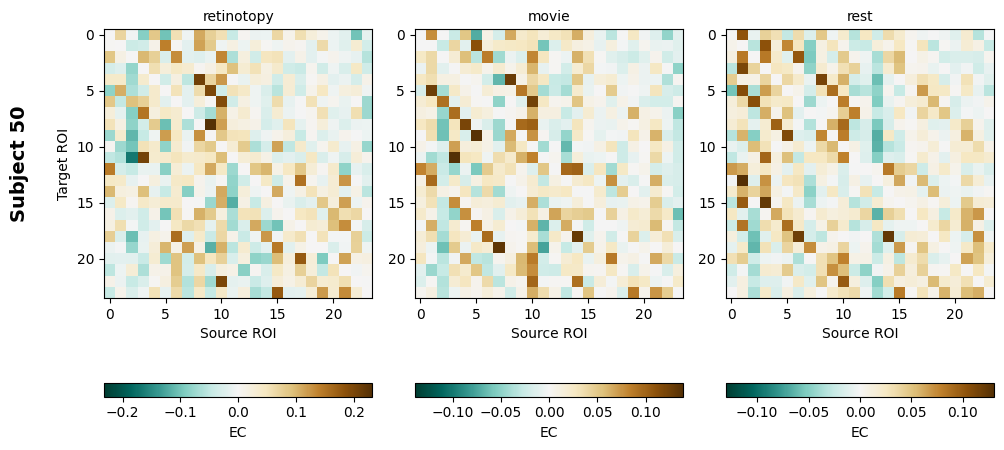

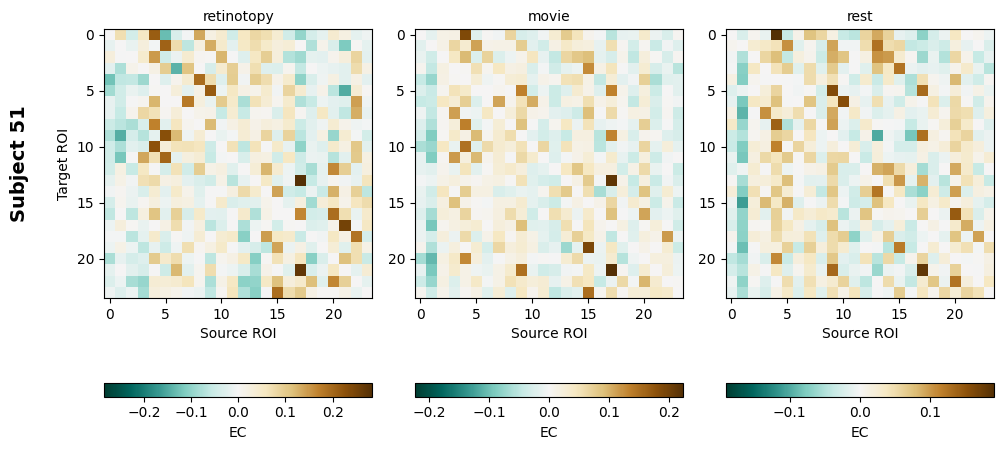

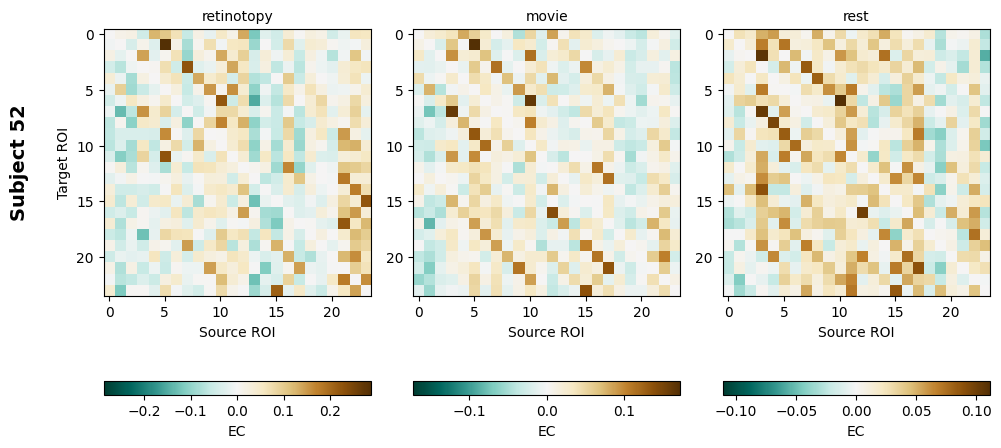

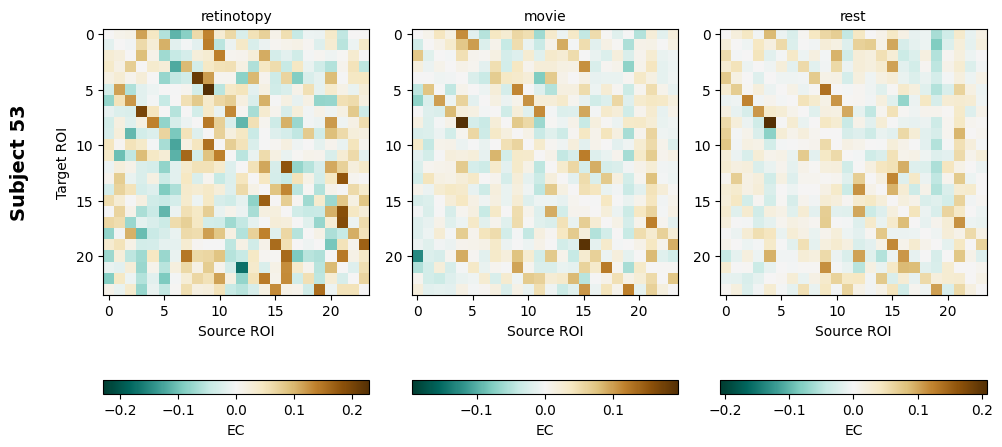

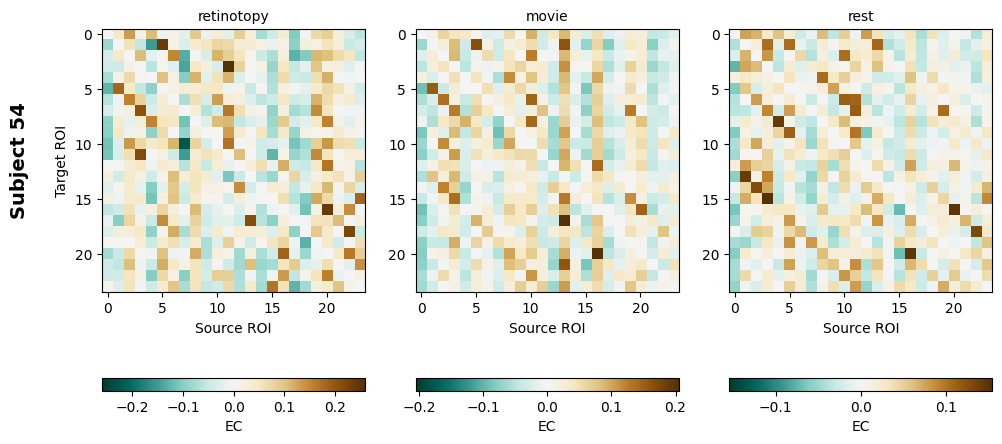

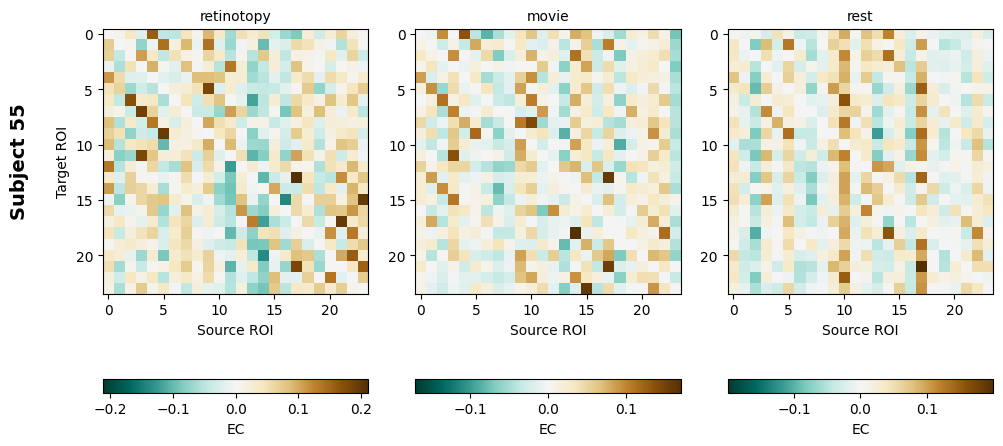

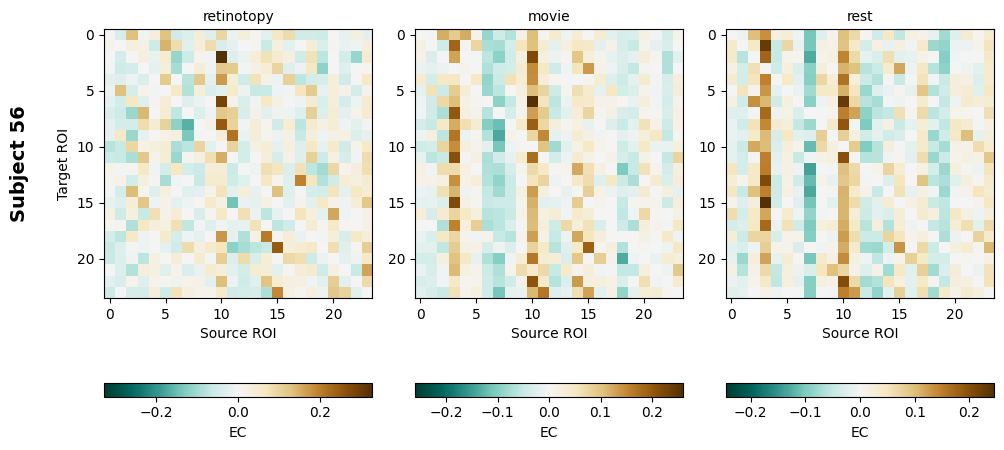

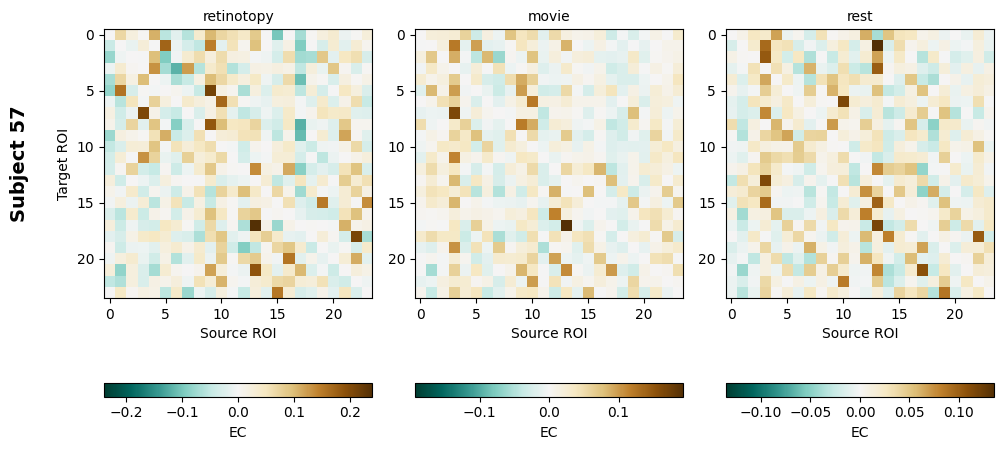

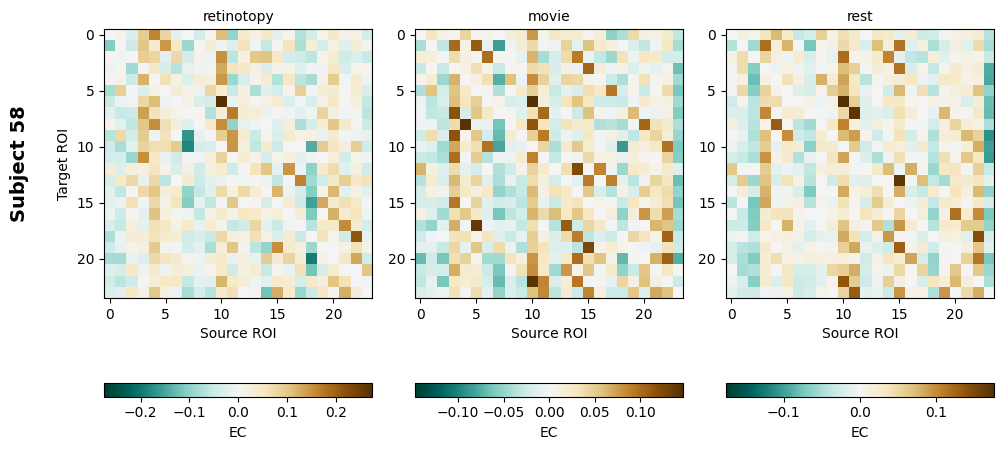

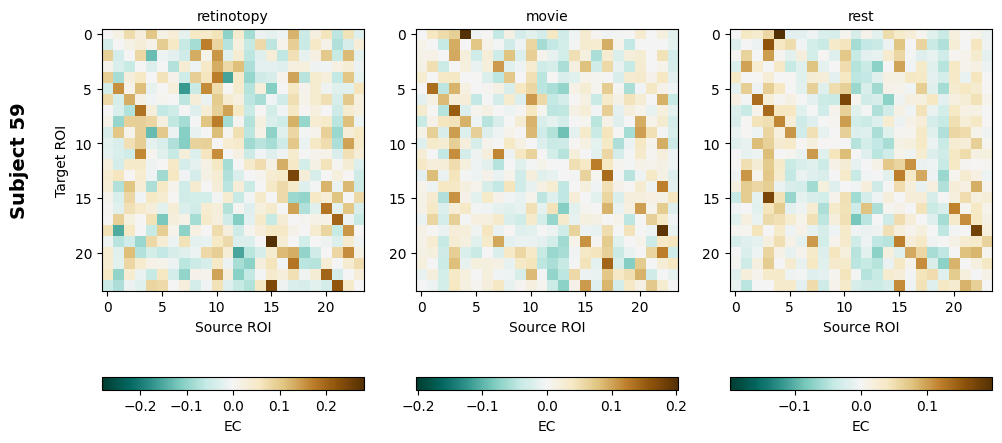

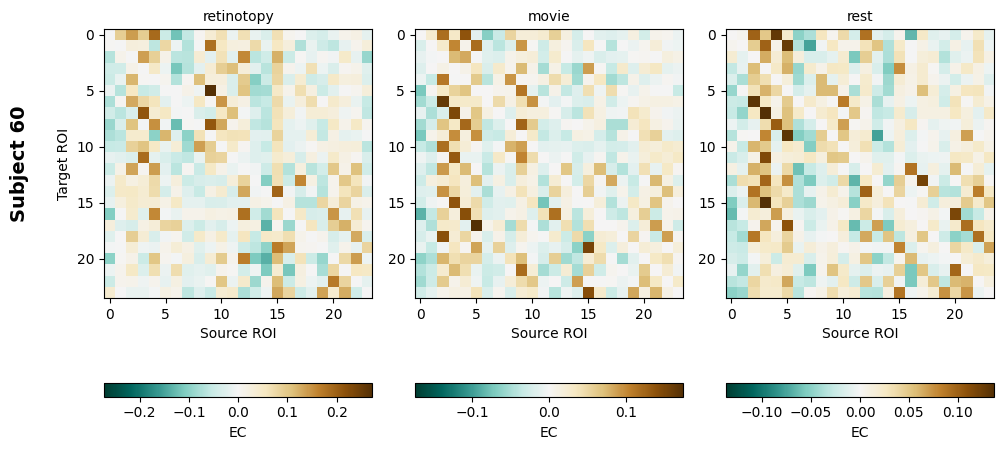

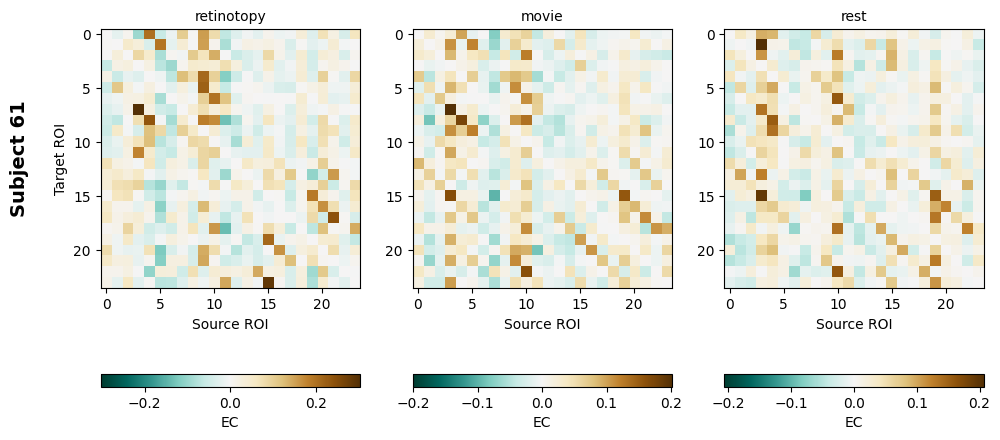

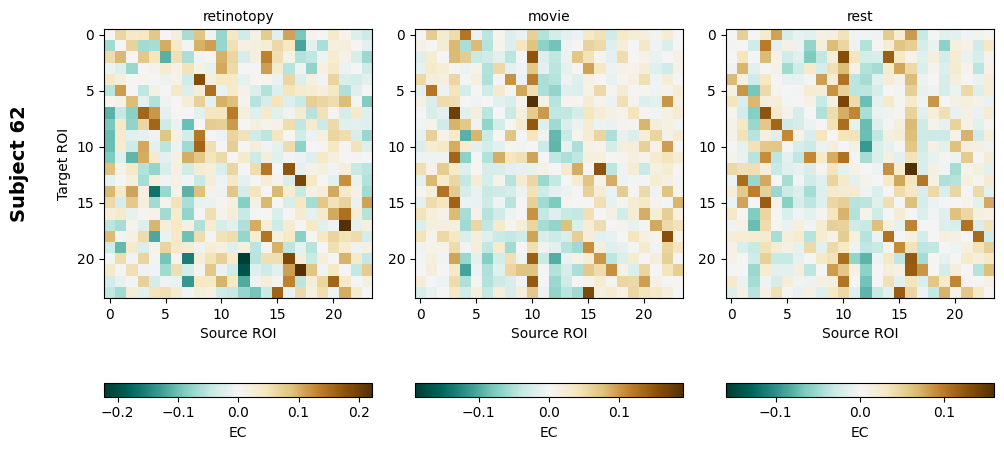

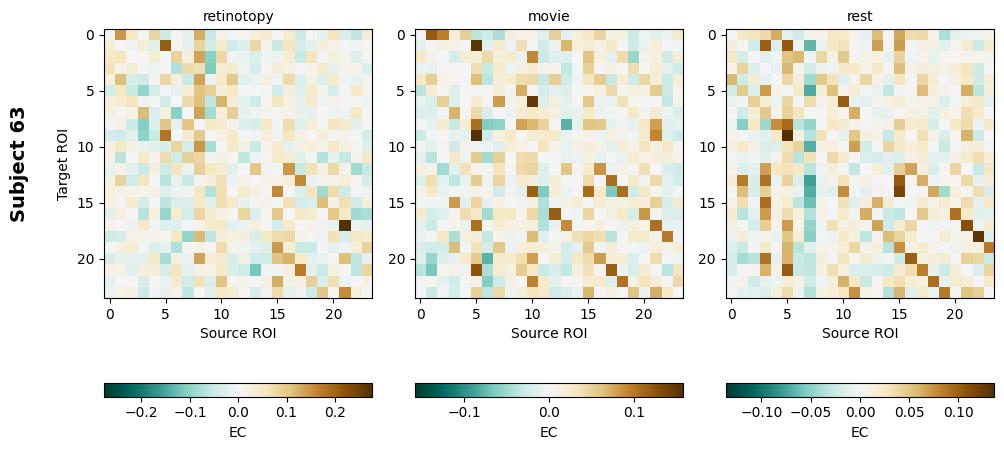

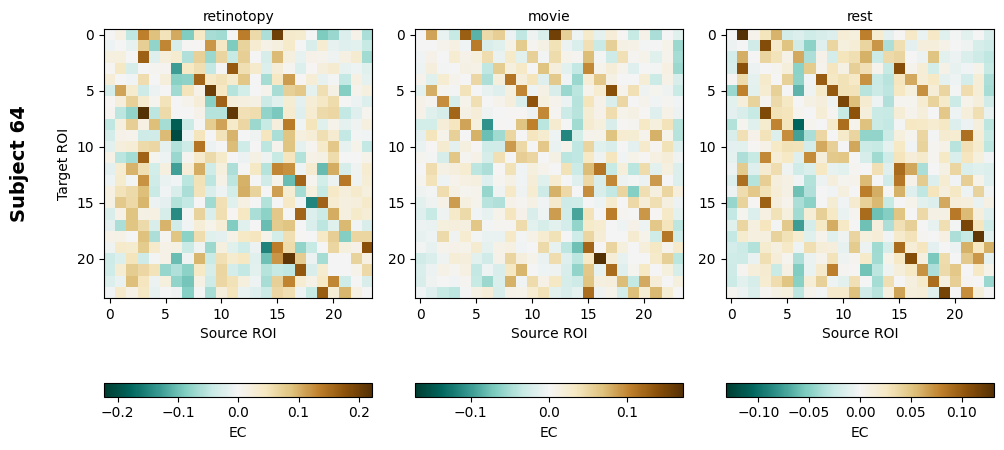

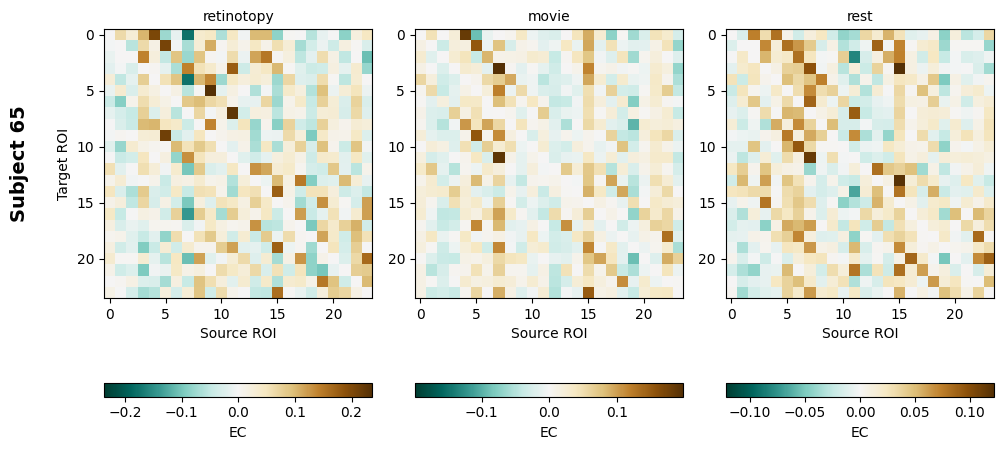

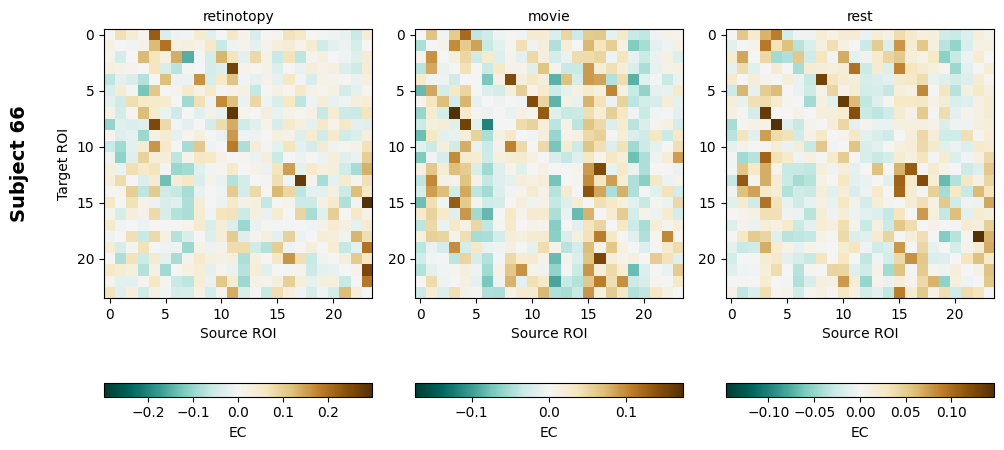

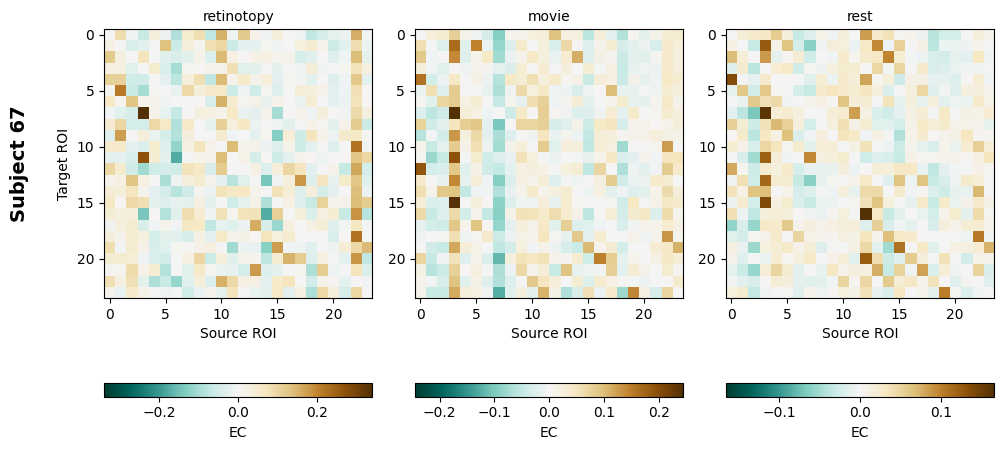

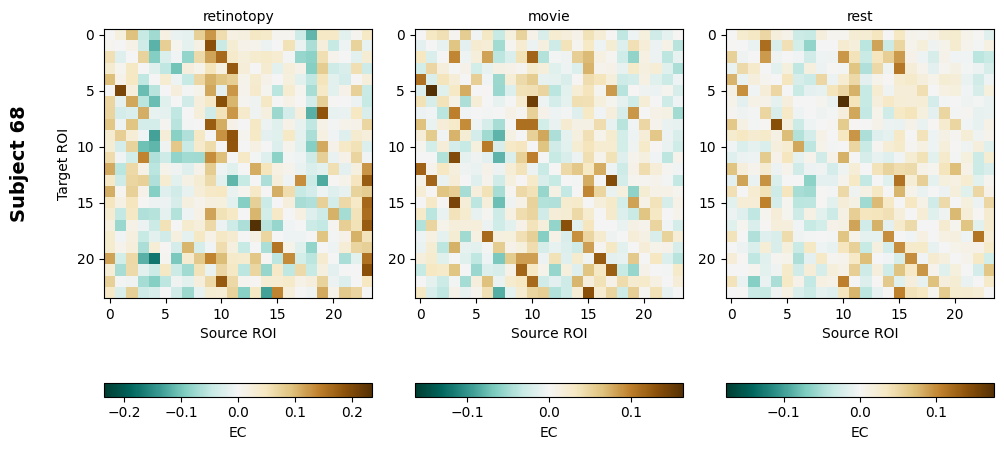

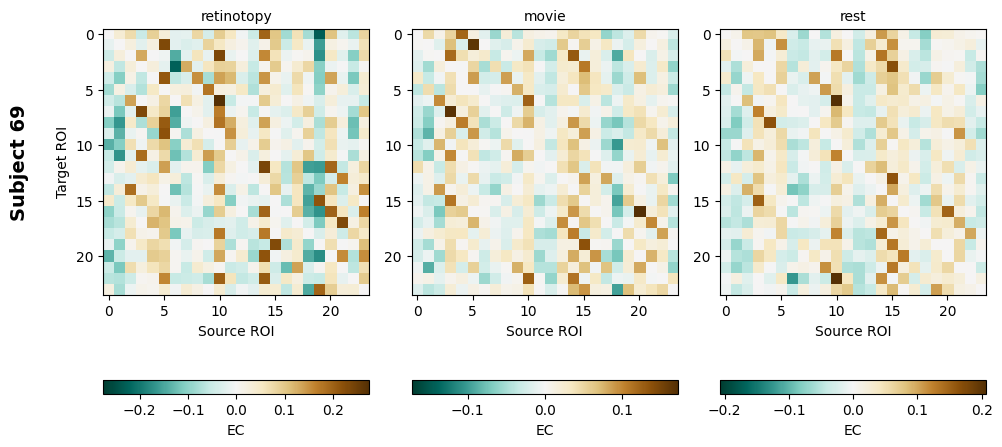

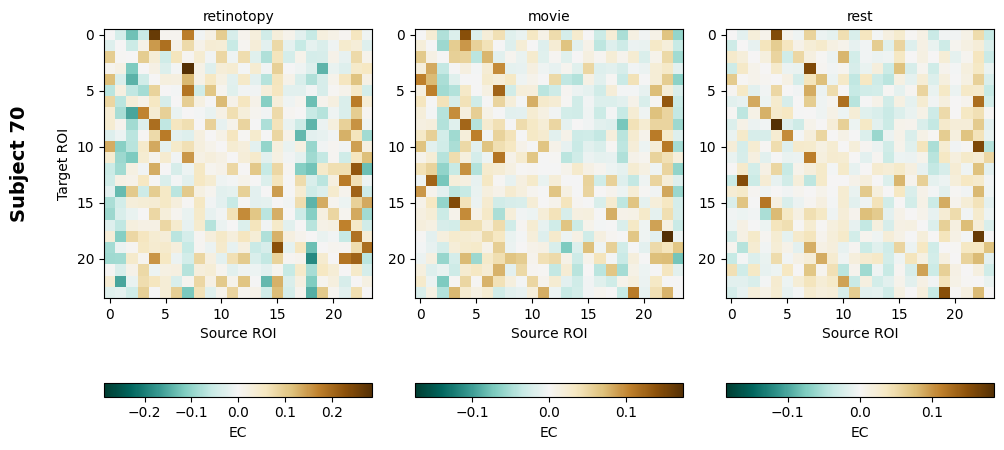

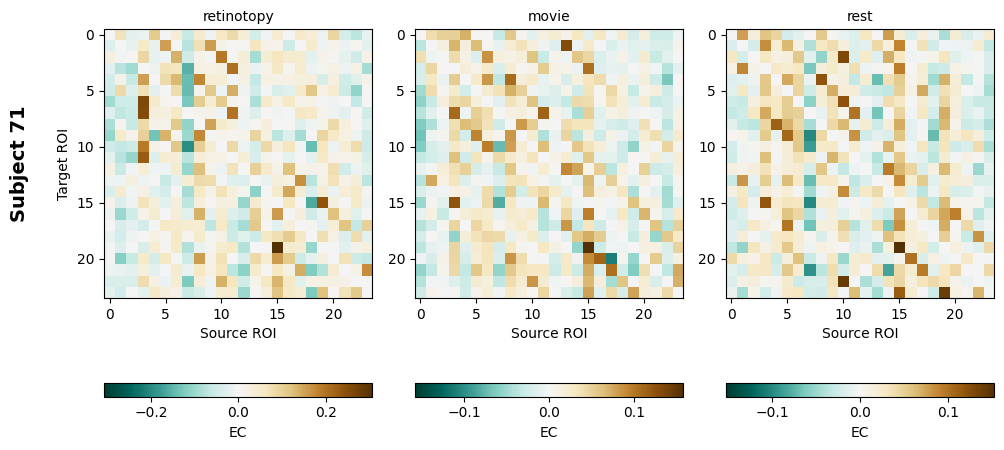

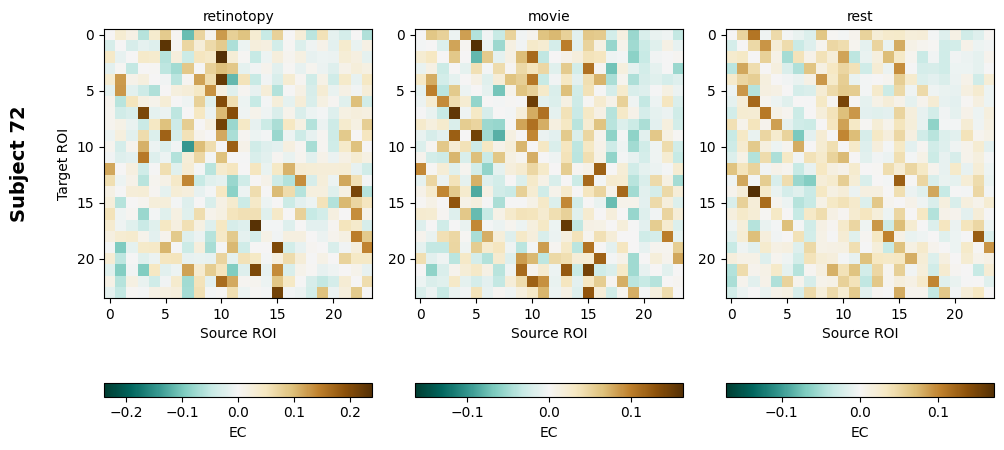

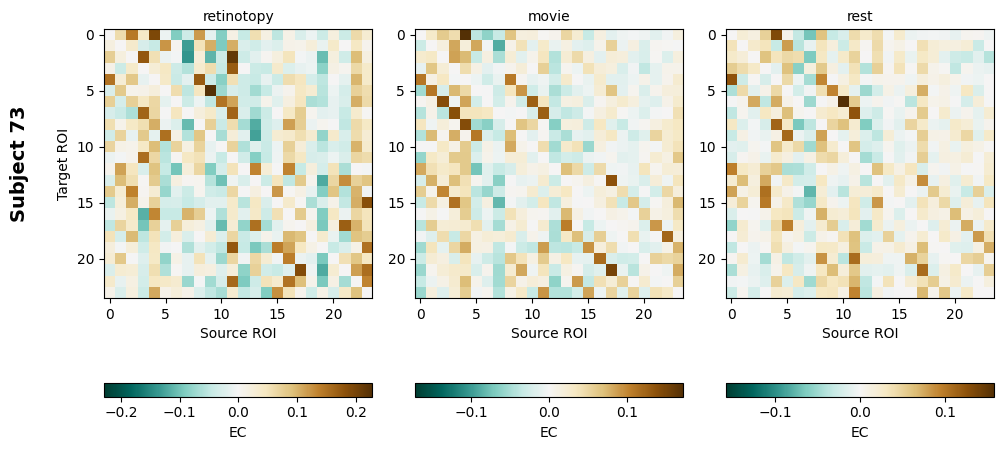

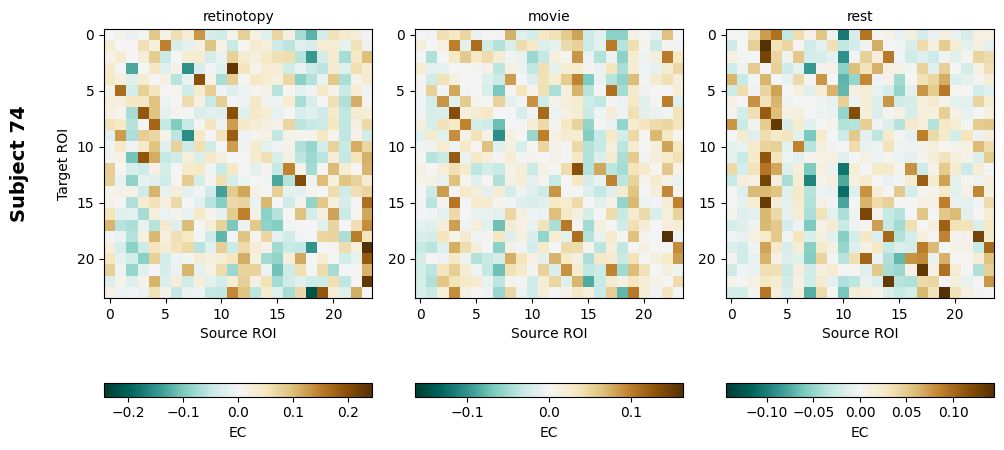

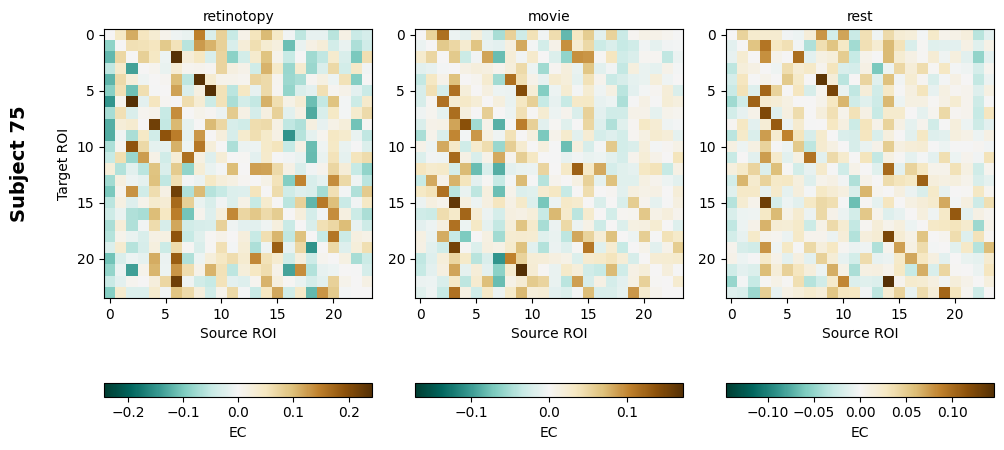

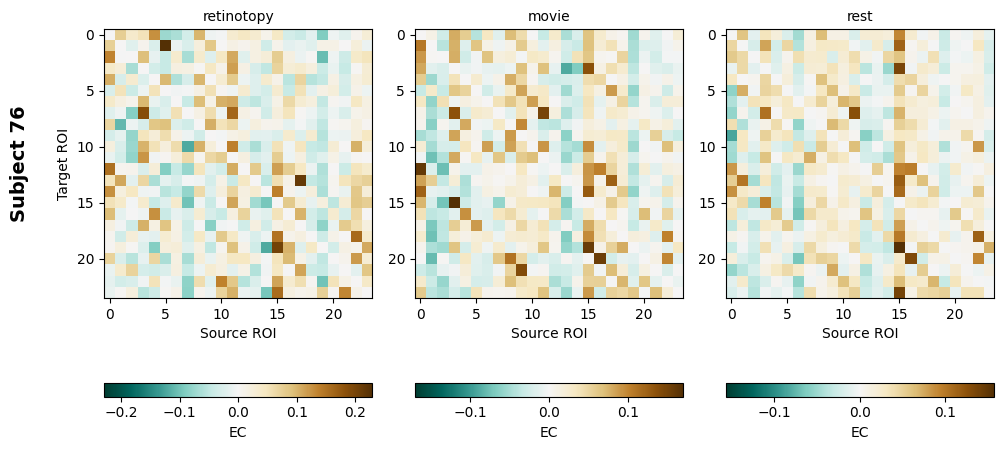

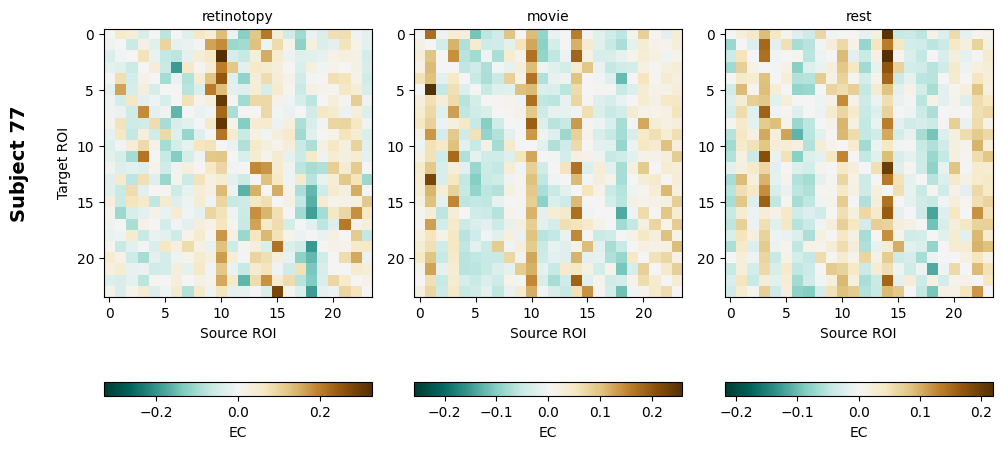

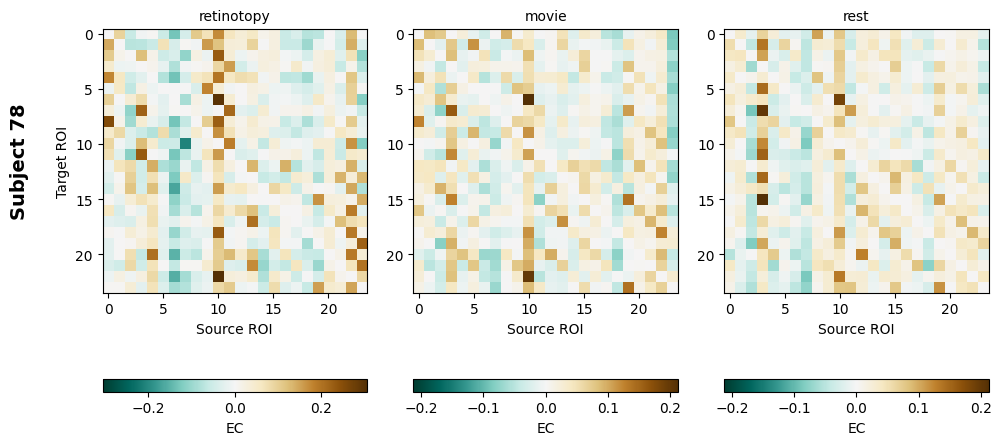

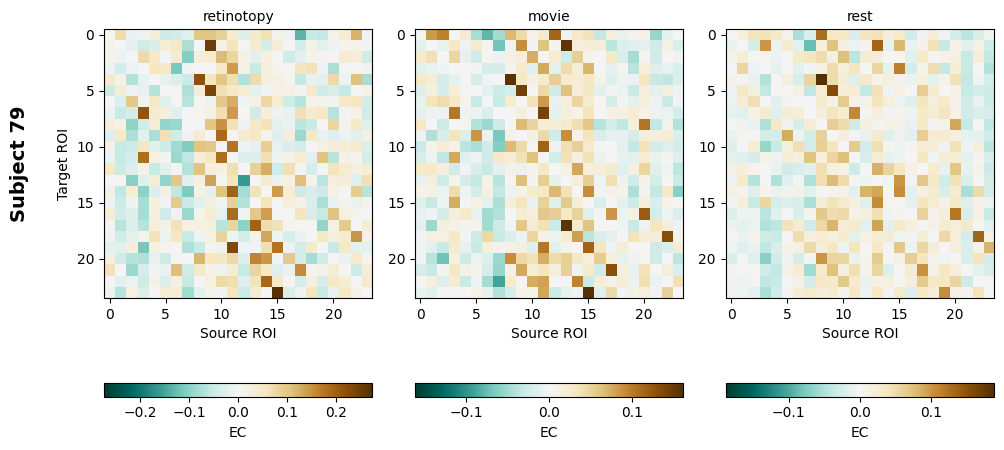

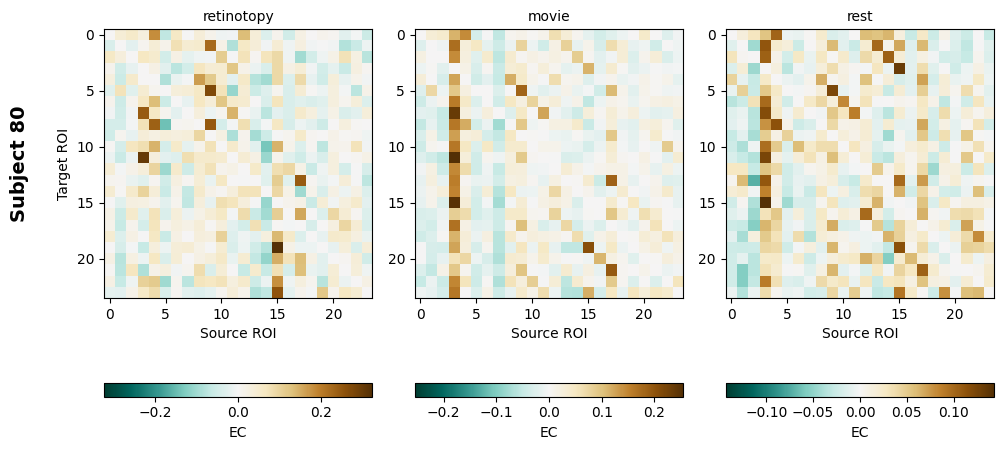

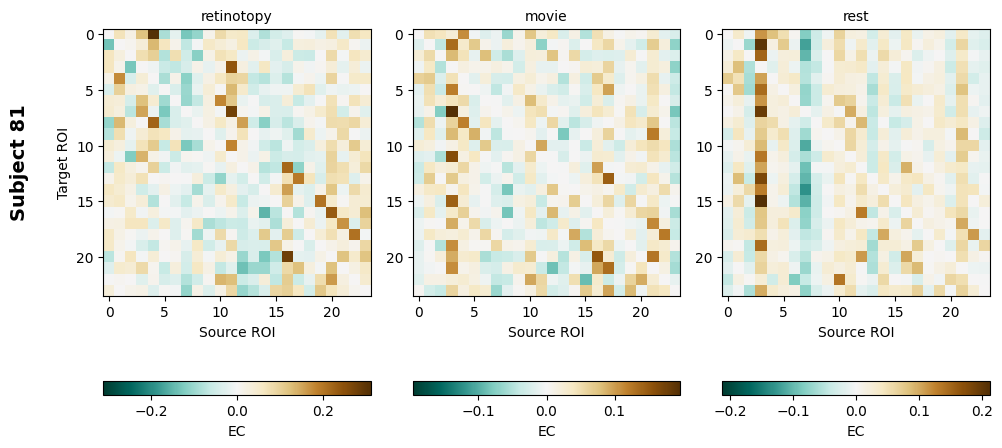

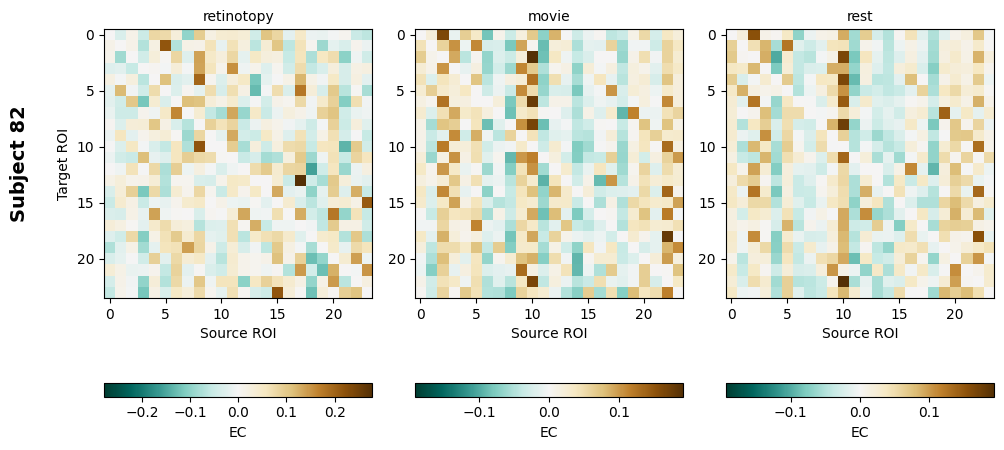

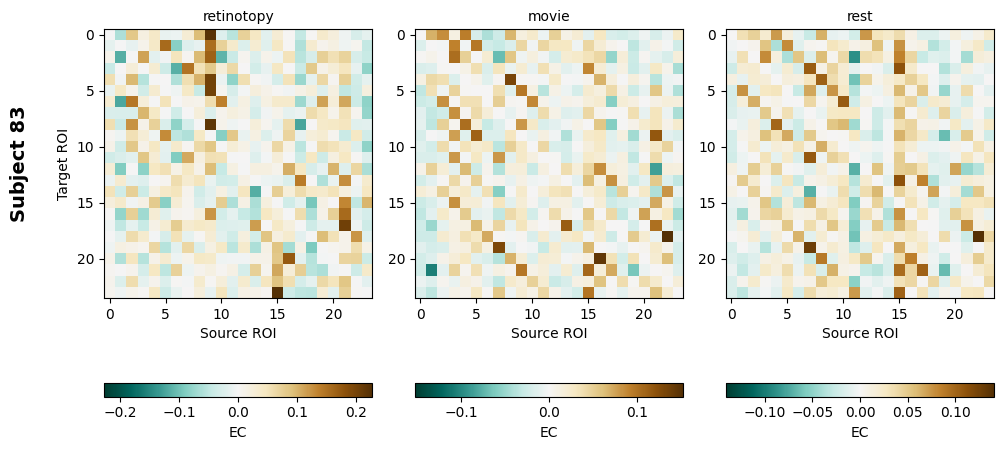

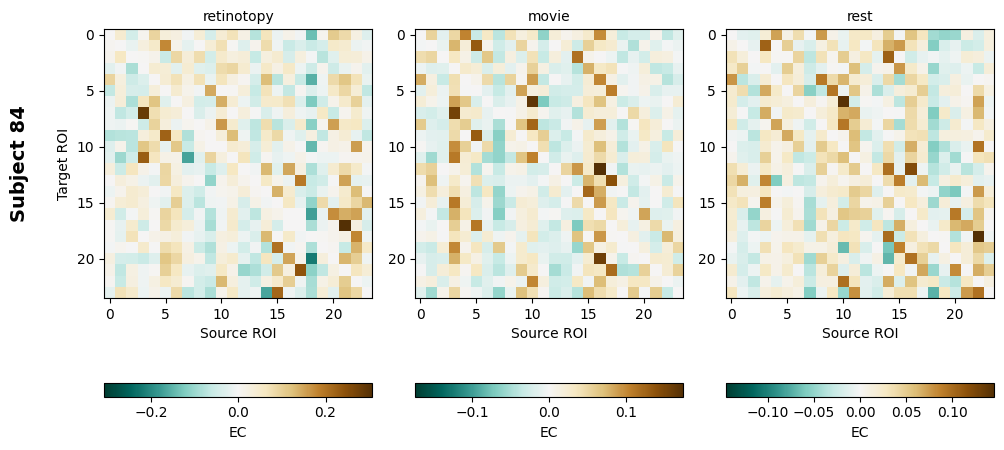

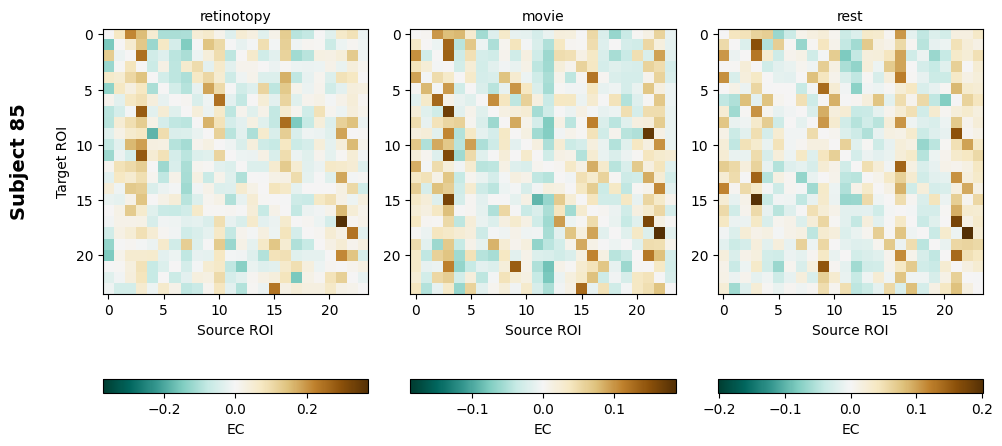

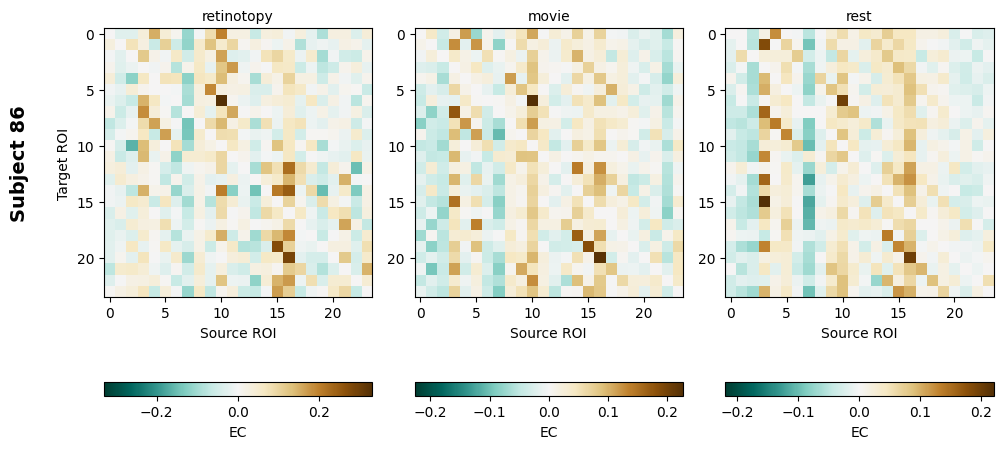

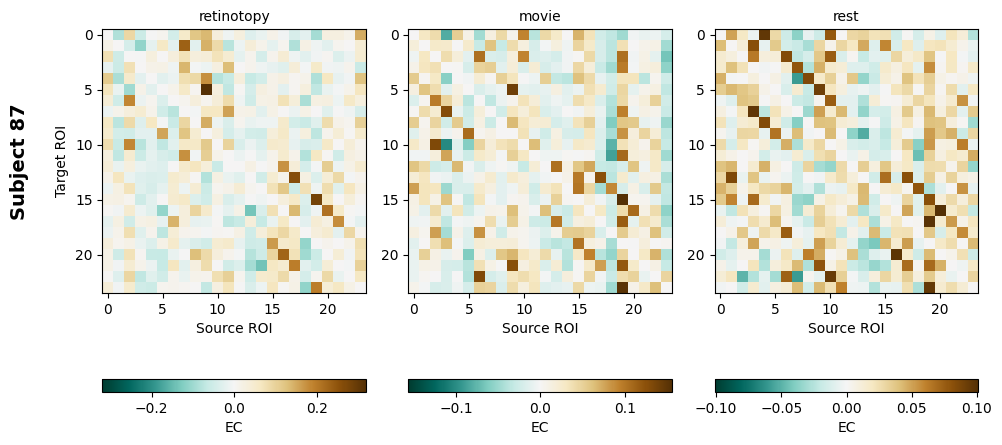

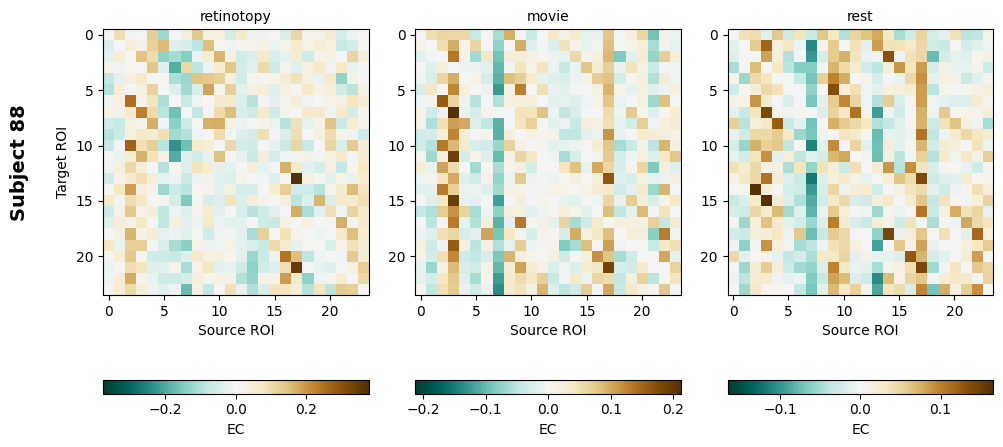

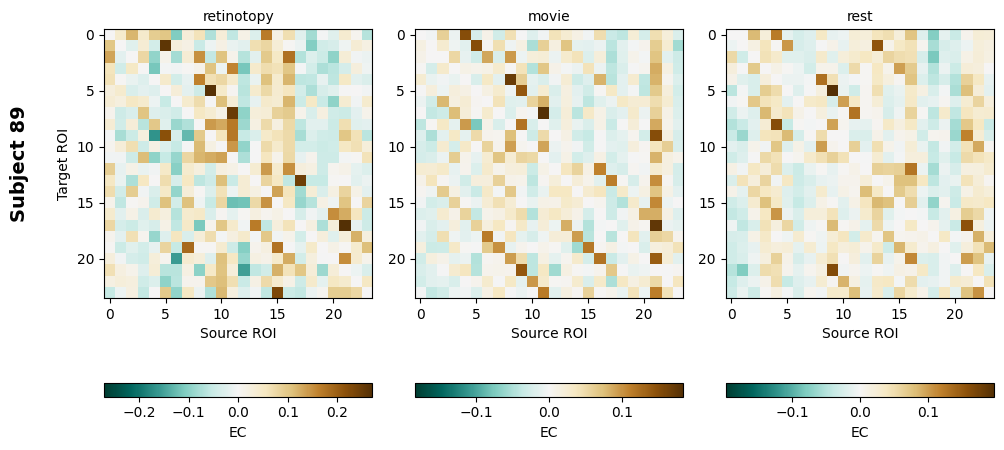

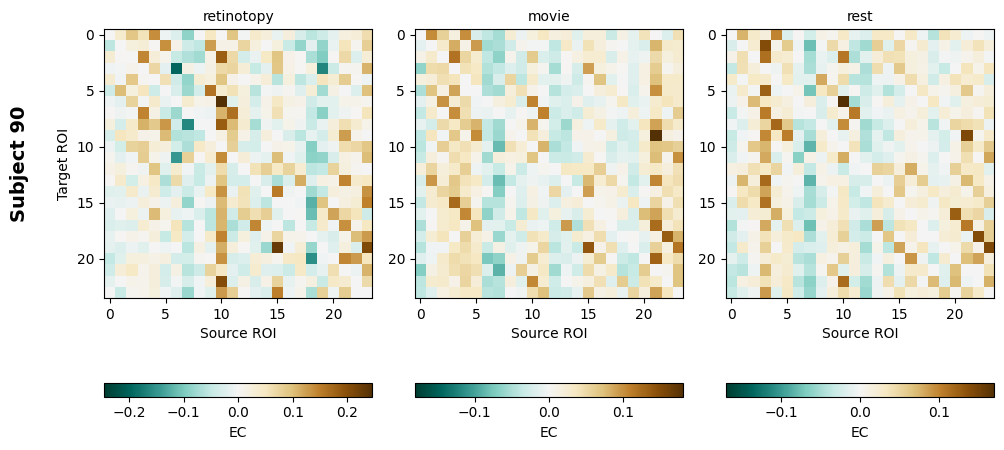

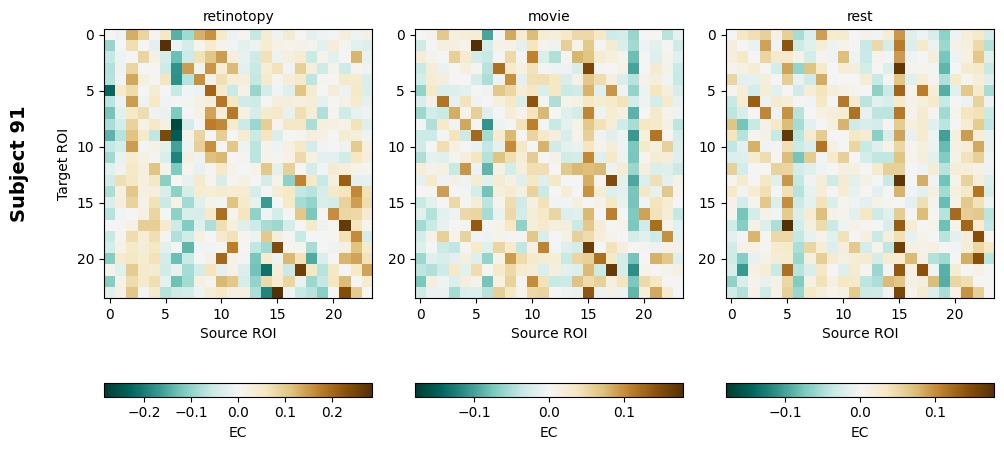

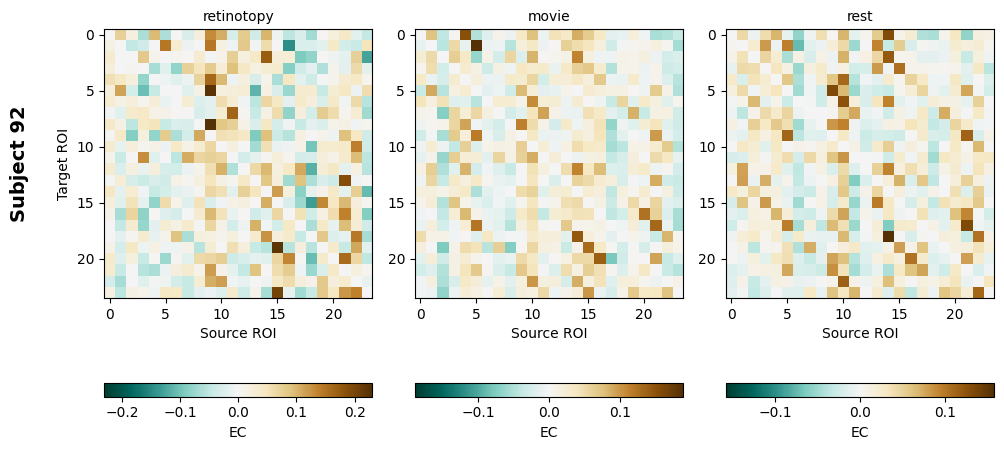

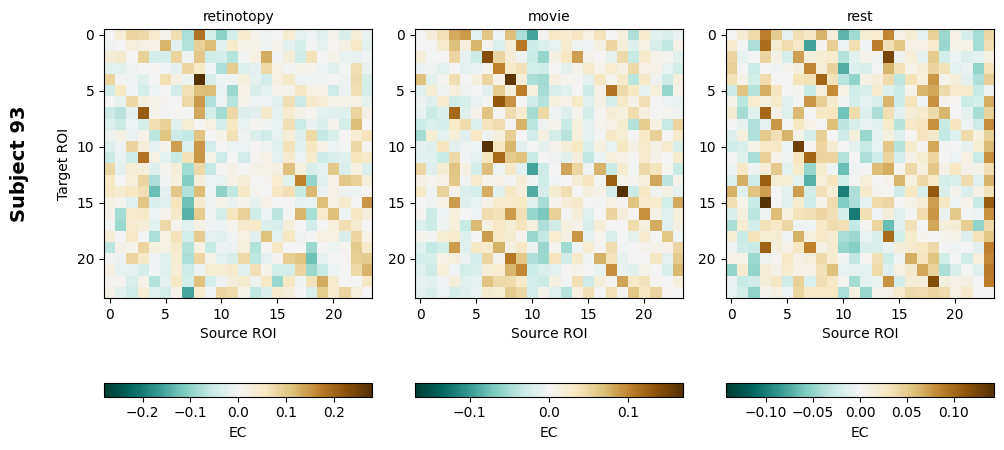

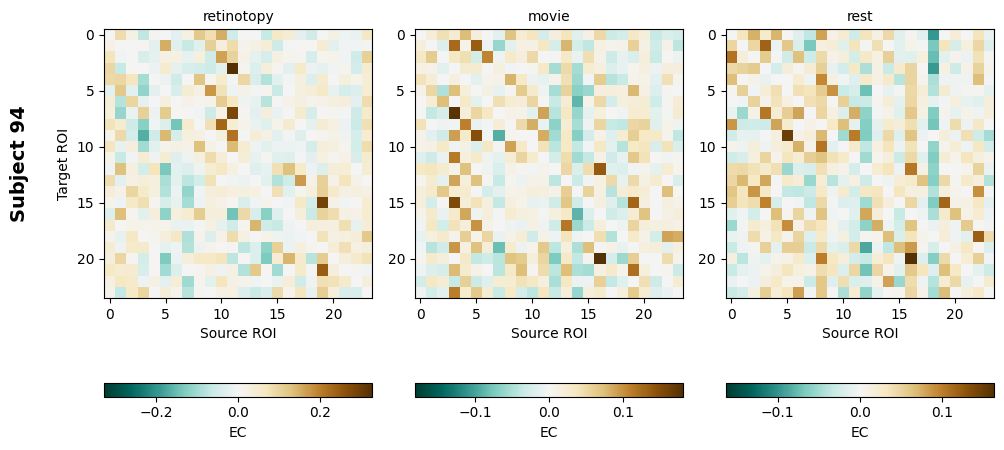

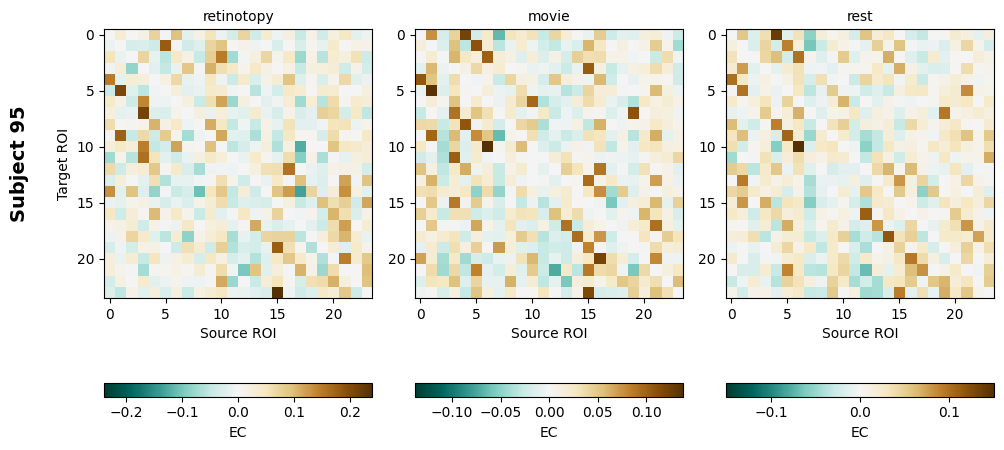

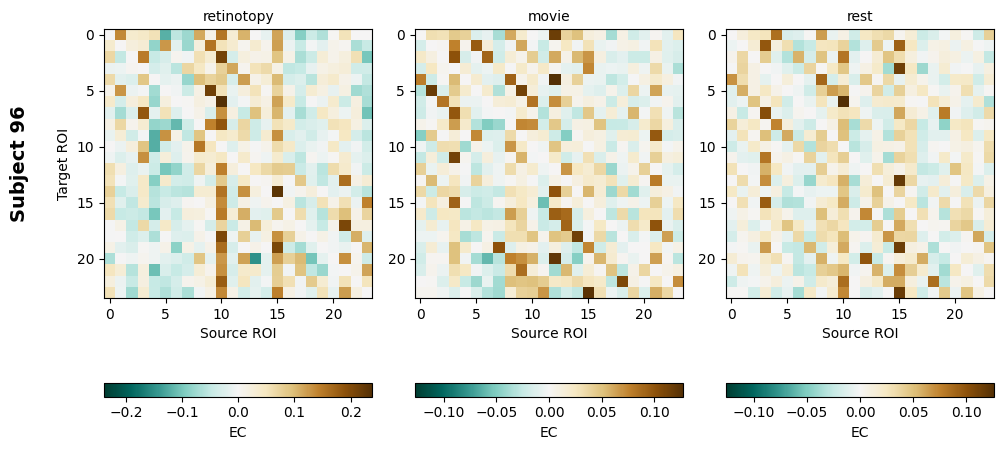

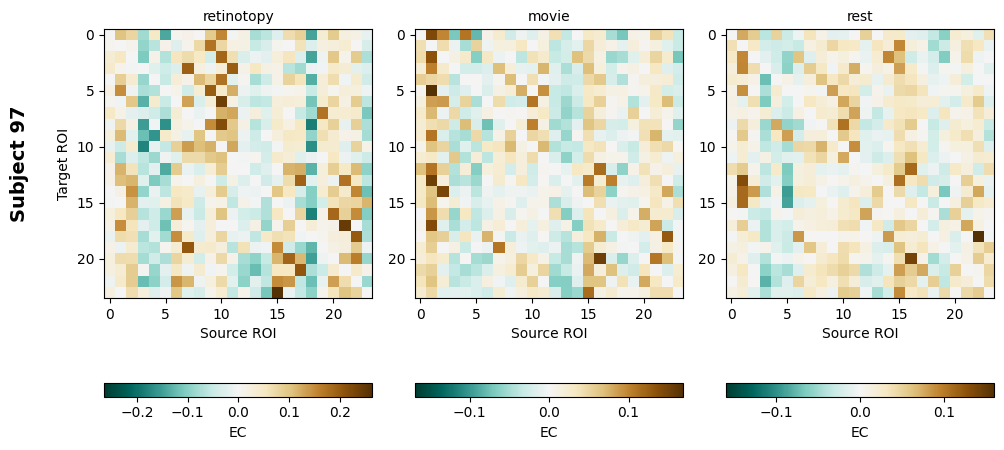

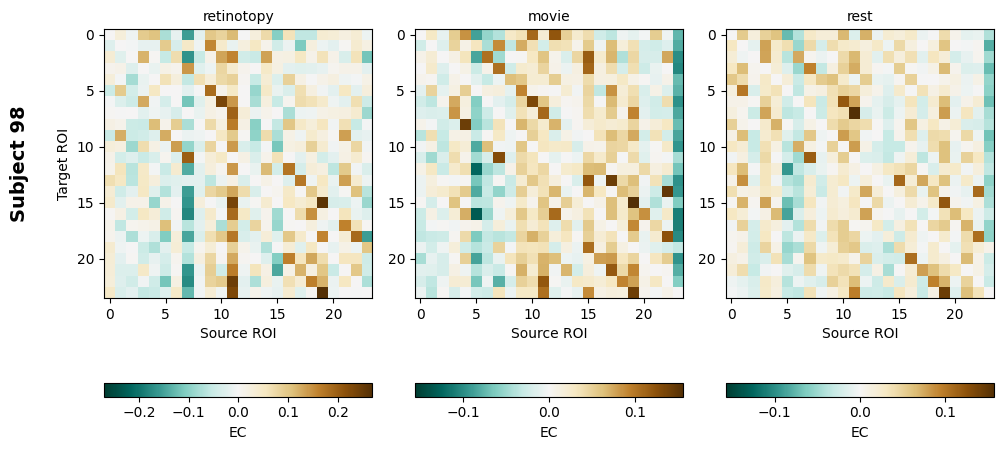

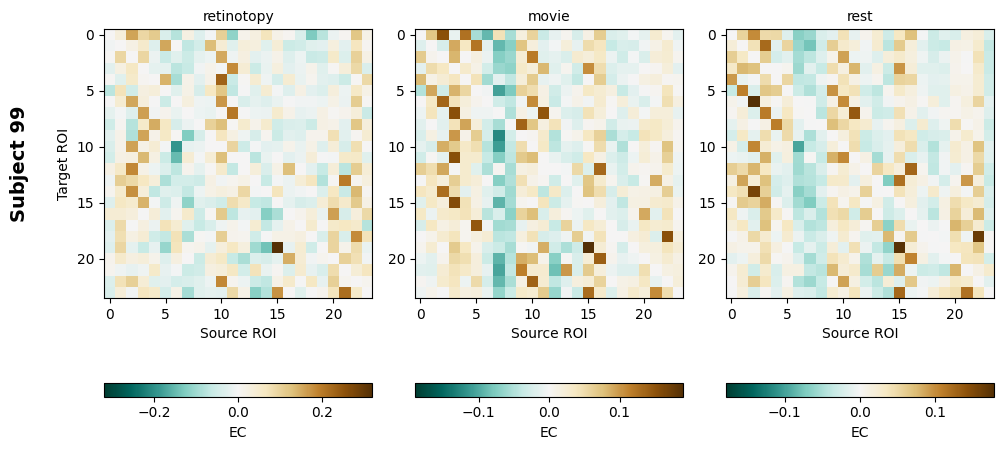

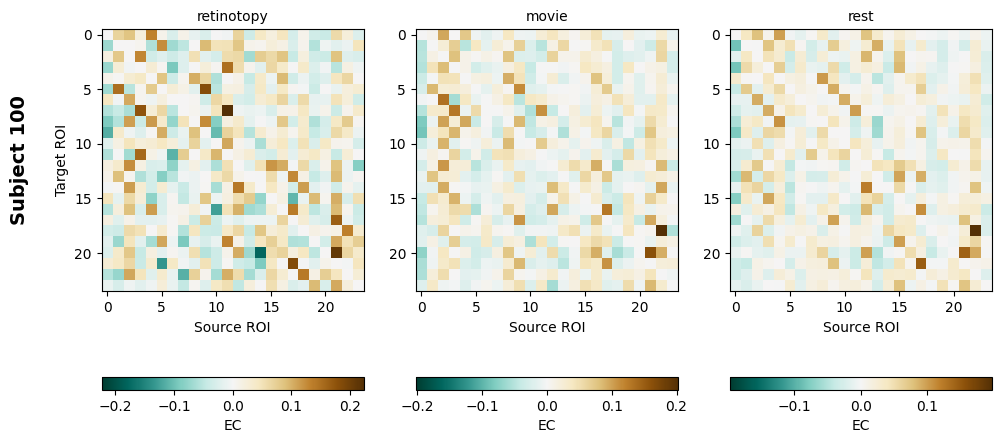

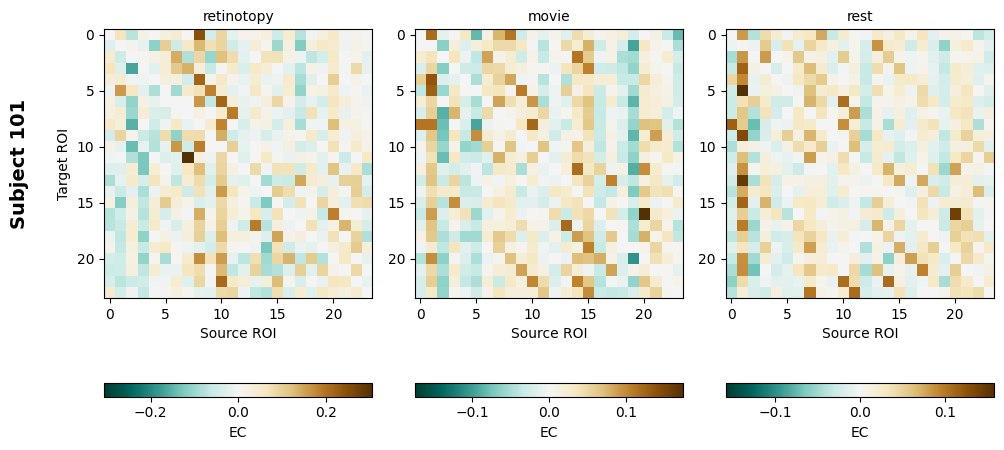

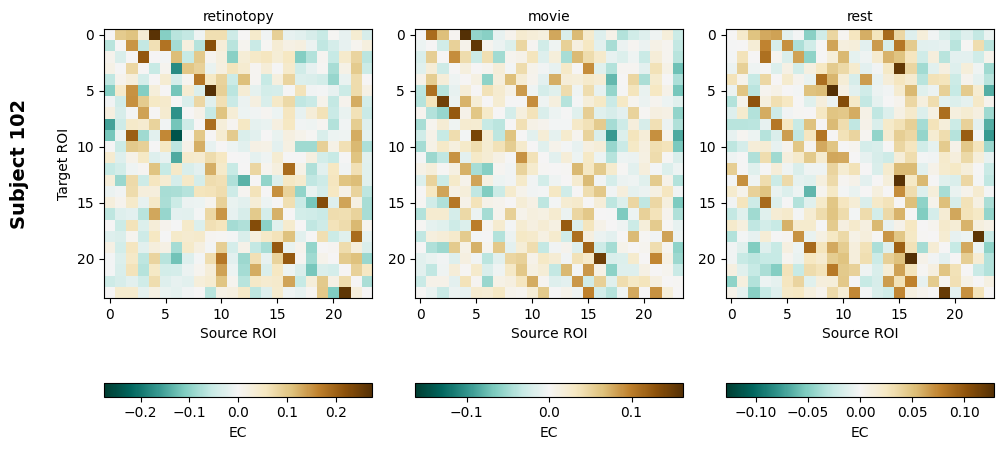

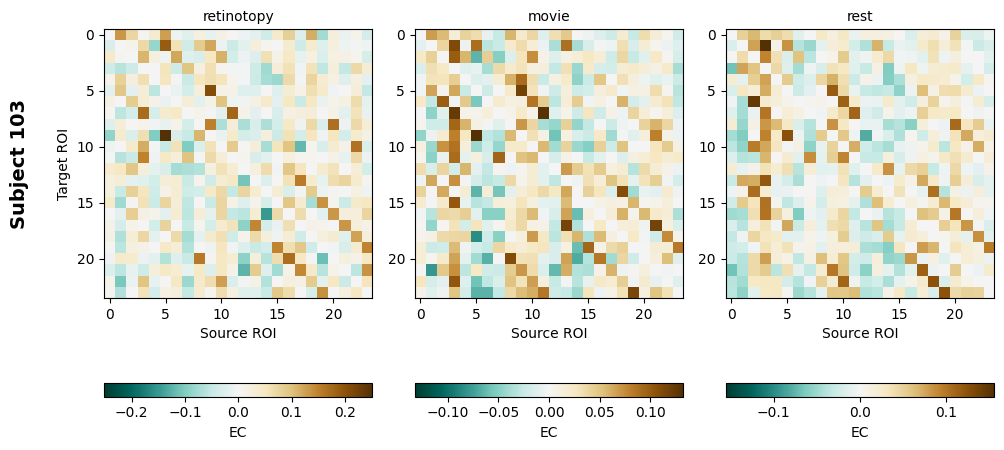

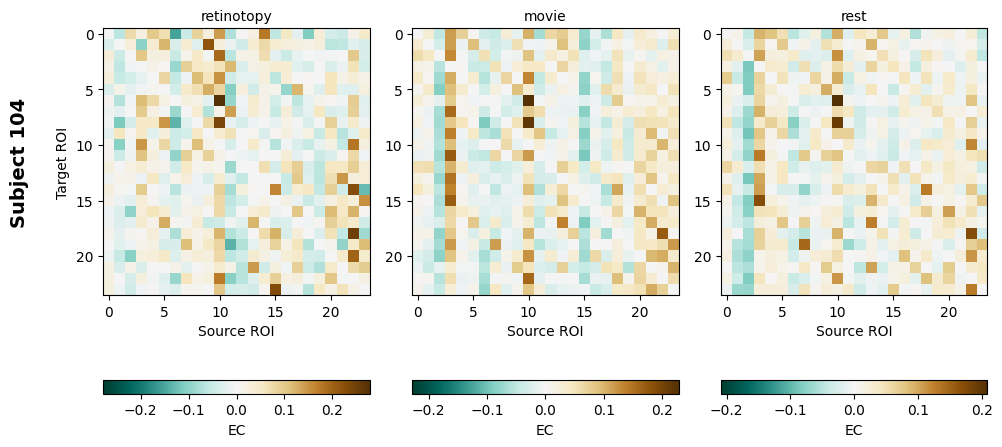

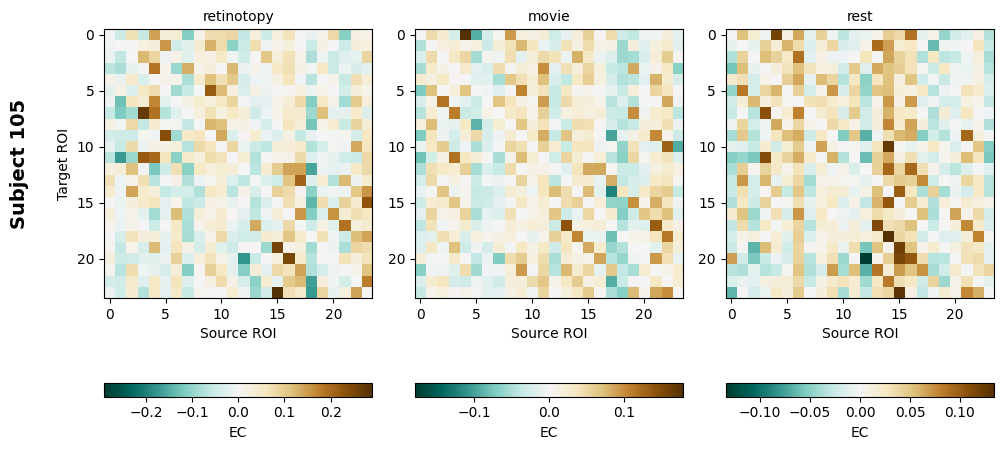

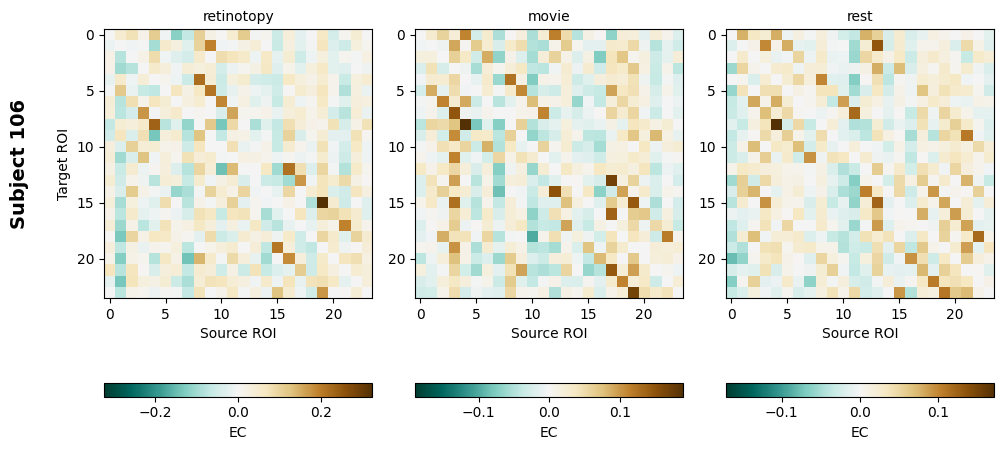

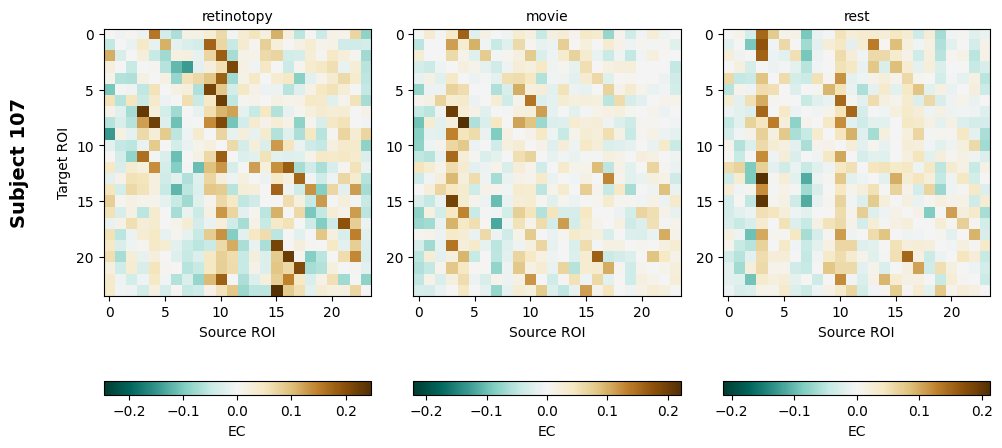

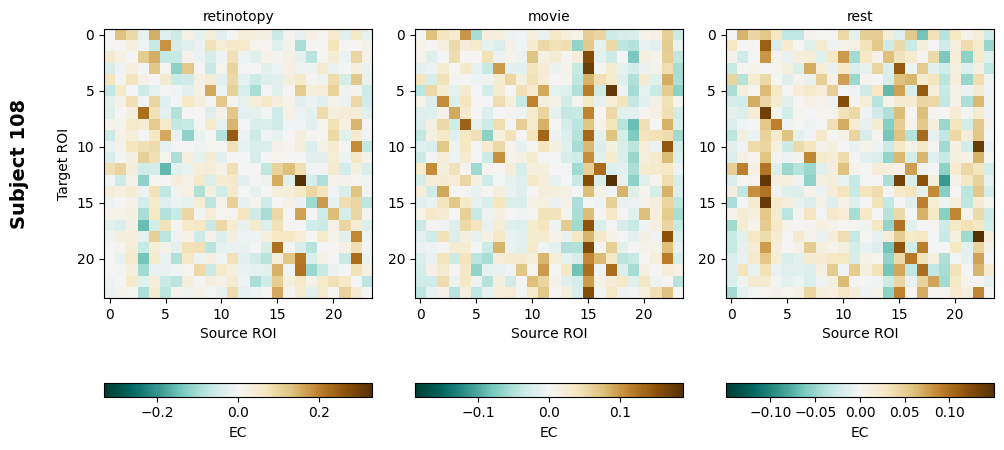

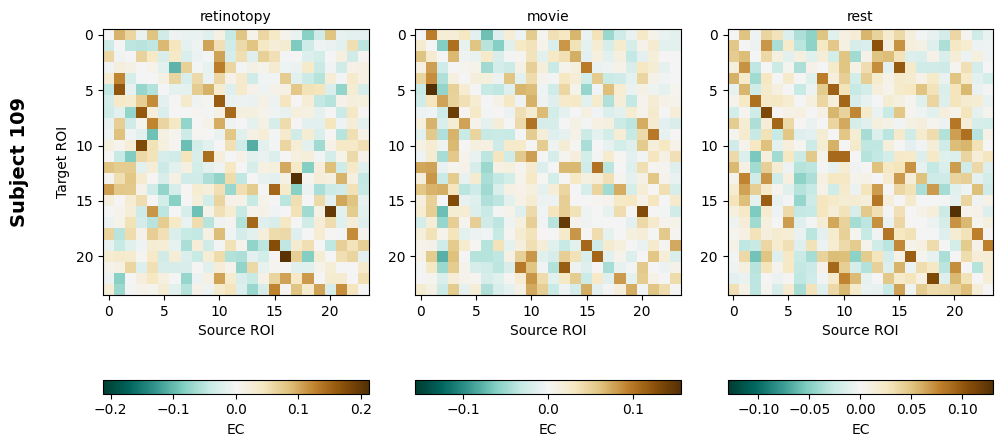

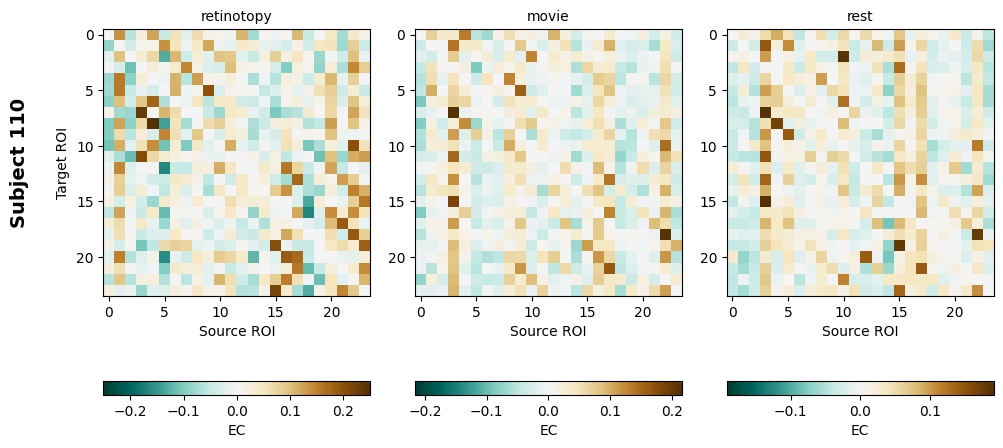

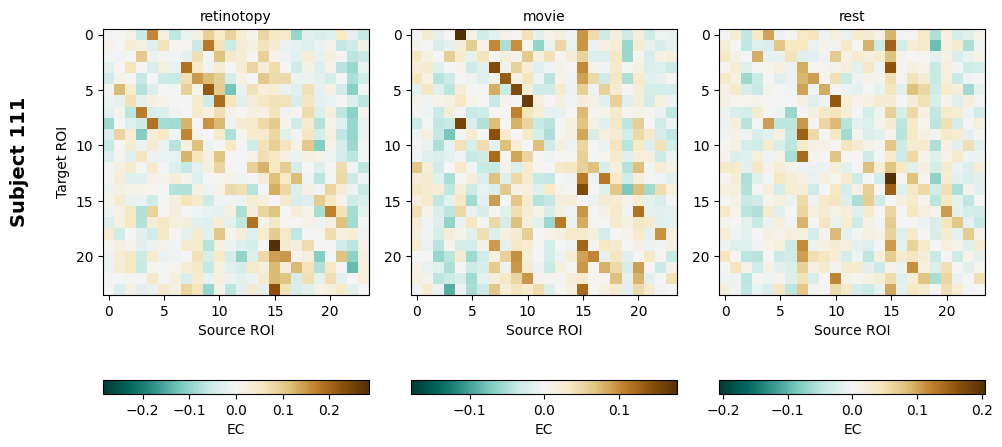

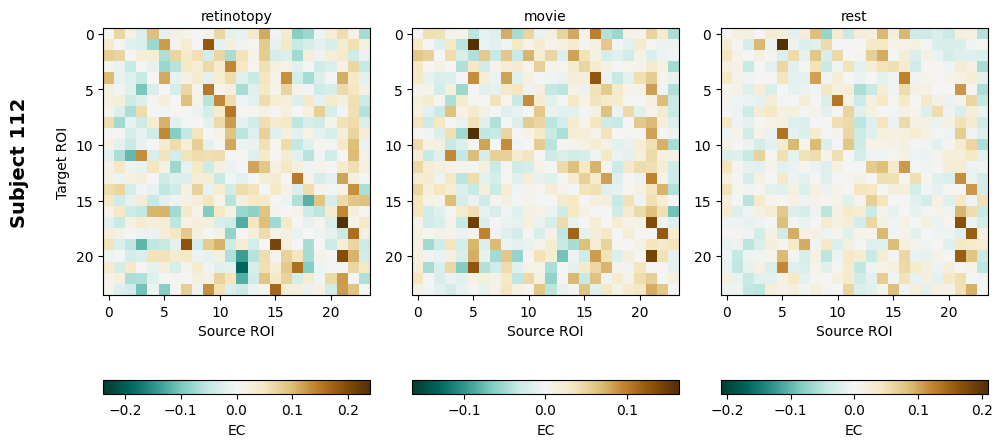

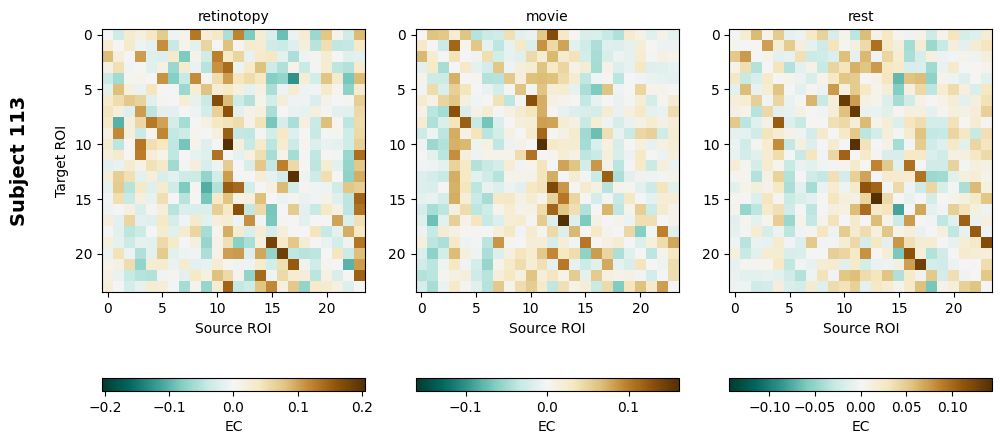

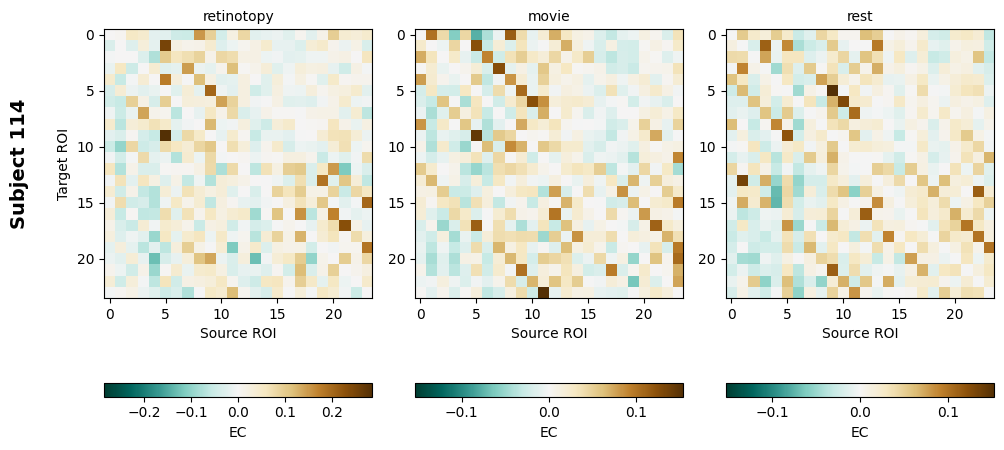

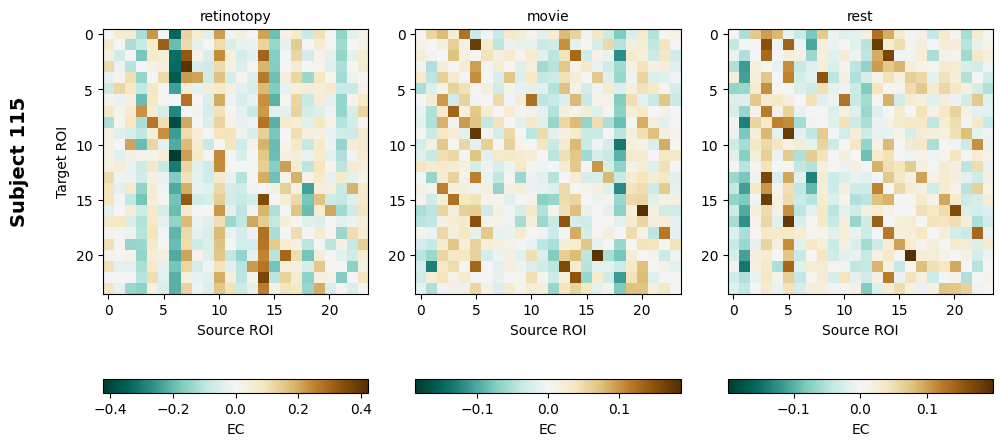

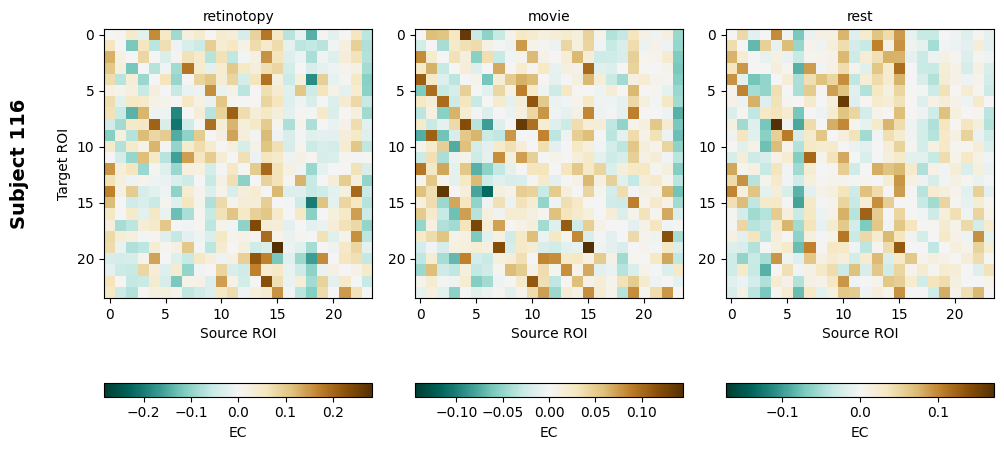

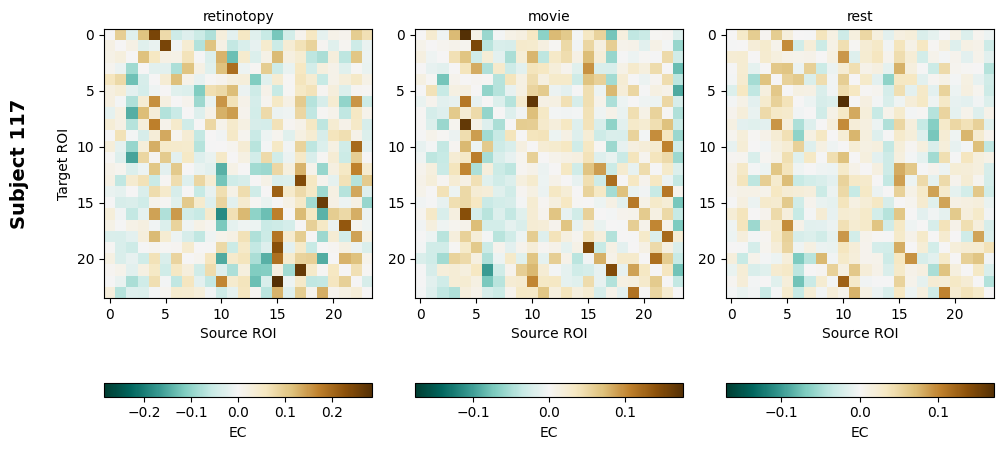

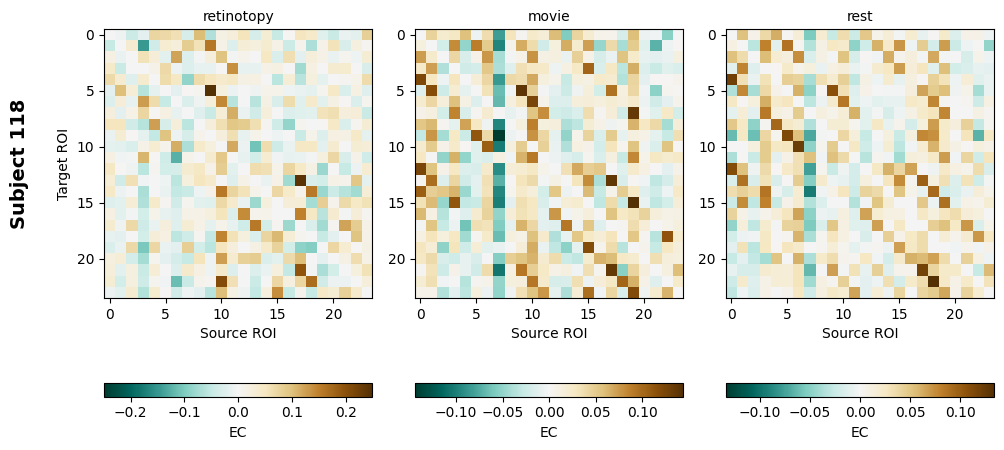

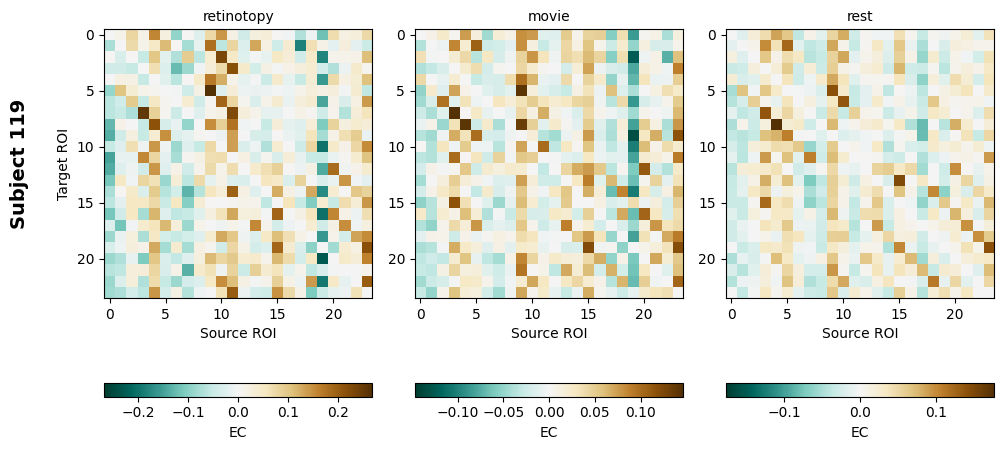

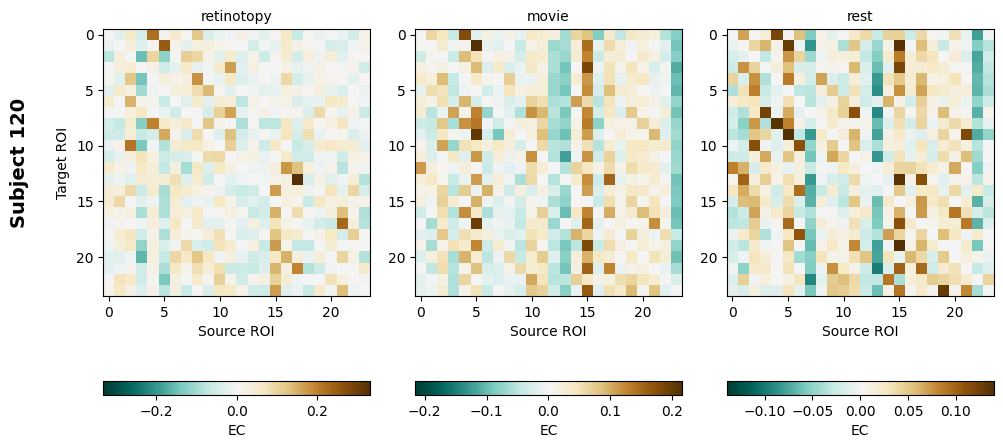

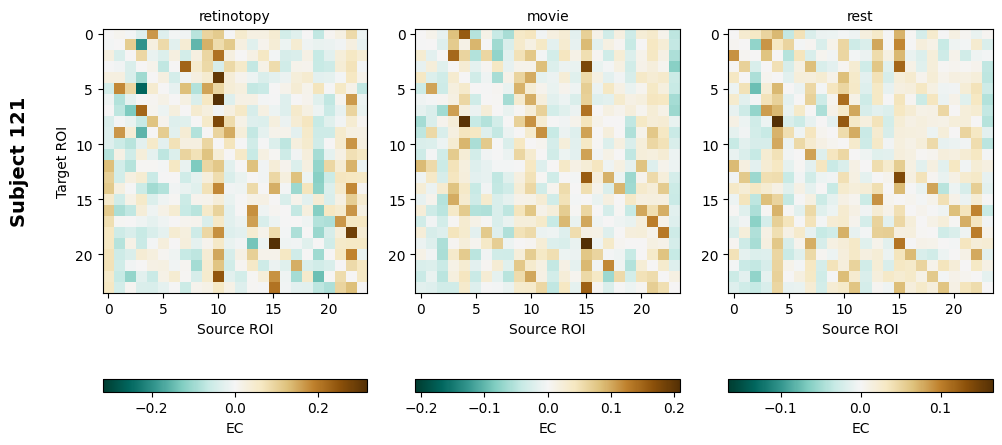

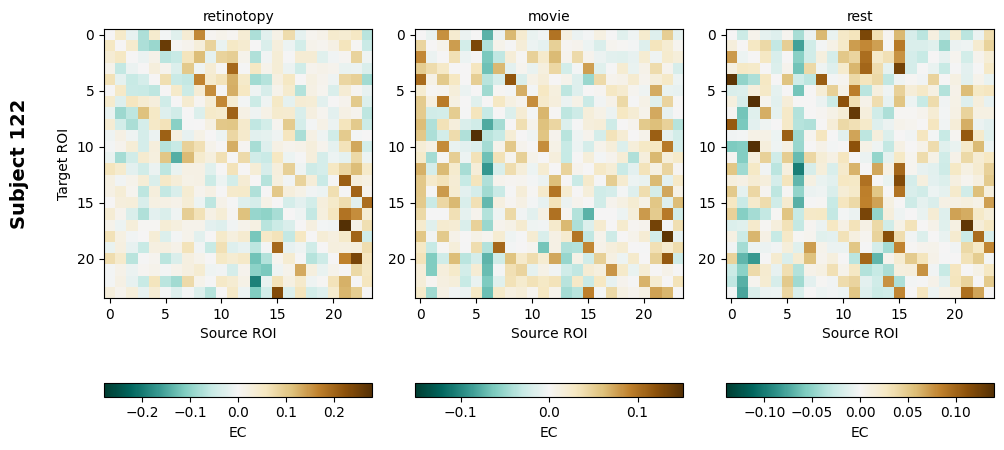

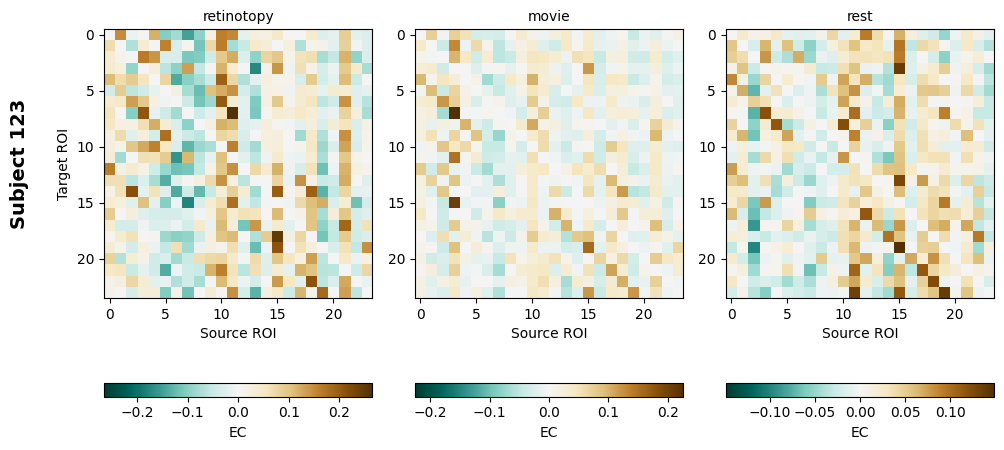

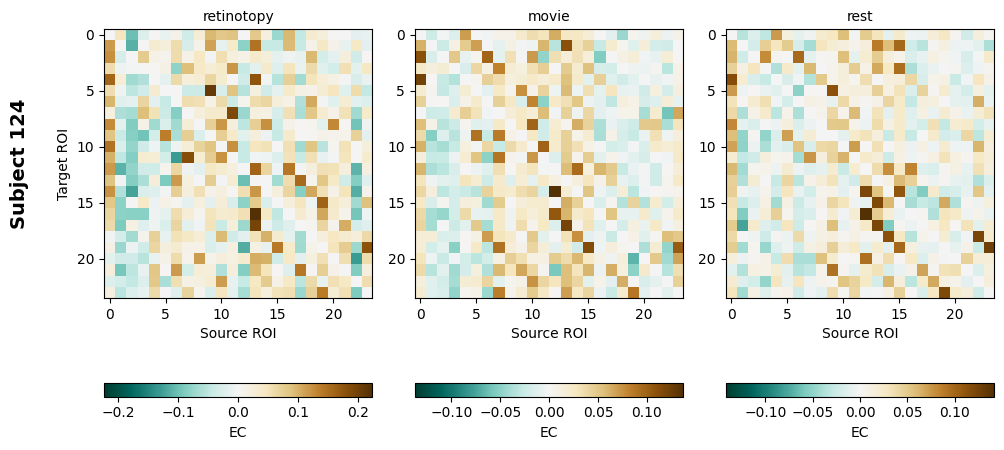

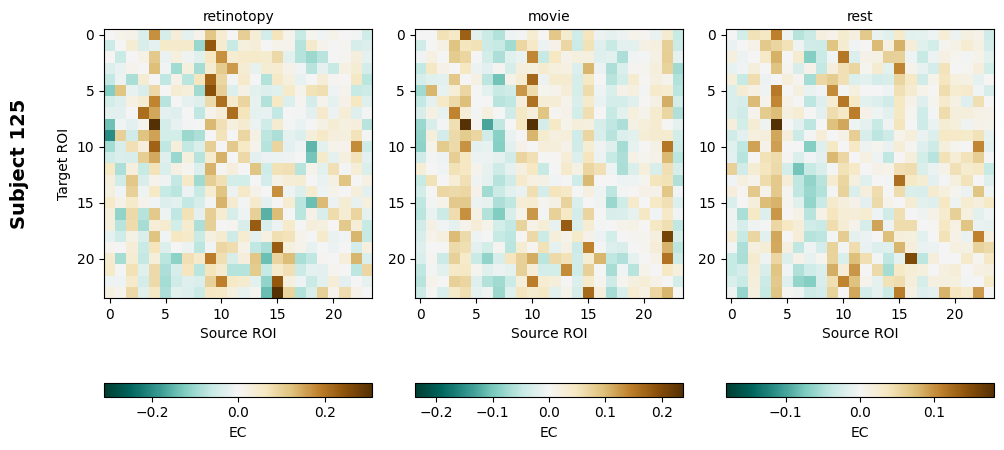

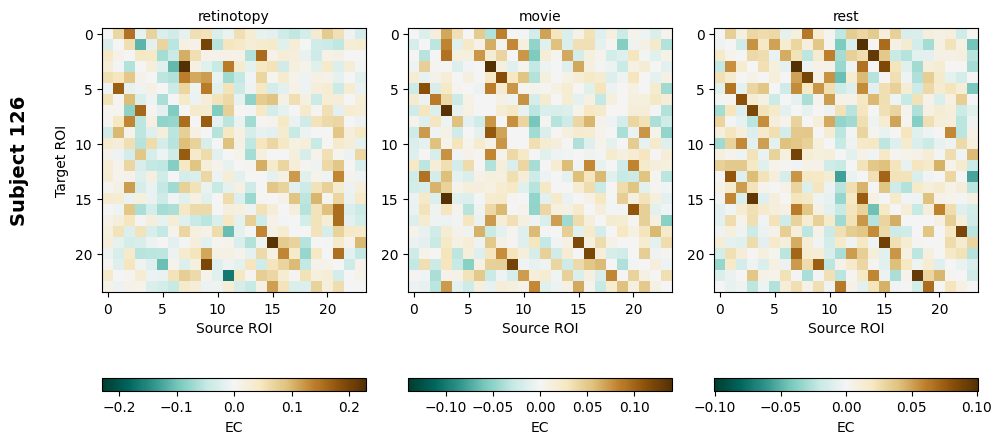

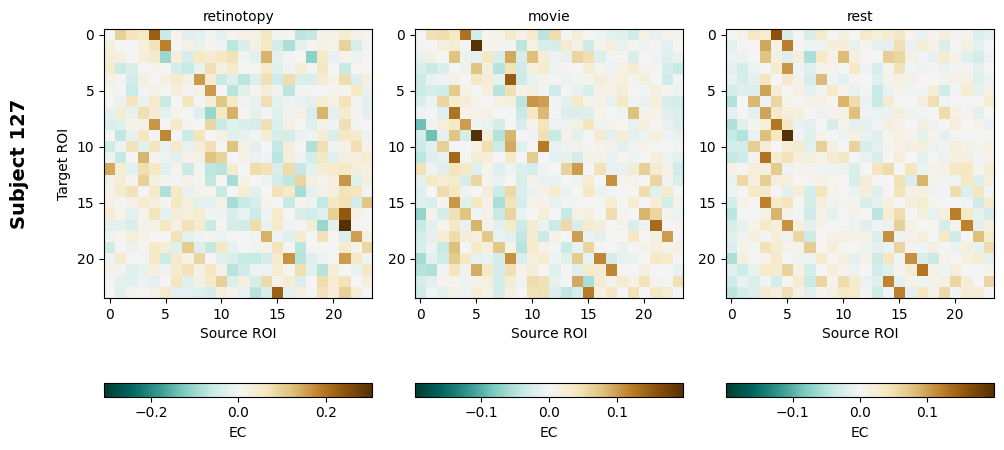

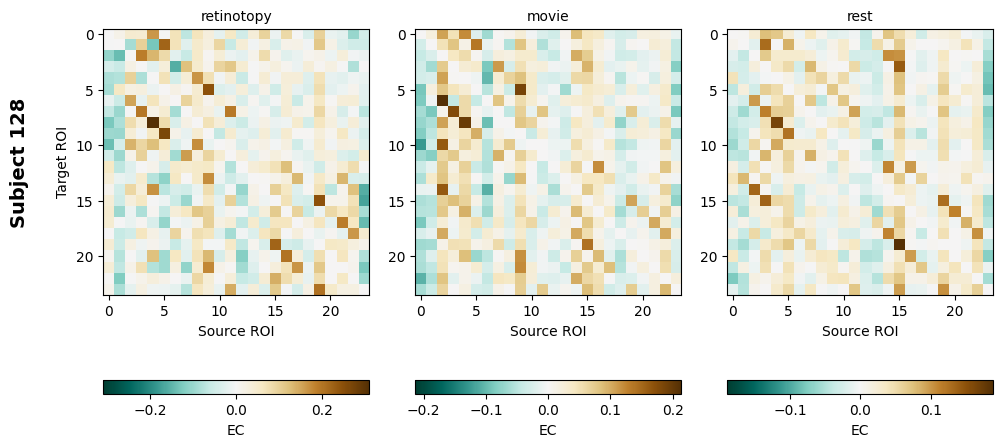

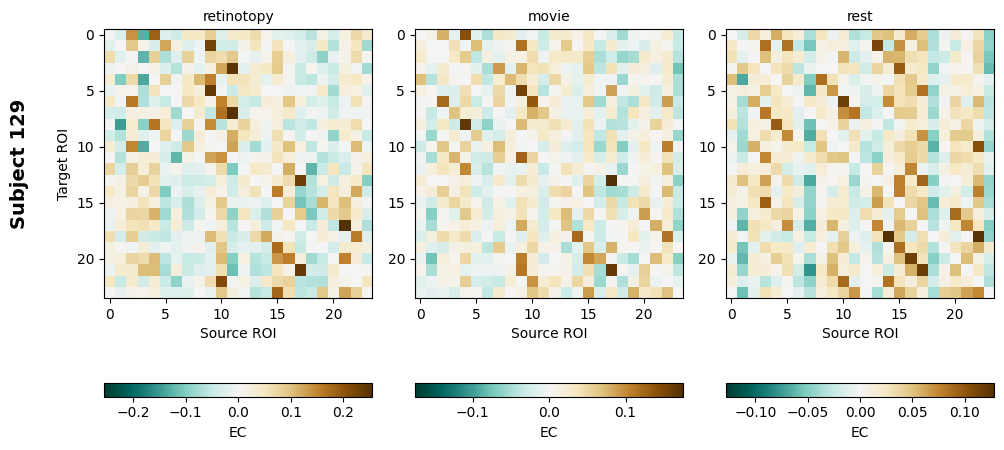

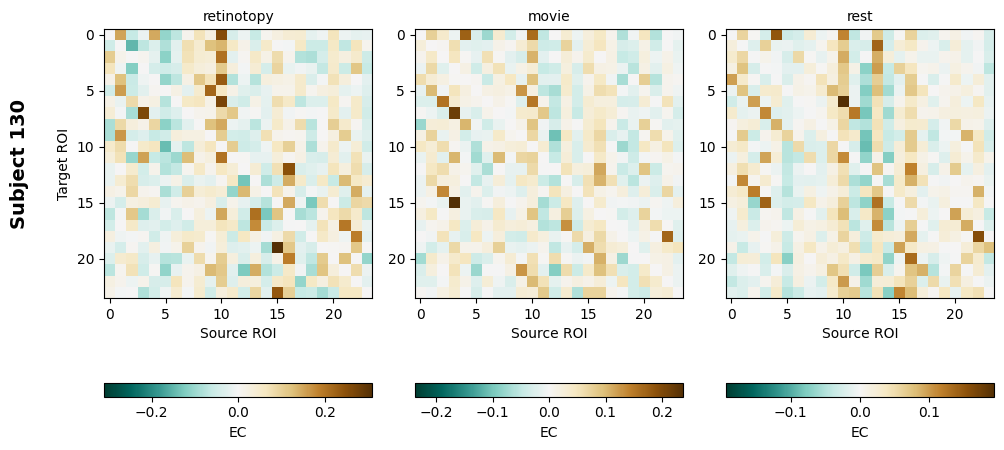

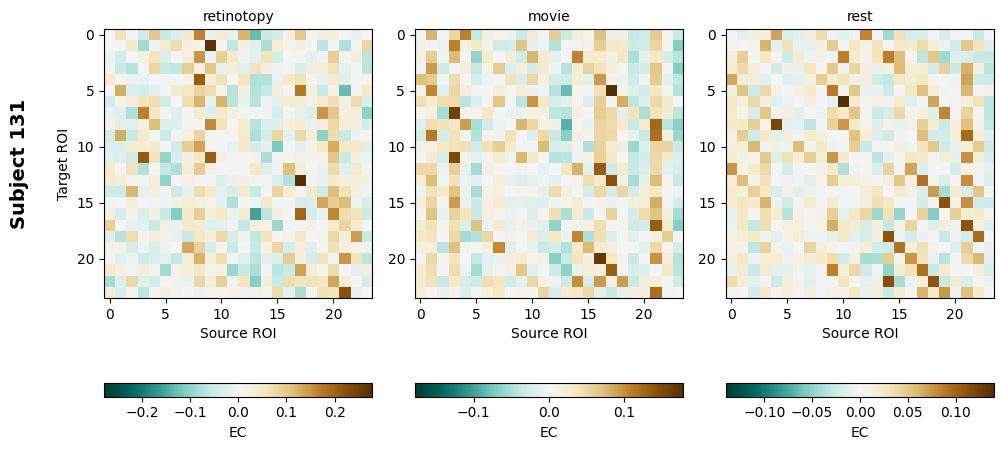

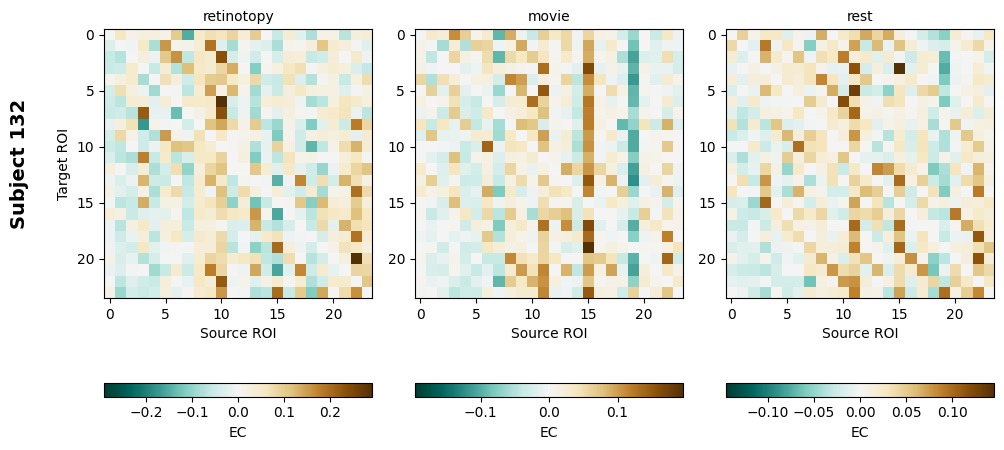

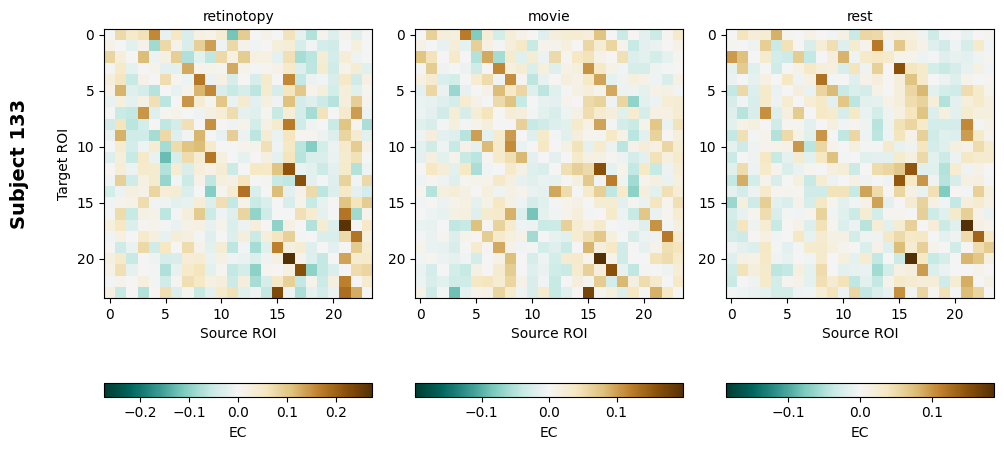

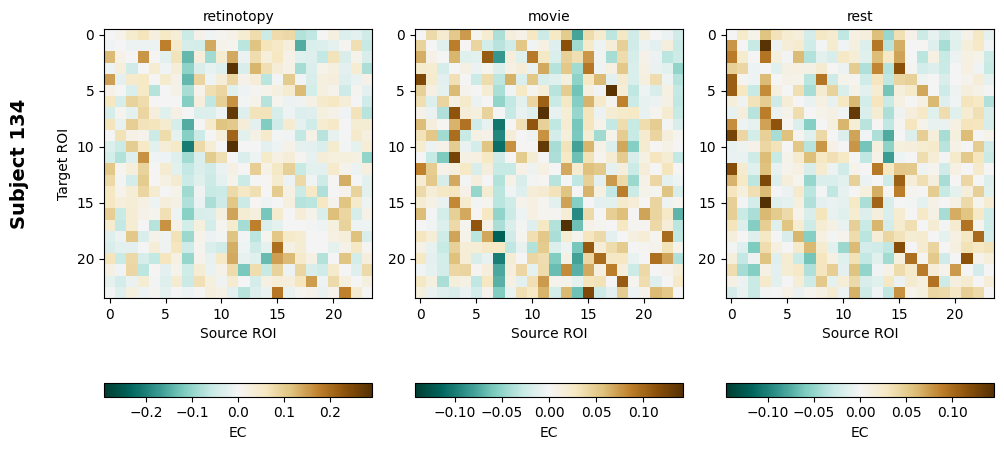

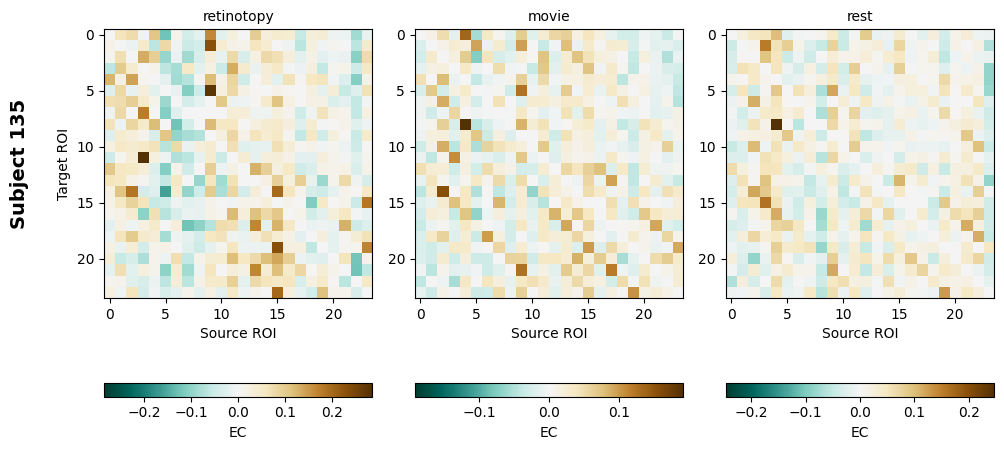

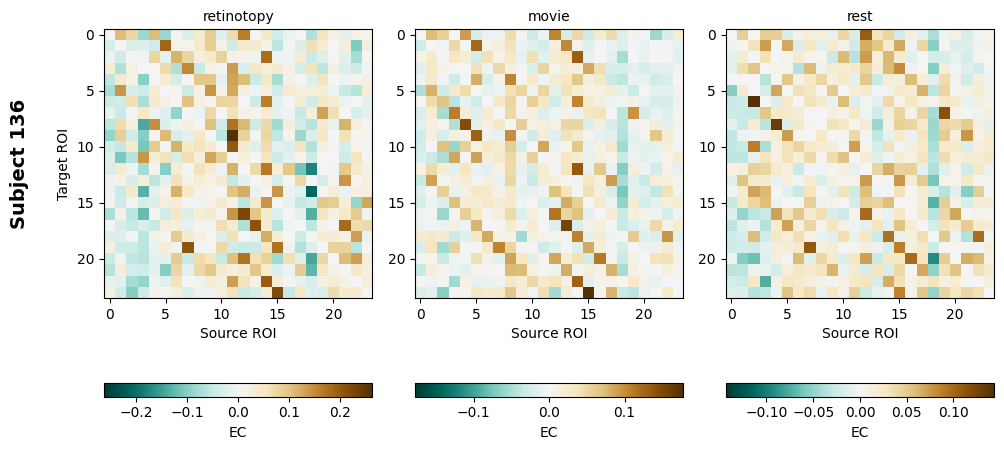

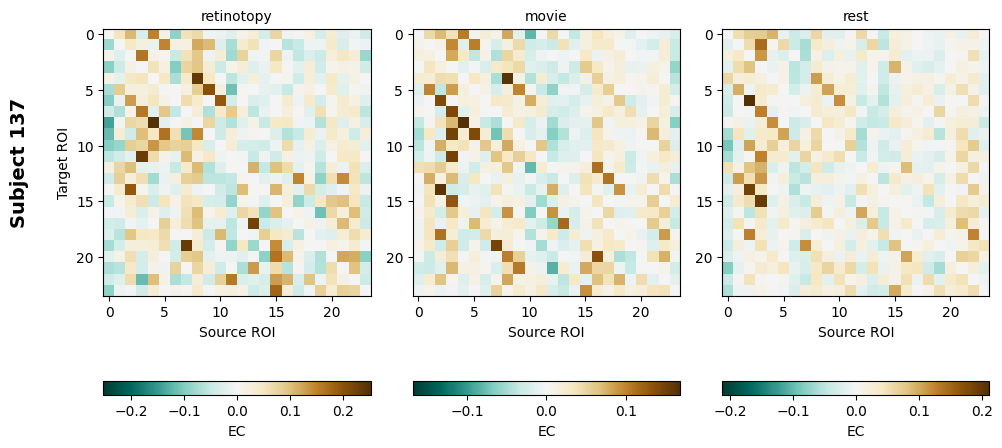

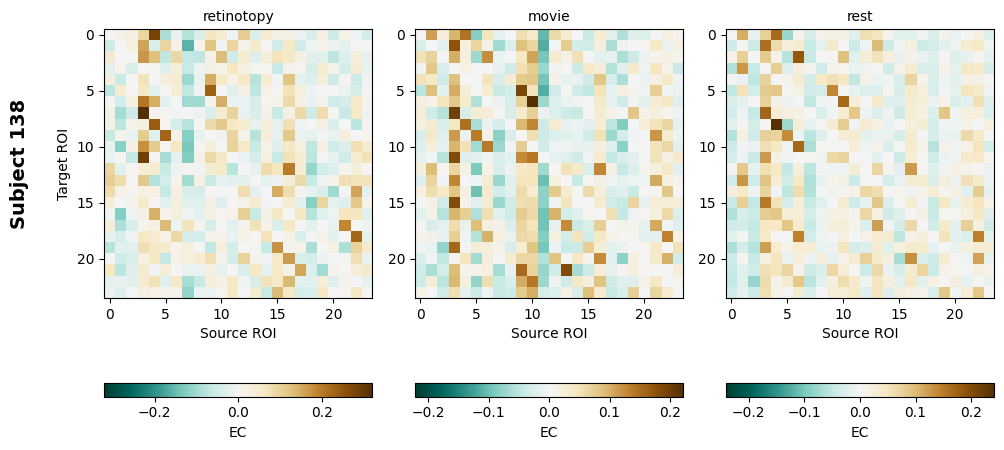

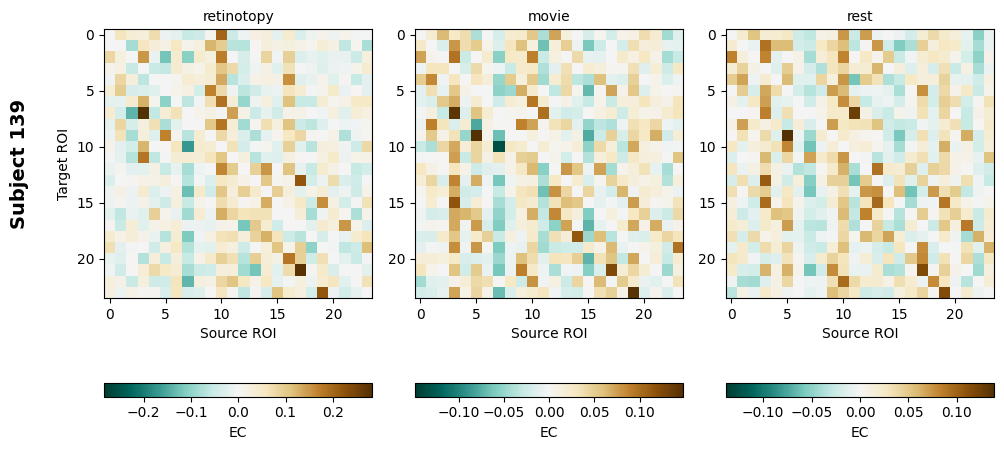

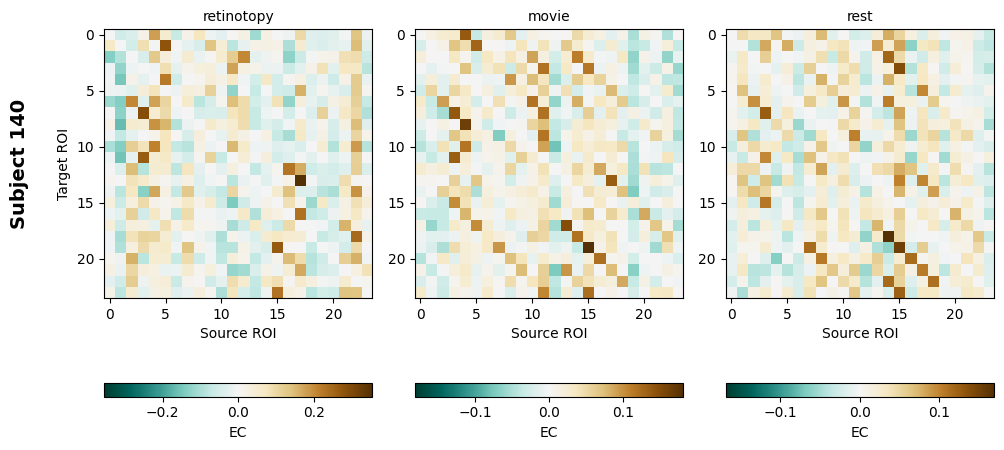

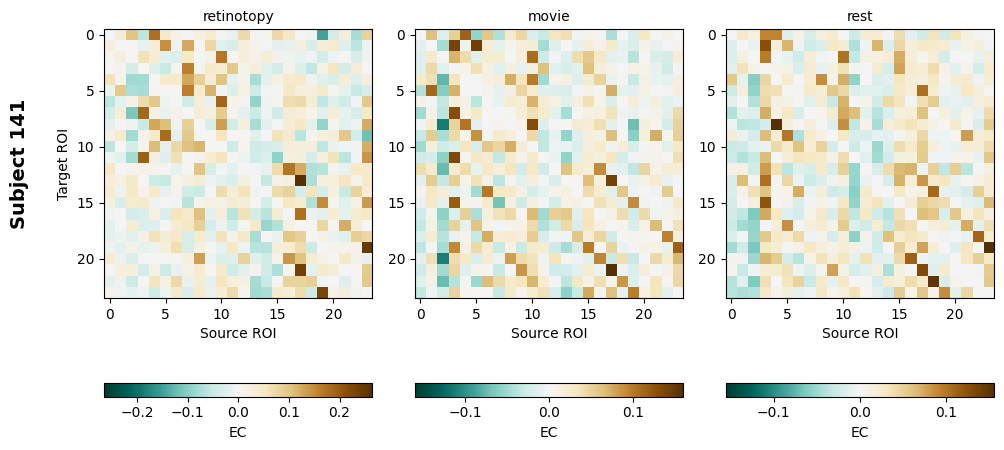

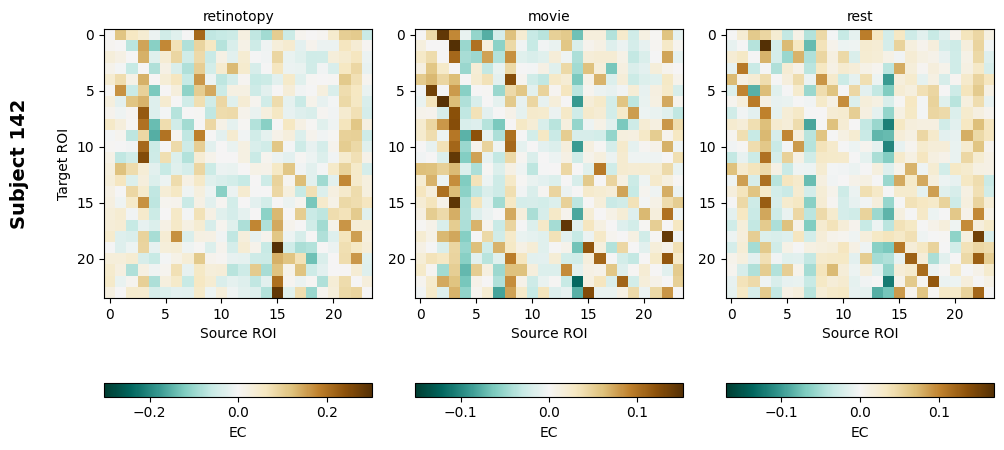

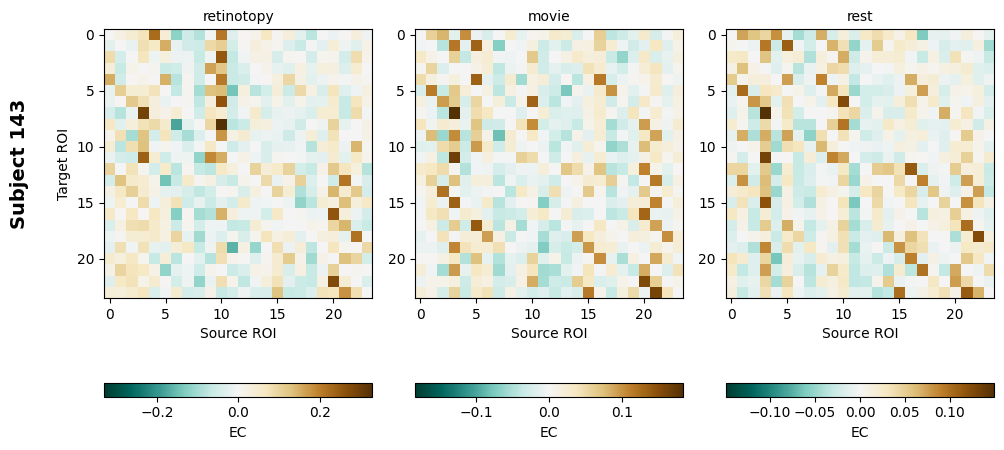

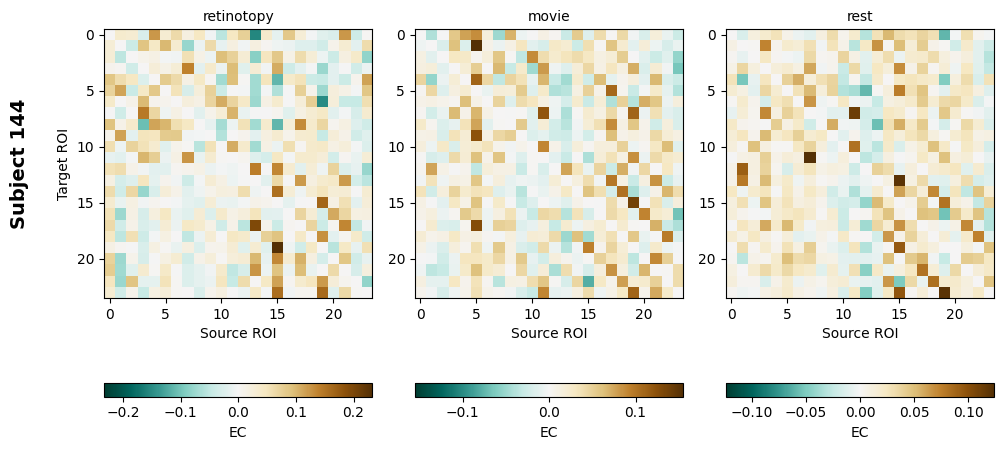

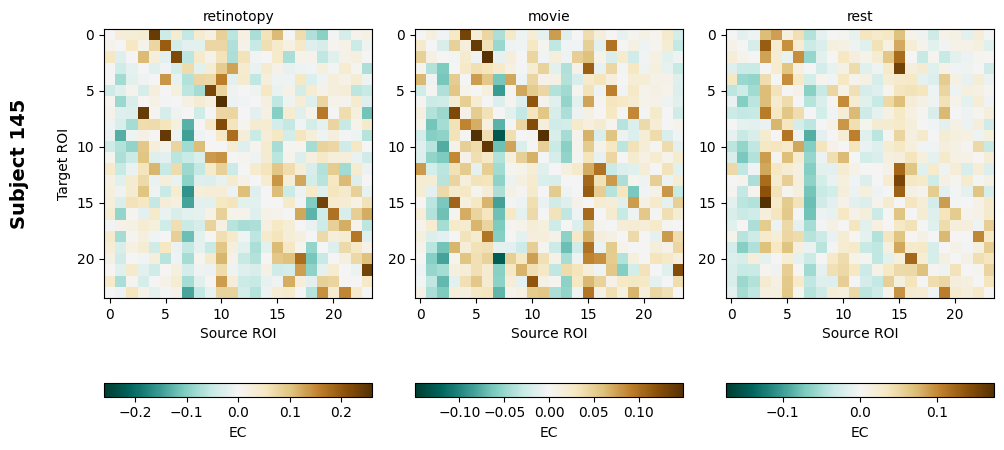

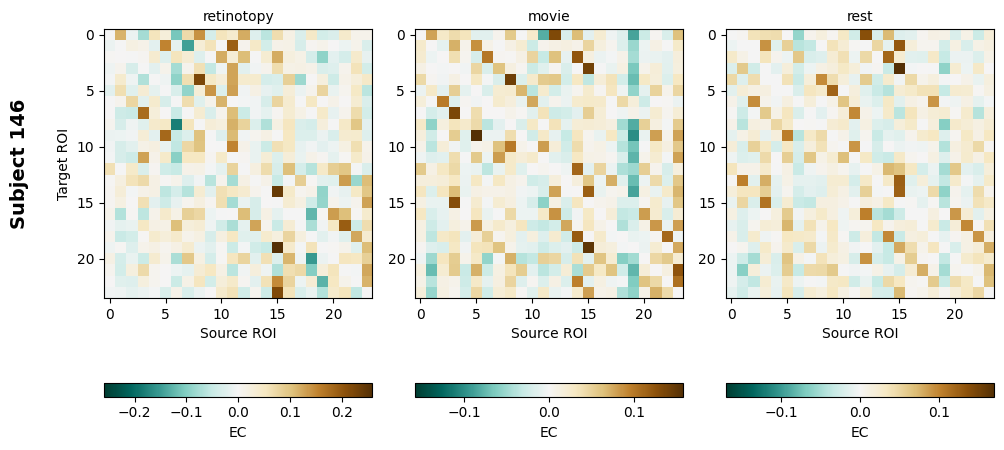

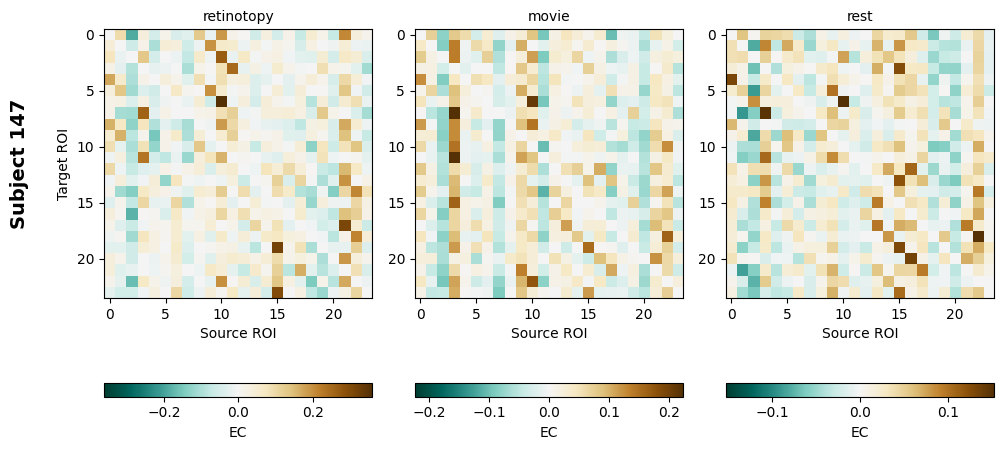

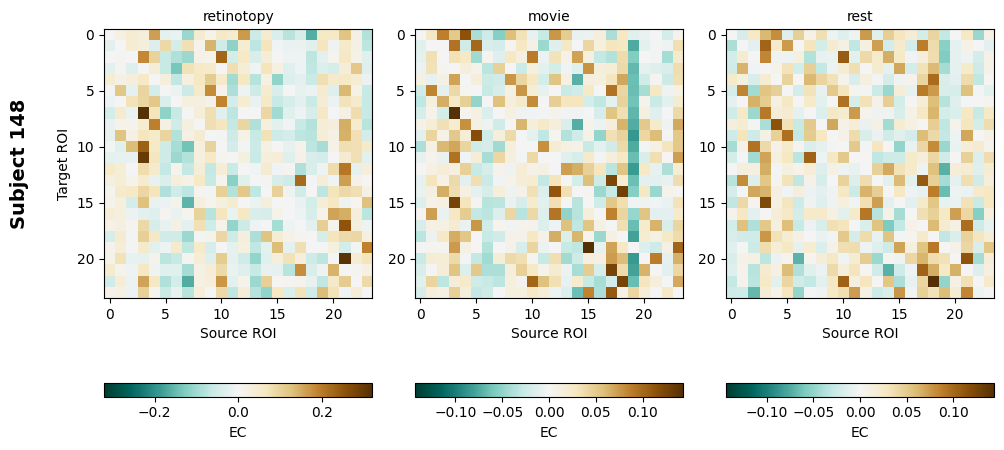

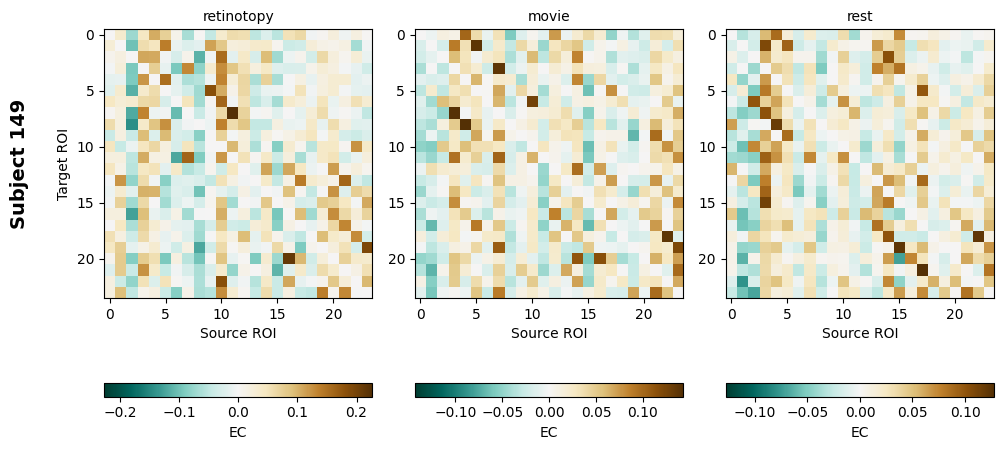

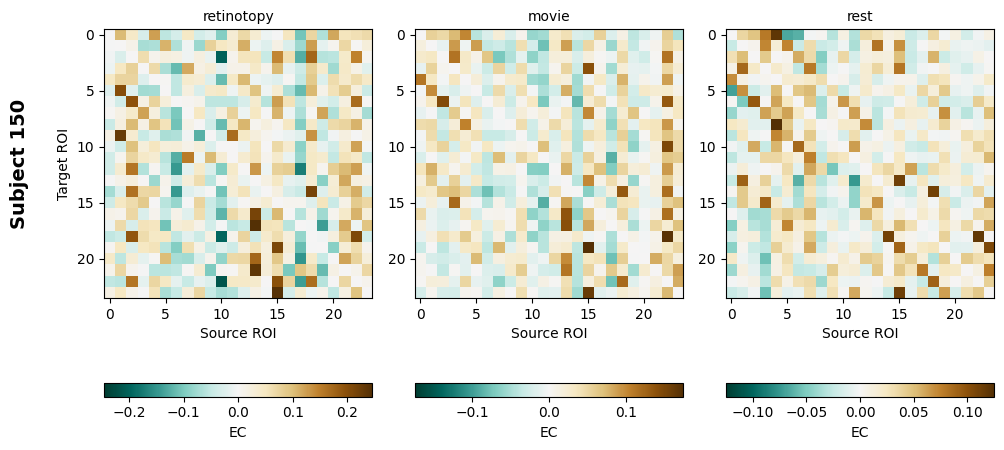

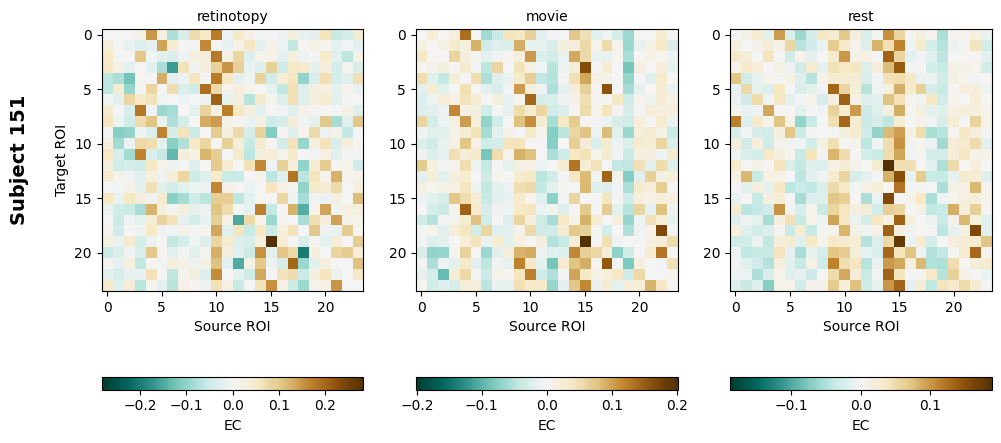

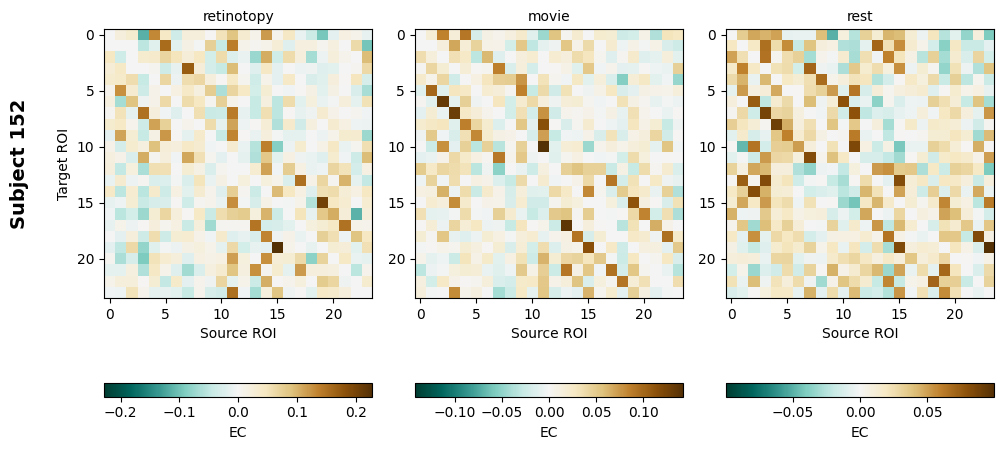

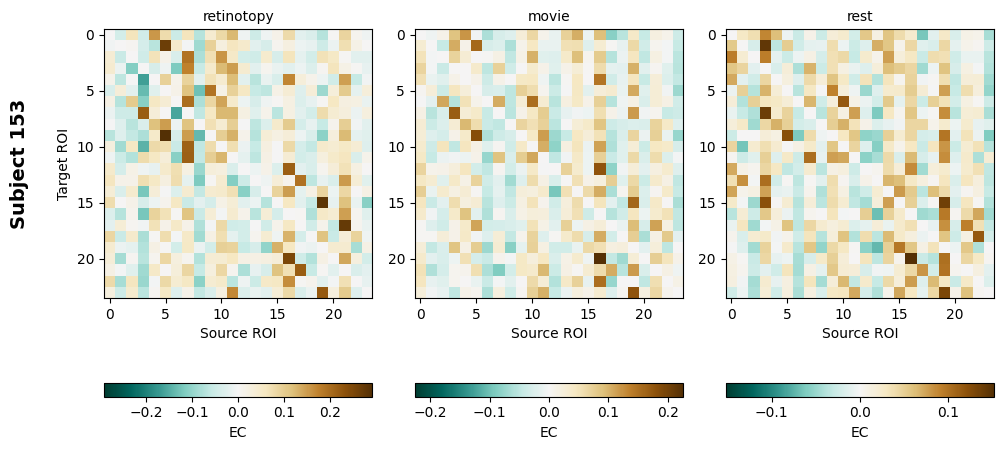

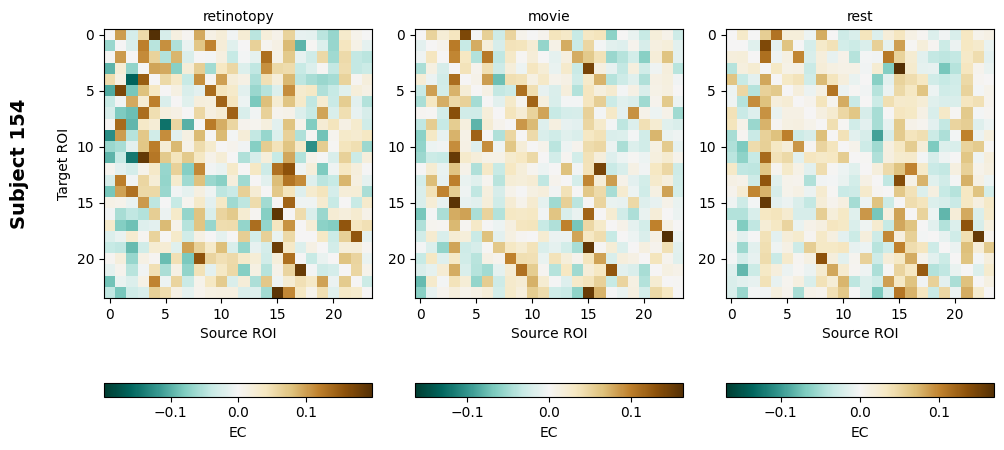

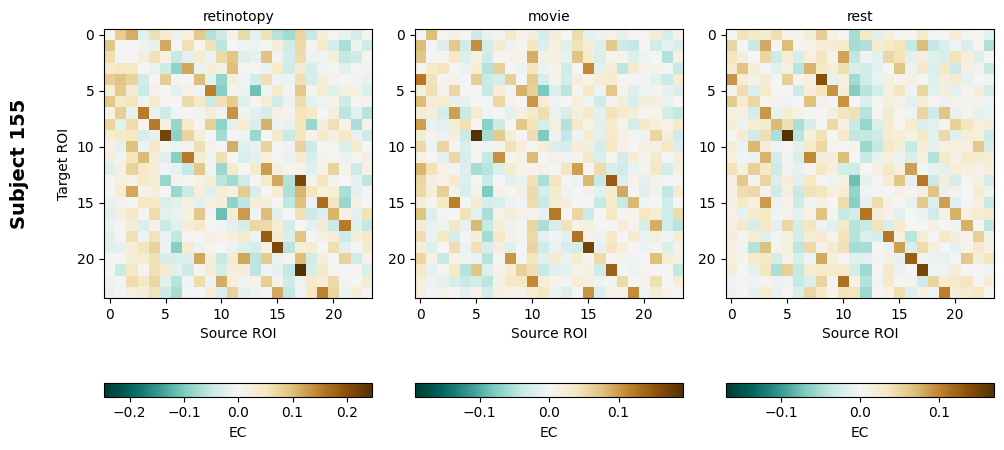

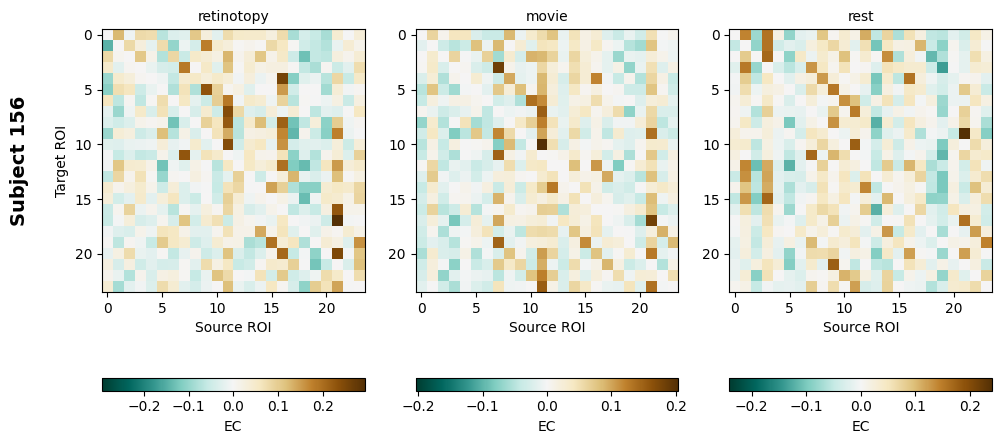

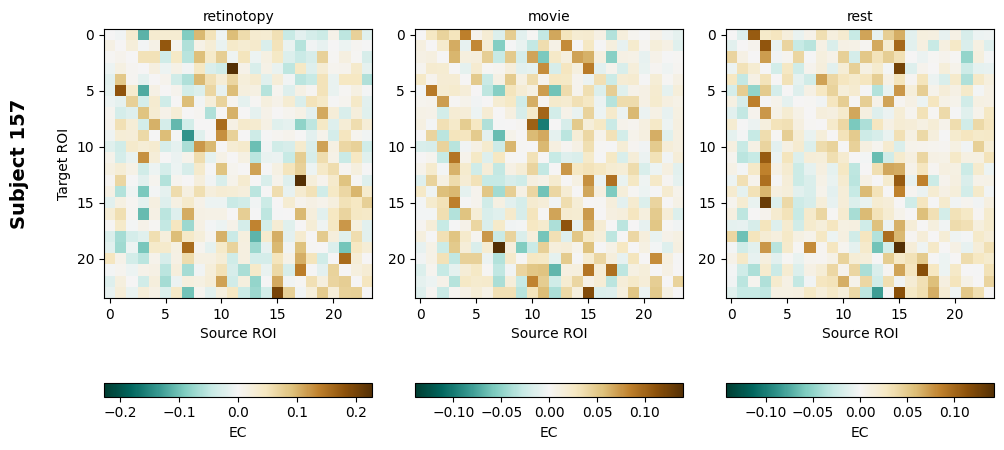

In [25]:
using PyPlot

for i_sub in 1:n_sub
    fig, axs = PyPlot.subplots(1, 3, figsize=(10, 6))
    
    # Retinotopy
    PyPlot.sca(axs[1])
    vmax_ret = max(abs(minimum(EC_avg[1, i_sub, :, :])), abs(maximum(EC_avg[1, i_sub, :, :])))
    im0 = PyPlot.imshow(EC_avg[1, i_sub, :, :]', vmin=-vmax_ret, vmax=vmax_ret, cmap="BrBG_r", aspect="equal")
    PyPlot.xlabel("Source ROI", fontsize=10)
    PyPlot.ylabel("Target ROI", fontsize=10)
    PyPlot.title("retinotopy", fontsize=10)
    PyPlot.colorbar(im0, ax=axs[1], orientation="horizontal", pad=0.15, label="EC")
    
    # Add subject label vertically on the left
    axs[1].text(-0.35, 0.5, "Subject $i_sub", transform=axs[1].transAxes, 
                fontsize=14, fontweight="bold", va="center", rotation=90)

    # Movie
    PyPlot.sca(axs[2])
    vmax_mov = max(abs(minimum(EC_avg[2, i_sub, :, :])), abs(maximum(EC_avg[2, i_sub, :, :])))
    im1 = PyPlot.imshow(EC_avg[2, i_sub, :, :]', vmin=-vmax_mov, vmax=vmax_mov, cmap="BrBG_r", aspect="equal")
    PyPlot.xlabel("Source ROI", fontsize=10)
    PyPlot.title("movie", fontsize=10)
    PyPlot.colorbar(im1, ax=axs[2], orientation="horizontal", pad=0.15, label="EC")

    # Rest
    PyPlot.sca(axs[3])
    vmax_rest = max(abs(minimum(EC_avg[3, i_sub, :, :])), abs(maximum(EC_avg[3, i_sub, :, :])))
    im2 = PyPlot.imshow(EC_avg[3, i_sub, :, :]', vmin=-vmax_rest, vmax=vmax_rest, cmap="BrBG_r", aspect="equal")
    PyPlot.xlabel("Source ROI", fontsize=10)
    PyPlot.title("rest", fontsize=10)
    PyPlot.colorbar(im2, ax=axs[3], orientation="horizontal", pad=0.15, label="EC")
    
    PyPlot.tight_layout()
    display(fig)
    PyPlot.close(fig)
end